Run the model on the test set so that the results files are saved.

`./eval_model_script.sh /data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5 BPcm_250 testing` 

`./eval_model_script.sh /data/nchand/analysis/BPcm_250/BP200_L0_0 BPcm_250 testing`



# P values for figure 1

In [65]:
from scipy.stats import wilcoxon
# 1 b wilcoxon rank sum test
def load_txt_correlations(filename):
    correlation_values = []
    with open(filename, 'r') as f:
        for line in f:
            # Split the line into parts
            parts = line.strip().split()
            if len(parts) == 2:
                # Extract the correlation value (second column)
                correlation_values.append(float(parts[1]))
    
    return correlation_values


def wilcoxon_signed_rank(values_1, values_2):
    statistic, p_value = wilcoxon(values_1, values_2)
    
    print(f"\n--- Wilcoxon Rank-sum Test Results ---")
    print(f"N = {len(values_1)}")
    print(f"Test statistic: {statistic}")
    print(f"P-value: {p_value}")
    if p_value < 1e-100:
        print("p < 1e-100")
    return p_value


# for figure 1b
def wilcox_for_txt_data(file_1, file_2):
    values_1 = load_txt_correlations(file_1)
    values_2 = load_txt_correlations(file_2)
    wilcoxon_signed_rank(values_1, values_2)

file_1 = "/data/nchand/analysis/BPcm_250/BP200_L0_0/scalar_corr_t10.txt" 
file_2 = "/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/scalar_corr_t10.txt"

print('1b Wilcoxon')
wilcox_for_txt_data(file_1=file_1, file_2=file_2)

print('\nS1a Wilcoxon')
file_1 ="/homes/gws/nchand/MostafaviLab/bpAITAC/final_figs/x_celltype_spearman_l0_mean.txt"
file_2 = "/homes/gws/nchand/MostafaviLab/bpAITAC/final_figs/x_celltype_spearman_lp5_mean.txt"
wilcox_for_txt_data(file_1, file_2)



1b Wilcoxon

--- Wilcoxon Rank-sum Test Results ---
N = 32361
Test statistic: 88003176.5
P-value: 0.0
p < 1e-100

S1a Wilcoxon

--- Wilcoxon Rank-sum Test Results ---
N = 32361
Test statistic: 122009385.5
P-value: 0.0
p < 1e-100


Use `correlation_boxplot.py` to make the boxplots. Set the experiment names there before running 

In [ ]:
# import subprocess
# subprocess.run(["python", "correlation_boxplot.py"], check=True)


In [66]:
from combine_results import get_combined_avg
from utils import load_names, load_observed

eval_set = 'test'
peak_names = load_names('/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt', eval_set)
results_dir = '/data/nchand/analysis/BPcm_250/'
model_names = 'BP200_L0_0', 'BP203_no_seed_L-1_5'
analysis_filename = 'testing_analysis.npz'
experiment_vars = [0, 0.5]
combined = get_combined_avg(peak_names, model_names, experiment_vars, results_dir, analysis_filename)

file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.names.dat
shape (32361,)
found files ['/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.03/testing_analysis.npz', '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.04/testing_analysis.npz', '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.05/testing_analysis.npz', '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.22.30/testing_analysis.npz', '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-09-2025.04.28/testing_analysis.npz', '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-01-2025.07.59/testing_analysis.npz']
num peaks 32361
num trials 6
[ 0.31630886 -0.12042658  0.11269398  0.78211856  0.07553453]
[ 0.64817202 -0.19781729  0.23332386  1.51628566  0.20720432]
[ 0.97513568 -0.33977615  0.52371126  2.11307245  0.35219287]
[ 1.30413884 -0.38568981  0.60507596  2.8228845   0.66844314]

In [5]:
# Select the desired columns
l0_df = combined[['peak_names', '0']]
# Save to a text file
l0_df.to_csv('/data/nchand/analysis/BPcm_250/BP200_L0_0/scalar_corr.txt', sep=' ', index=False, header=False)

l5_df = combined[['peak_names', '0.5']]
l5_df.to_csv('/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/scalar_corr.txt', sep=' ', index=False, header=False)

To get the outcome scatter plot run the following code in alex's DRG repo under the visualize_performance dir
`python scatter_comparison_plot.py /data/nchand/analysis/BPcm_250/BP200_L0_0/scalar_corr_t10.txt /data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/scalar_corr_t10.txt "AI-TAC" "bpAI-TAC" --savefig ~/MostafaviLab/bpAITAC/rebuttal_figs/1b --plotdiagonal --zeroxaxis --zeroyaxis --contour --density --manualticks -0.5,0.0,0.5,1.0 --xysamelim`

To get the outcome scatter plot with selected peaks colored, we get the selected peaks color file from region_identification.ipynb

For 3a with the selected peaks:

`python scatter_comparison_plot.py /data/nchand/analysis/BPcm_250/BP200_L0_0/scalar_corr_t10.txt /data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/scalar_corr_t10.txt "AI-TAC" "bpAI-TAC" --savefig ~/MostafaviLab/bpAITAC/submit_figs/3a --plotdiagonal --zeroxaxis --zeroyaxis --colorfile /data/nchand/analysis/BPcm_250/BP203_200_analysis/testing_lineage_v3/selected_peak_l0_l5_color_file.txt 0 --alpha 0.7`

Getting pearson correlation in the other direction - across the peaks. This means for each celltype will will end up with a pearson correlation.

1. Load model
2. get test data
3. get scalar corr predictions on the test data
4. compute pearson corr across peaks

run `python corr_across_peaks.py` to do this
Then you will get the files used to make the graphs

In [67]:
import numpy as np
# do a boxplot of the correlations
from correlation_boxplot import plot_boxplot
import pandas as pd

outpath = '/data/nchand/analysis/BPcm/BP68_peak_corr'

def convert_to_df(data, y_label, _lambda):
    # Create a dataframe with a column of the data named y_label in the header,
    # and another column that is filled with _lambda values
    df = pd.DataFrame({
        y_label: data,
        'lambda': np.full(len(data), _lambda)
    })
    return df


l0_files = np.load('/data/nchand/analysis/BPcm/BP68_L0_0_extra/peak_corr_testing3_extra.npz')
lp5_files = np.load('/data/nchand/analysis/BPcm/BP68_L-1_5_extra/peak_corr_testing3_extra.npz')
l0_trial_avg_corr = l0_files['trial_avg_corr']
l0_all_corr = l0_files['all_corr']
l0_trial_df = convert_to_df(l0_trial_avg_corr, 'scalar_corr_peaks', 0)
l0_df = convert_to_df(l0_all_corr, 'scalar_corr_peaks', 0)
print(l0_trial_df)

lp5_trial_avg_corr = lp5_files['trial_avg_corr']
lp5_trial_df = convert_to_df(lp5_trial_avg_corr, 'scalar_corr_peaks', 0.5)
lp5_corr_file_x_ocr_x_ocr_x_ocr_x_ocr = lp5_files['all_corr_x_ocr']
lp5_df = convert_to_df(lp5_corr_file, 'scalar_corr_peaks', 0.5)

combined_trial_df = pd.concat([l0_trial_df, lp5_trial_df], axis=0)
combined_df = pd.concat([l0_df, lp5_df], axis=0)
print('combined df len', len(combined_df))
close_to_zero_indices = np.where(np.abs(combined_df['scalar_corr_peaks']) < 0.01)[0]

print("Indices where scalar_corr_peaks are close to 0:")
print(close_to_zero_indices)

# remove outliers from combined_df
combined_df = combined_df[np.abs(combined_df['scalar_corr_peaks']) > 1e-1]


plot_boxplot(data=combined_df, trial_df=combined_trial_df, out_path=outpath, x_label='lambda', y_label='scalar_corr_peaks')

ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
combined_df

,scalar_corr_peaks,lambda
0,0.622144,0.0
1,0.660261,0.0
2,0.654656,0.0
3,0.597303,0.0
4,0.609640,0.0
...,...,...
895,0.606332,0.5
896,0.630280,0.5
897,0.678414,0.5
898,0.681885,0.5


In [ ]:
l0_files.files

['trial_avg_corr', 'all_corr']

# Ablation figures

In [ ]:
plt.rc('text', usetex=False)  # Optional: Use LaTeX rendering

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from textwrap import wrap
from scipy.stats import wilcoxon, ranksums

def create_boxplot(data_dict, title, xlabel, ylabel, figsize=(12, 6), output_file=None, 
                  rotate_xlabel=True, color=None, wrap_length=20, dark_grid=False, fliers=True, 
                  xlabel_size=None, plot_area_size=None, show_counts=False, show_pvalue_top2=False, show_pvalue_all=False, 
                  pvalue_fontsize=8, paired_test=True):
    """
    Create a boxplot from a dictionary of data using seaborn with text wrapping.
    
    :param data_dict: Dictionary with labels as keys and data arrays as values
    :param title: Title of the plot
    :param xlabel: Label for x-axis
    :param ylabel: Label for y-axis
    :param figsize: Size of the figure (width, height)
    :param output_file: If provided, save the plot to this file
    :param rotate_xlabel: Whether to rotate x-axis labels
    :param color: Base color for palette (if None, uses default seaborn palette)
    :param wrap_length: Maximum number of characters per line in x-axis labels
    :param show_counts: If True, show the number of data points in brackets after each label
    :param show_pvalue_top2: If True, show p-value between first box and the other highest median box
    :param pvalue_fontsize: Font size for p-value annotation
    """
    # Set the style and font scales
    sns.set_style("whitegrid")
    plt.rcdefaults()
    
    if dark_grid:
        sns.set_style("darkgrid")
    
    # Create figure
    print('fig size is', figsize)
    plt.figure(figsize=figsize, constrained_layout=True)
    
    # Convert dictionary to long-format DataFrame
    data_list = []
    for label, values in data_dict.items():
        df = pd.DataFrame({
            'Category': label,
            'Value': values
        })
        data_list.append(df)
    data_df = pd.concat(data_list, ignore_index=True)
    
    # Create color palette if specified
    if color:
        palette = sns.light_palette(color, n_colors=len(data_dict))
    else:
        palette = sns.color_palette("husl",  n_colors=len(data_dict))
    
    # Create boxplot
    ax = sns.boxplot(
        data=data_df,
        x='Category',
        y='Value',
        palette=palette,
        showfliers=fliers,
    )

    # If plot_area_size is specified, adjust the plot area
    if plot_area_size:
        # Check if values are absolute (greater than 1) or proportional
        if plot_area_size[0] > 1 or plot_area_size[1] > 1:
            # Convert absolute sizes (inches) to proportions
            width_prop = plot_area_size[0] / figsize[0]
            height_prop = plot_area_size[1] / figsize[1]
            # Ensure proportions don't exceed 1
            width_prop = min(width_prop, 0.95)
            height_prop = min(height_prop, 0.95)
            
        # Calculate margins to justify to right-top
        # Leave 5% margin from right edge
        right_margin = 0.03
        # Calculate left margin by working backwards from right edge
        x_margin = 1 - right_margin - width_prop
        # Position at top with small margin (5% from top)
        y_margin = 0.97 - height_prop
        
        # Set the plot position [left, bottom, width, height]
        ax.set_position([x_margin, y_margin, width_prop, height_prop])
    
    # Helper function to add significance stars
    def add_significance_stars(ax, x1, x2, pval, star_y_position, fontsize=8):
        """Add significance stars above two boxes at a fixed y position"""
        # Determine significance level
        if pval < 0.001:
            stars = '***'
        elif pval < 0.01:
            stars = '**'
        elif pval < 0.05:
            stars = '*'
        else:
            stars = 'n.s.'
        
        # Add the significance stars centered between the two boxes
        ax.text((x1 + x2) / 2, star_y_position, stars, 
            ha='center', va='center', fontsize=fontsize)

    # Calculate the y position for stars (just below the top of the y-axis)
    y_limits = ax.get_ylim()
    y_range = y_limits[1] - y_limits[0]
    star_y_position = y_limits[1] - y_range * 0.03  # 3% down from the top

    
    
    if show_pvalue_all and len(data_dict) >= 2:
        labels = list(data_dict.keys()) 
        
        for i in range(len(labels) - 1):
            label_1 = labels[i]
            label_2 = labels[i + 1]
            label_1_data_dict = data_dict[label_1]
            if paired_test:
                if len(data_dict[label_1]) != len(data_dict[label_2]):
                    print(f'{label_1} N= {len(data_dict[label_1])}, {label_2} N={len(data_dict[label_2])}')
                    print(f'{label_1}, {data_dict[label_1]}')
                    print(f'{label_2}, {data_dict[label_2]}')
                    label_1_data_dict = np.delete(data_dict[label_1], 3)
                stat, pval = wilcoxon(label_1_data_dict, data_dict[label_2])
            else # paired_test == False:
                stat, pval = ranksums(label_1_data_dict, data_dict[label_2])
                
            print(f"\nWilcoxon rank-sum test between {label_1} and {label_2}:")
            print(f"  p-value = {pval:.4e}")
            print(f" N {len(data_dict[label_1])}")
            
            # Add significance stars between consecutive boxes
            add_significance_stars(ax, i, i + 1, pval, star_y_position, fontsize=pvalue_fontsize)




    # Wrap x-axis labels and optionally add counts
    labels = list(data_dict.keys())
    
    if show_counts:
        # Add count in brackets to each label
        labels_with_counts = [f"{label} (n={len(data_dict[label])})" for label in labels]
        wrapped_labels = ['\n'.join(wrap(label, wrap_length)) for label in labels_with_counts]
    else:
        wrapped_labels = ['\n'.join(wrap(label, wrap_length)) for label in labels]
    
    ax.set_xticklabels(wrapped_labels, linespacing=0.8)

    # Calculate appropriate bottom margin based on number of wrapped lines
    max_lines = max(len(label.split('\n')) for label in wrapped_labels)
    
    if rotate_xlabel:
        ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', size=xlabel_size)
    else:
        ax.set_xticklabels(wrapped_labels, ha='center',size=xlabel_size)
    
    # Customize plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Adjust grid opacity and line width
    ax.grid(True, alpha=0.3, linewidth=1)
    
    # Make axis lines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Save the plot if output_file is provided
    if output_file:
        plt.savefig(output_file, dpi=330, bbox_inches='tight')
        print(f"Boxplot has been saved as '{output_file}'")
    
    plt.show()
    plt.close()


def process_and_plot(path_dict, data_key, title, xlabel, ylabel, figsize=(12, 6), output_file=None, 
                    rotate_xlabel=True, color=None, wrap_length=20, dark_grid=False, fliers=True, 
                    xlabel_size=None, plot_area_size=None, box_width=0.5, show_pvalue_top2=False,show_pvalue_all=False):
    """
    Process NPZ files and create a boxplot using seaborn.
    
    :param path_dict: Dictionary with labels as keys and file paths as values
    :param data_key: Key to extract data from NPZ files
    :param title: Title of the plot
    :param xlabel: Label for x-axis
    :param ylabel: Label for y-axis
    :param figsize: Size of the figure (width, height), default is (12, 6)
    :param output_file: If provided, save the plot to this file
    :param rotate_xlabel: Whether to rotate x-axis labels
    :param color: Base color for palette (if None, uses default seaborn palette)
    :param wrap_length: Maximum number of characters per line in x-axis labels
    :param show_pvalue_top2: If True, show p-value between first box and highest other median box
    """
    # Load data for each model
    data_dict = {model: np.load(path)[data_key] for model, path in path_dict.items()}
    
    n_boxes = len(data_dict)
    plot_width = box_width*n_boxes
    plot_height= 2.75
    plot_area_size=(plot_width, plot_height)
    figsize = (plot_width+2, plot_height + 2)

    # Create and display the boxplot
    create_boxplot(data_dict, title, xlabel, ylabel, figsize=figsize, output_file=output_file, 
                  rotate_xlabel=rotate_xlabel, color=color, wrap_length=wrap_length, 
                  dark_grid=dark_grid, fliers=fliers, xlabel_size=xlabel_size, 
                  plot_area_size=plot_area_size, show_pvalue_top2=show_pvalue_top2, show_pvalue_all=show_pvalue_all)

SyntaxError: expected ':' (1989860201.py, line 124)

Architecture Ablation

fig size is (5.0, 4.75)

Wilcoxon rank-sum test between bpAITAC and Shallow:
  p-value = 5.8041e-188
 N 32361

Wilcoxon rank-sum test between Shallow and Max50AccHead:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between Max50AccHead and GlobPoolAccHead:
  p-value = 1.3645e-20
 N 32361

Wilcoxon rank-sum test between GlobPoolAccHead and NoBody:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between NoBody and FCAccHead:
  p-value = 0.0000e+00
 N 32361
Boxplot has been saved as 'rebuttal_figs/2d_architecture_boxplot.png'


<Figure size 640x480 with 0 Axes>

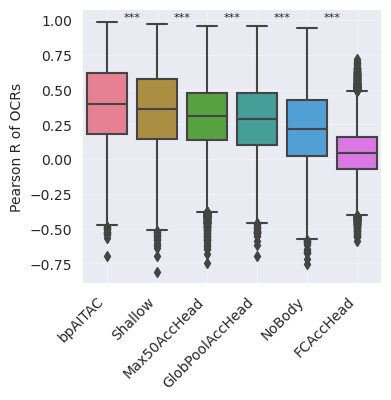

fig size is (5.0, 4.75)

Wilcoxon rank-sum test between bpAITAC and Shallow:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between Shallow and Max50AccHead:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between Max50AccHead and GlobPoolAccHead:
  p-value = 1.2058e-14
 N 90

Wilcoxon rank-sum test between GlobPoolAccHead and NoBody:
  p-value = 3.4805e-15
 N 90

Wilcoxon rank-sum test between NoBody and FCAccHead:
  p-value = 1.7438e-16
 N 90
Boxplot has been saved as 'rebuttal_figs/S4e_architecture_boxplot.png'


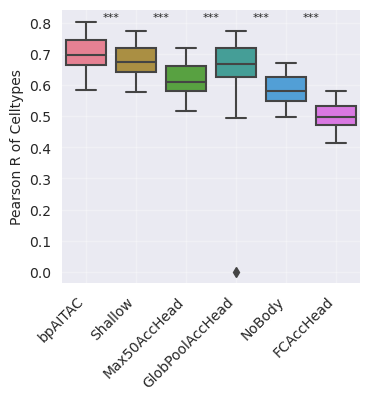

In [15]:
chelan_results_dir='/homes/gws/nchand/MostafaviLab/results/'
ablation_path_dict = {
    'bpAITAC': chelan_results_dir+"BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/testing_correlation_analysis.npz",
    # 'No added bias': "/data/nchand/analysis/BPcm_bias0/BP97_L-1_5/complete/10-22-2024.14.55/testing_analysis.npz",
    'Shallow': chelan_results_dir+ "BPcm_skinny/BP205_L-1_5/complete/04-06-2025.07.44/testing_correlation_analysis.npz",
    'Max50AccHead': chelan_results_dir+"BPmp/BP207_L-1_5/complete/04-07-2025.14.14/testing_correlation_analysis.npz",
    'GlobPoolAccHead': chelan_results_dir+"BPnetRep/BP206_L-1_5/complete/04-06-2025.07.48/testing_correlation_analysis.npz",
    'NoBody': chelan_results_dir+"BPcm_super_skinny/BP208_L-1_5/complete/04-07-2025.13.48/testing_correlation_analysis.npz",
    'FCAccHead': chelan_results_dir+"BPol/BP209_L-1_5/complete/04-07-2025.13.51/testing_correlation_analysis.npz"
}

plt.clf()

process_and_plot(
    ablation_path_dict,
    'scalar_corr',
    '',
    '',
    'Pearson R of OCRs',
    output_file='rebuttal_figs/2d_architecture_boxplot.png',
    dark_grid=True,
    fliers=True,
    show_pvalue_all=True
)

process_and_plot(
    ablation_path_dict,
    'scalar_pearson_corr_across_ocrs',
    '',
    '',
    'Pearson R of Celltypes',
    output_file='rebuttal_figs/S4e_architecture_boxplot.png',
    dark_grid=True,
    fliers=True,
    show_pvalue_all=True
)

In [ ]:
# TODO ablation for pearson and in other direction

## Bias ablation

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between No Bias and Shallow Deprotinated:
  p-value = 2.5102e-02
 N 32361

Wilcoxon rank-sum test between Shallow Deprotinated and Deep Deprotinated:
  p-value = 3.3990e-45
 N 32361

Wilcoxon rank-sum test between Deep Deprotinated and Deep Closed:
  p-value = 8.4077e-48
 N 32361
Boxplot has been saved as 'rebuttal_figs/2e_bias_scalar_correlation_boxplot.png'


<Figure size 640x480 with 0 Axes>

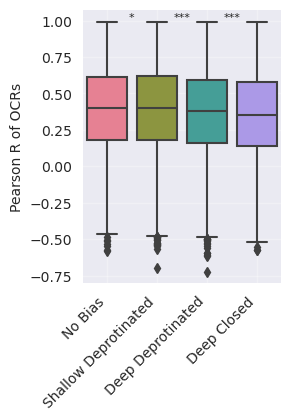

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between No Bias and Shallow Deprotinated:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between Shallow Deprotinated and Deep Deprotinated:
  p-value = 4.0878e-11
 N 90

Wilcoxon rank-sum test between Deep Deprotinated and Deep Closed:
  p-value = 3.5943e-15
 N 90
Boxplot has been saved as 'rebuttal_figs/S4f_bias_corr_x_ocrs_boxplot.png'


<Figure size 640x480 with 0 Axes>

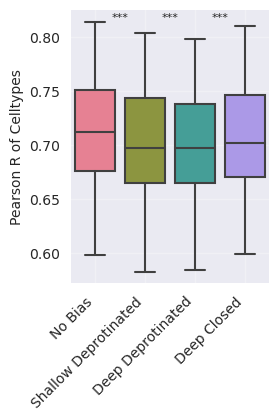

In [16]:
# ablation_path_dict = {
#     'No additional bias information added': "/homes/gws/nchand/MostafaviLab/results/BPcm_bias0/BP127_L-1_5/complete/12-26-2024.18.38/testing_analysis.npz",
#     'Shallow bias model trained on deprotinated DNA': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP126_L-1_5/complete/11-17-2024.11.51/testing_analysis.npz",
#     'Deep bias model trained on deprotinated DNA': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP132_L-1_5/complete/12-23-2024.11.20/testing_analysis.npz",
#     'Deep bias model trained on closed chromatin regions': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP133_L-1_5/complete/12-26-2024.13.12/testing_analysis.npz",
# }    
ablation_path_dict = {
    'No Bias': "/data/nchand/analysis/BPcm_bias0/BP212_L-1_5/complete/04-08-2025.15.03/testing_correlation_analysis.npz",
    'Shallow Deprotinated': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/testing_correlation_analysis.npz",
    'Deep Deprotinated': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP210_L-1_5/complete/04-08-2025.08.57/testing_correlation_analysis.npz",
    'Deep Closed': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP211_L-1_5/complete/04-08-2025.09.04/testing_correlation_analysis.npz",
}    

plt.clf()

process_and_plot(
    ablation_path_dict,
    'scalar_corr',
    '',
    '',
    'Pearson R of OCRs',
    output_file='rebuttal_figs/2e_bias_scalar_correlation_boxplot.png',
    dark_grid=True,
    show_pvalue_all=True
)
  

plt.clf()

process_and_plot(
    ablation_path_dict,
    'scalar_pearson_corr_across_ocrs',
    '',
    '',
    'Pearson R of Celltypes',
    output_file='rebuttal_figs/S4f_bias_corr_x_ocrs_boxplot.png',
    dark_grid=True,
    fliers=False,
    show_pvalue_all=True
)

Loss function ablation

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between PoissonNLL (acc*profile) and (1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile):
  p-value = 1.0983e-33
 N 32361

Wilcoxon rank-sum test between (1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile) and MSE (acc*profile):
  p-value = 1.7284e-133
 N 32361

Wilcoxon rank-sum test between MSE (acc*profile) and (1-$\hat{\lambda}$)MSE(acc) + ($\hat{\lambda}$)MNLL(profile):
  p-value = 1.8457e-149
 N 32361
Boxplot has been saved as 'rebuttal_figs/2a_loss_function_boxplot.png'


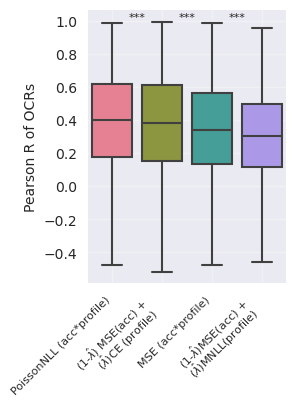

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between PoissonNLL (acc*profile) and (1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile):
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between (1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile) and MSE (acc*profile):
  p-value = 1.7437e-16
 N 90

Wilcoxon rank-sum test between MSE (acc*profile) and (1-$\hat{\lambda}$)MSE(acc) + ($\hat{\lambda}$)MNLL(profile):
  p-value = 7.9904e-15
 N 90
Boxplot has been saved as 'rebuttal_figs/S4a_loss_function_pearson_x_ocr.png'


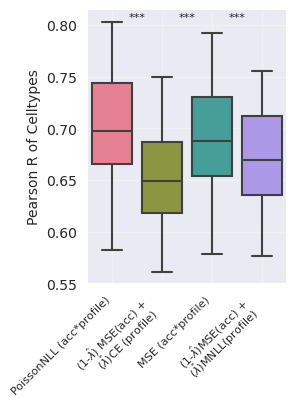

In [55]:
loss_path_dict = {
    'PoissonNLL (acc*profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/testing_analysis.npz",
    '(1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP200_L-1_5/complete/04-01-2025.08.22/testing_analysis.npz",
    'MSE (acc*profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP202_L-1_5/complete/04-03-2025.09.23/testing_analysis.npz",
    '(1-$\hat{\lambda}$)MSE(acc) + ($\hat{\lambda}$)MNLL(profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP201_L-1_5/complete/04-03-2025.09.19/testing_analysis.npz",
}


process_and_plot(
    loss_path_dict,
    'scalar_corr',
    '',
    '',
    ylabel='Pearson R of OCRs',
    output_file='rebuttal_figs/2a_loss_function_boxplot.png',
    wrap_length=35,
    dark_grid=True,
    xlabel_size=8,
    fliers=False,
    show_pvalue_all=True
)

# SUPPLEMENTARY corr across OCRs

sup_loss_path_dict = {
    'PoissonNLL (acc*profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/testing_correlation_analysis.npz",
    '(1-$\hat{\lambda}$) MSE(acc) + ($\hat{\lambda}$)CE (profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP200_L-1_5/complete/04-01-2025.08.22/testing_correlation_analysis.npz",
    'MSE (acc*profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP202_L-1_5/complete/04-03-2025.09.23/testing_correlation_analysis.npz",
    '(1-$\hat{\lambda}$)MSE(acc) + ($\hat{\lambda}$)MNLL(profile)': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP201_L-1_5/complete/04-03-2025.09.19/testing_correlation_analysis.npz",
}
process_and_plot(
    sup_loss_path_dict,
    'scalar_pearson_corr_across_ocrs',
    '',
    '',
    ylabel='Pearson R of Celltypes',
    output_file='rebuttal_figs/S4a_loss_function_pearson_x_ocr.png',
    wrap_length=35,
    dark_grid=True,
    xlabel_size=8,
    fliers=False,
    show_pvalue_all=True
)


## Binning study

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between 1 and 5:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 5 and 10:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 10 and 20:
  p-value = 2.3430e-16
 N 32361
Boxplot has been saved as 'rebuttal_figs/2c_bin_boxplot.png'


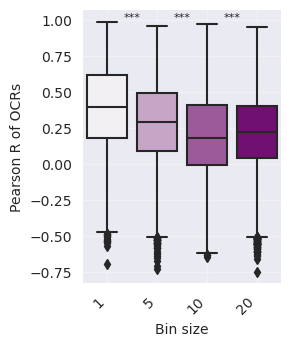

fig size is (4.0, 4.75)

Wilcoxon rank-sum test between 1 and 5:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between 5 and 10:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between 10 and 20:
  p-value = 3.2635e-15
 N 90
Boxplot has been saved as 'rebuttal_figs/S4g_bin_boxplot.png'


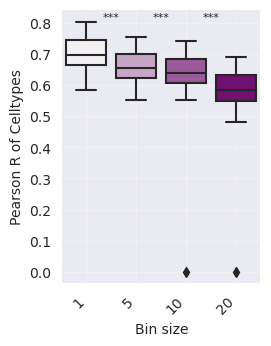

In [56]:
bin_path_dict = {
    '1': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/testing_correlation_analysis.npz",
    '5': "/data/nchand/analysis/BPcm_250/BP213_L-1_5/complete/04-09-2025.03.16/testing_correlation_analysis.npz",
    '10': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP214_L-1_5/complete/04-10-2025.14.56/testing_correlation_analysis.npz",
    '20': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP215_L-1_5/complete/04-11-2025.08.30/testing_correlation_analysis.npz",
}


process_and_plot(
    bin_path_dict,
    'scalar_corr',
    '',
    'Bin size',
    'Pearson R of OCRs',
    output_file='rebuttal_figs/2c_bin_boxplot.png',
    color='purple',
    dark_grid=True,
    show_pvalue_all=True
)

process_and_plot(
    bin_path_dict,
    'scalar_pearson_corr_across_ocrs',
    '',
    'Bin size',
    'Pearson R of Celltypes',
    output_file='rebuttal_figs/S4g_bin_boxplot.png',
    color='purple',
    dark_grid=True,
    show_pvalue_all=True
)




# Lambda ablation

For the lambda ablation
`./eval_model_script.sh /data/nchand/analysis/BPcm_250/BP200 BPcm_250 testing 1 998 90 best_loss_model.pth` for the best profile models
`./eval_model_script.sh /data/nchand/analysis/BPcm_250/BP203 BPcm_250 testing 1 998 90 best_loss_model.pth`

`./eval_model_script.sh /data/nchand/analysis/BPcm_250/BP200 BPcm_250 testing 1 998 90` for the best scalar prediction models


`./eval_model_get_corr_script.sh /data/nchand/analysis/BPcm_250/BP200 BPcm_250 testing 1 998 90` for correlation in the other direction



file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.total_counts.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bp_counts.dat
(32361, 90)
(32361,)
2658


fig size is (7.0, 4.75)

Wilcoxon rank-sum test between 0 and 0.1:
  p-value = 7.8378e-274
 N 32361

Wilcoxon rank-sum test between 0.1 and 0.3:
  p-value = 1.7528e-197
 N 32361

Wilcoxon rank-sum test between 0.3 and 0.4:
  p-value = 2.5354e-28
 N 32361

Wilcoxon rank-sum test between 0.4 and 0.5:
  p-value = 5.6107e-01
 N 32361

Wilcoxon rank-sum test between 0.5 and 0.6:
  p-value = 5.0778e-02
 N 32361

Wilcoxon rank-sum test between 0.6 and 0.7:
  p-value = 5.9682e-09
 N 32361

Wilcoxon rank-sum test between 0.7 and 0.8:
  p-value = 6.5072e-75
 N 32361

Wilcoxon rank-sum test between 0.8 and 0.9:
  p-value = 4.8604e-154
 N 32361

Wilcoxon rank-sum test between 0.9 and 1:
  p-value = 0.0000e+00
 N 32361


Boxplot has been saved as 'rebuttal_figs/S3d_ocr_corr_lambda.png'


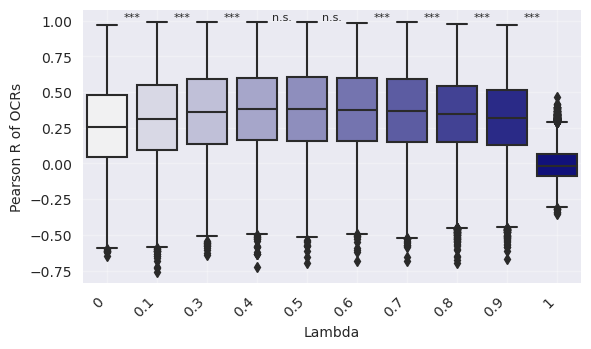

fig size is (7.0, 4.75)

Wilcoxon rank-sum test between 0 and 0.1:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between 0.1 and 0.3:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between 0.3 and 0.4:
  p-value = 5.2434e-16
 N 90

Wilcoxon rank-sum test between 0.4 and 0.5:
  p-value = 6.6257e-09
 N 90

Wilcoxon rank-sum test between 0.5 and 0.6:
  p-value = 1.6007e-14
 N 90

Wilcoxon rank-sum test between 0.6 and 0.7:
  p-value = 1.7438e-16
 N 90

Wilcoxon rank-sum test between 0.7 and 0.8:
  p-value = 5.1988e-03
 N 90

Wilcoxon rank-sum test between 0.8 and 0.9:
  p-value = 1.2969e-02
 N 90

Wilcoxon rank-sum test between 0.9 and 1:
  p-value = 1.7438e-16
 N 90
Boxplot has been saved as 'rebuttal_figs/S3e_ocr_cell_lambda.png'


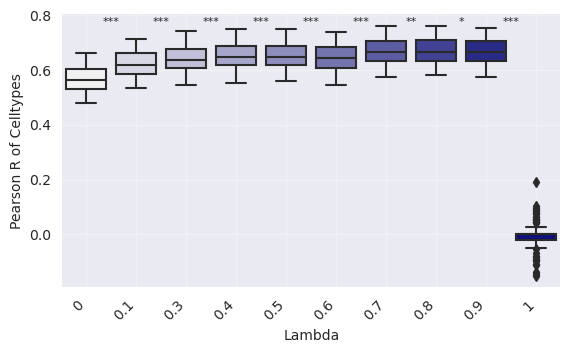

In [59]:
file_name='testing_correlation_analysis.npz' # this is the best_loss_model path one right now
# file_name = 'testing_correlation_analysis.npz_best_loss_model.pth.npz'
lambda_scalar_corr_path_dict = {
    '0': "/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-01-2025.07.59/"+file_name,
    '0.1': "/data/nchand/analysis/BPcm_250/BP200_L-1_1/complete/04-04-2025.13.53/"+file_name,
    '0.3': "/data/nchand/analysis/BPcm_250/BP200_L-1_3/complete/04-04-2025.07.38/"+file_name,
    '0.4': "/data/nchand/analysis/BPcm_250/BP200_L-1_4/complete/04-01-2025.08.00/"+file_name,
    '0.5': "/data/nchand/analysis/BPcm_250/BP200_L-1_5/complete/04-01-2025.08.22/"+file_name,
    '0.6': "/data/nchand/analysis/BPcm_250/BP200_L-1_6/complete/04-02-2025.05.24/"+file_name,
    '0.7': "/data/nchand/analysis/BPcm_250/BP200_L-1_7/complete/04-02-2025.05.26/"+file_name,
    '0.8': "/data/nchand/analysis/BPcm_250/BP200_L-1_8/complete/04-05-2025.00.08/"+file_name,
    '0.9': "/data/nchand/analysis/BPcm_250/BP200_L-1_9/complete/04-04-2025.22.48/"+file_name,
    '1': "/data/nchand/analysis/BPcm_250/BP200_L0_1/complete/04-04-2025.07.42/"+file_name,
}

process_and_plot(
    lambda_scalar_corr_path_dict,
    'scalar_corr',
    '',
    'Lambda',
    'Pearson R of OCRs',
    output_file='rebuttal_figs/S3d_ocr_corr_lambda.png',
    color='darkblue',
    dark_grid=True,
    show_pvalue_all=True,
)

# CORRELATION in the other direction
process_and_plot(
    lambda_scalar_corr_path_dict,
    'scalar_pearson_corr_across_ocrs',
    '',
    'Lambda',
    'Pearson R of Celltypes',
    output_file='rebuttal_figs/S3e_ocr_cell_lambda.png',
    color='darkblue',
    dark_grid=True,
    show_pvalue_all=True
)





fig size is (7.5, 4.75)

Wilcoxon rank-sum test between 0 and 0.1:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.1 and 0.3:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.3 and 0.4:
  p-value = 5.4278e-289
 N 32361

Wilcoxon rank-sum test between 0.4 and 0.5:
  p-value = 8.8697e-290
 N 32361

Wilcoxon rank-sum test between 0.5 and 0.6:
  p-value = 3.8828e-297
 N 32361

Wilcoxon rank-sum test between 0.6 and 0.7:
  p-value = 3.0520e-07
 N 32361

Wilcoxon rank-sum test between 0.7 and 0.8:
  p-value = 6.1225e-103
 N 32361

Wilcoxon rank-sum test between 0.8 and 0.9:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.9 and 1:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 1 and PoissonNLL:
  p-value = 0.0000e+00
 N 32361
Boxplot has been saved as 'rebuttal_figs/S3c_boxplot.png'


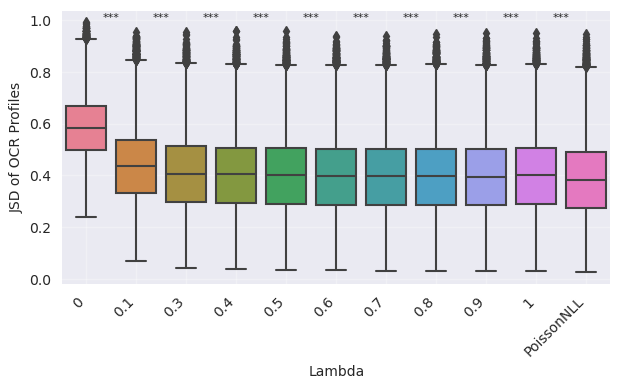

fig size is (6.4, 4.75)

Wilcoxon rank-sum test between 0 and 0.1:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.1 and 0.3:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.3 and 0.4:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.4 and 0.5:
  p-value = 0.0000e+00
 N 32361

Wilcoxon rank-sum test between 0.5 and 0.6:
  p-value = 3.3596e-259
 N 32361

Wilcoxon rank-sum test between 0.6 and 0.7:
  p-value = 4.8193e-29
 N 32361

Wilcoxon rank-sum test between 0.7 and 0.8:
  p-value = 1.9958e-26
 N 32361

Wilcoxon rank-sum test between 0.8 and 0.9:
  p-value = 3.5371e-126
 N 32361

Wilcoxon rank-sum test between 0.9 and 1:
  p-value = 1.2603e-202
 N 32361

Wilcoxon rank-sum test between 1 and PoissonNLL:
  p-value = 0.0000e+00
 N 32361
Boxplot has been saved as 'rebuttal_figs/2b.png'


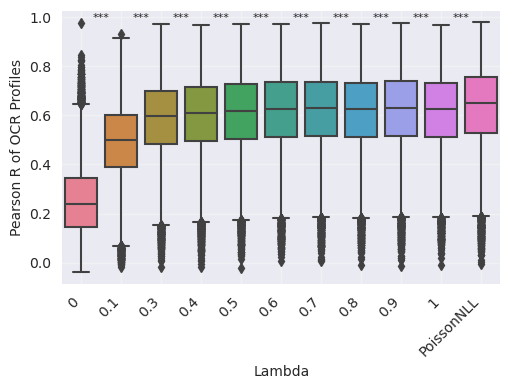

In [60]:
# PROFILE METRICS

file_name='save_file_name=testing_analysis.npz_best_loss_model.pth.npz' # this is the best_loss_model path one right now
# file_name = 'testing_correlation_analysis.npz_best_loss_model.pth.npz'
profile_lambda_path_dict = {
    '0': "/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-01-2025.07.59/"+file_name,
    '0.1': "/data/nchand/analysis/BPcm_250/BP200_L-1_1/complete/04-04-2025.13.53/"+file_name,
    '0.3': "/data/nchand/analysis/BPcm_250/BP200_L-1_3/complete/04-04-2025.07.38/"+file_name,
    '0.4': "/data/nchand/analysis/BPcm_250/BP200_L-1_4/complete/04-01-2025.08.00/"+file_name,
    '0.5': "/data/nchand/analysis/BPcm_250/BP200_L-1_5/complete/04-01-2025.08.22/"+file_name,
    '0.6': "/data/nchand/analysis/BPcm_250/BP200_L-1_6/complete/04-02-2025.05.24/"+file_name,
    '0.7': "/data/nchand/analysis/BPcm_250/BP200_L-1_7/complete/04-02-2025.05.26/"+file_name,
    '0.8': "/data/nchand/analysis/BPcm_250/BP200_L-1_8/complete/04-05-2025.00.08/"+file_name,
    '0.9': "/data/nchand/analysis/BPcm_250/BP200_L-1_9/complete/04-04-2025.22.48/"+file_name,
    '1': "/data/nchand/analysis/BPcm_250/BP200_L0_1/complete/04-04-2025.07.42/"+file_name,
    'PoissonNLL': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/save_file_name=testing_analysis.npz_best_loss_model.pth.npz"
}
process_and_plot(
    profile_lambda_path_dict,
    'top_ocr_jsd',
    '',
    'Lambda',
    'JSD of OCR Profiles',
    output_file='rebuttal_figs/S3c_boxplot.png',
    dark_grid=True,
    show_pvalue_all=True
)

process_and_plot(
    profile_lambda_path_dict,
    'top_ocr_profile_corr',
    '',
    'Lambda',
    'Pearson R of OCR Profiles',
    output_file='rebuttal_figs/2b.png',
    dark_grid=True,
    box_width=0.4,
    show_pvalue_all=True
)

In [ ]:
from utils import load_observed
from utils import load_names
import numpy as np
thresholds = [300, 400, 500]

info_file = '/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt'
test_counts = load_observed(info_file, dataset_type='test', data_name='total_counts')
test_bpcounts = load_observed(info_file, dataset_type='test', data_name='bp_counts')
test_bias = load_observed(info_file, dataset_type='test', data_name='bias')
test_onehot = load_observed(info_file, dataset_type='test', data_name='onehot')

print(test_counts.shape)


for name, file in profile_lambda_path_dict.items():
    
    # Load the existing NPZ file
    loaded_data = np.load(file)

    # Create a dictionary with all the existing arrays
    # This converts the NpzFile object to a regular dictionary
    data_dict = {key: loaded_data[key] for key in loaded_data.files}


    # make a mask for where test_counts > threshold
    for th in thresholds:   
        count_mask = np.max(test_counts, axis=1) > th # the max of all celltypes
        print(count_mask.shape)
        print(np.sum(count_mask))
    
        # Calculate avg_profile_corr
        profile_corr = loaded_data['profile_corr']
        avg_profile_corr = np.mean(profile_corr, axis=-1)
        top_ocr_profile_corr_masked = loaded_data['top_ocr_profile_corr'][count_mask]
        top_ocr_jsd_masked = loaded_data['top_ocr_jsd'][count_mask]

        
        # Add your new array to the dictionary
        data_dict[f'top_ocr_profile_corr_masked_{th}'] = top_ocr_profile_corr_masked
        data_dict[f'top_ocr_jsd_masked_{th}'] = top_ocr_jsd_masked
        

    # If you prefer to create a new file instead:
    new_file = file.replace('.npz', '_profile_modified.npz')
    print(new_file)
    np.savez(new_file, **data_dict)

file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.total_counts.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bp_counts.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bias.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.onehot.dat
(32361, 90)
(32361,)
4618
(32361,)
2658
(32361,)
1567
/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-01-2025.07.59/save_file_name=testing_analysis_profile_modified.npz_best_loss_model.pth_profile_modified.npz
(32361,)
4618
(32361,)
2658
(32361,)
1567
/data/nchand/analysis/BPcm_250/BP200_L-1_1/complete/04-04-2025.13.53/save_file_name=testing_analysis_profile_modified.npz_best_loss_model.pth_profile_modif

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/S2d_300_boxplot.png'


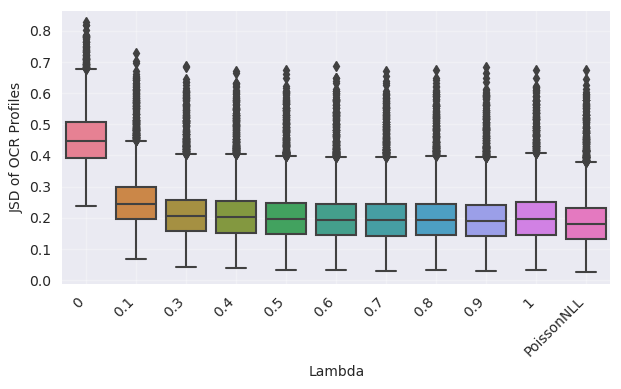

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/2e_300_boxplot.png'


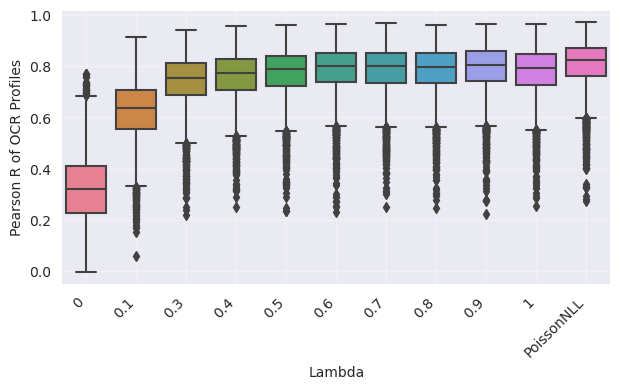

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/S2d_400_boxplot.png'


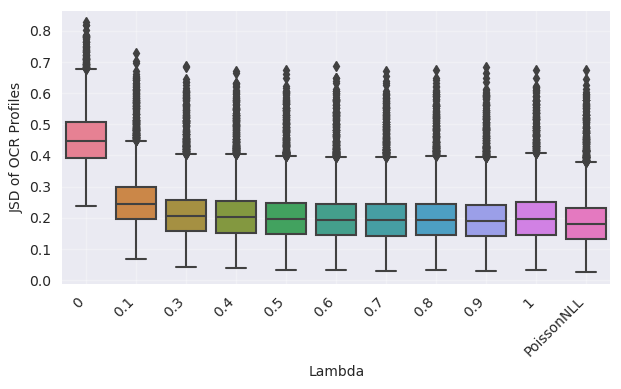

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/2e_400_boxplot.png'


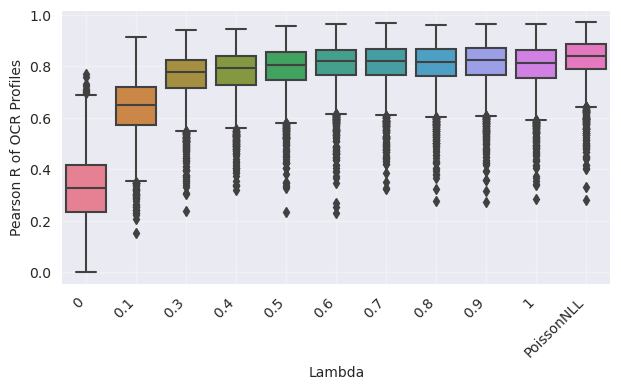

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/S2d_500_boxplot.png'


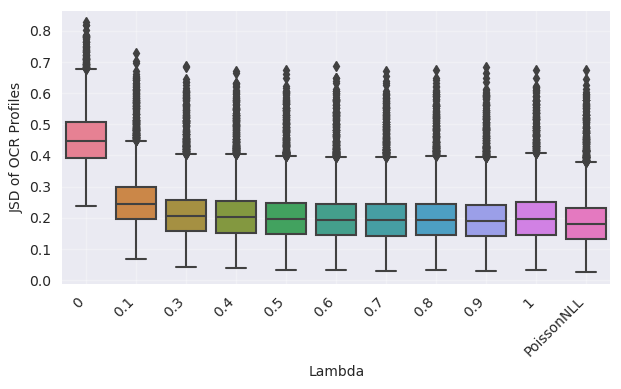

fig size is (7.5, 4.75)
Boxplot has been saved as 'final_figs/2e_500_boxplot.png'


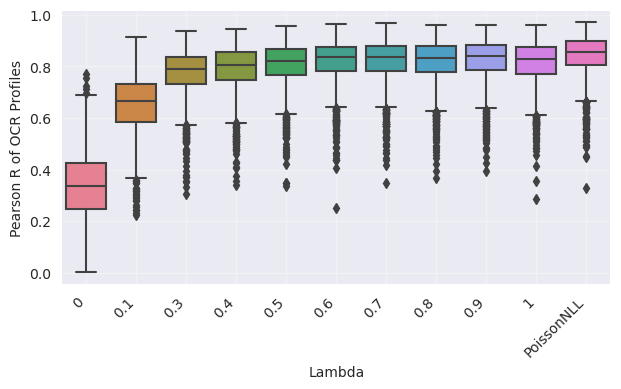

In [ ]:
file_name='save_file_name=testing_analysis_profile_modified.npz_best_loss_model.pth_profile_modified.npz' # this is the best_loss_model path one right now
# file_name = 'testing_correlation_analysis.npz_best_loss_model.pth.npz'
profile_th_lambda_path_dict = {
    '0': "/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-01-2025.07.59/save_file_name=testing_analysis_profile_modified.npz_best_loss_model.pth_profile_modified.npz",
    '0.1': "/data/nchand/analysis/BPcm_250/BP200_L-1_1/complete/04-04-2025.13.53/"+file_name,
    '0.3': "/data/nchand/analysis/BPcm_250/BP200_L-1_3/complete/04-04-2025.07.38/"+file_name,
    '0.4': "/data/nchand/analysis/BPcm_250/BP200_L-1_4/complete/04-01-2025.08.00/"+file_name,
    '0.5': "/data/nchand/analysis/BPcm_250/BP200_L-1_5/complete/04-01-2025.08.22/"+file_name,
    '0.6': "/data/nchand/analysis/BPcm_250/BP200_L-1_6/complete/04-02-2025.05.24/"+file_name,
    '0.7': "/data/nchand/analysis/BPcm_250/BP200_L-1_7/complete/04-02-2025.05.26/"+file_name,
    '0.8': "/data/nchand/analysis/BPcm_250/BP200_L-1_8/complete/04-05-2025.00.08/"+file_name,
    '0.9': "/data/nchand/analysis/BPcm_250/BP200_L-1_9/complete/04-04-2025.22.48/"+file_name,
    '1': "/data/nchand/analysis/BPcm_250/BP200_L0_1/complete/04-04-2025.07.42/"+file_name,
    'PoissonNLL': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/save_file_name=testing_analysis_profile_modified.npz_best_loss_model.pth_profile_modified.npz"
}

for th in thresholds:
    process_and_plot(
        profile_th_lambda_path_dict,
        'top_ocr_jsd_masked_300',
        '',
        'Lambda',
        'JSD of OCR Profiles',
        output_file=f'final_figs/S2d_{th}_boxplot.png',
        dark_grid=True,
    )

    process_and_plot(
        profile_th_lambda_path_dict,
        f'top_ocr_profile_corr_masked_{th}',
        '',
        'Lambda',
        'Pearson R of OCR Profiles',
        output_file=f'final_figs/2e_{th}_boxplot.png',
        dark_grid=True,
    )



# Coefficient of variation vs performance

Specifically we want the variation in real total count value across celltypes 

In [ ]:
from utils import load_observed
from plot_utils import plot_corr_variance
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr



# Load the total count data for test set
# calculate the coefficient of variance for each region
# plot that against the pearson correlation 'scalar_corr' from the analysis_testing.npz file

def coefficient_of_variation(data):
    # Calculate standard deviation along axis 1
    std_dev = np.std(data, axis=1)
    
    # Calculate mean along axis 1
    mean = np.mean(data, axis=1)
    
    # Calculate coefficient of variation
    cv = (std_dev / mean)
    return cv
    
    return cv
def get_coefficient_of_variance(info_file):
    total_counts = load_observed(info_file, dataset_type='test', data_name='total_counts')
    cv = coefficient_of_variation(total_counts)
    return cv

def create_density_scatter_plot(x, y, title, x_label="X", y_label="Y", colormap='viridis'):
    """
    Create a density scatter plot.
    
    Parameters:
    x (array-like): x-coordinates of points
    y (array-like): y-coordinates of points
    title (str): Title of the plot
    x_label (str): Label for x-axis
    y_label (str): Label for y-axis
    colormap (str): Matplotlib colormap to use
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    # Calculate the point density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Sort the points by density, so that the densest points are plotted last
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(x, y, c=z, s=50, alpha=0.5, cmap=colormap)

    # Add a color bar
    plt.colorbar(scatter, label='Density')

    # Set labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

     # Add Pearson correlation coefficient as text
    corr, _ = pearsonr(x, y)
    ax.text(0.05, 0.95, f'Pearson r = {corr:.2f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    return fig

def plot_cv_density(variation, correlation, log_scale=False):
    fig = create_density_scatter_plot(variation, correlation, title='', x_label='Coefficient of variation of Tn5 counts across celltypes', y_label='Pearson R of OCRs across celltypes')
    plt.show()
    plt.savefig('test_cv.png')

run_type = 'complete'
if run_type == 'sample': 
    info_file='/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/sample_random5000_allcell_bias_corrected_normalized_5.28.23/memmap/info.txt'
else:
    info_file='/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_bias_corrected_normalized_3.7.23/memmap/info.txt'

cv = get_coefficient_of_variance(info_file)

lp5_analysis_file = '/data/nchand/analysis/BPcm/BP68_L-1_5/complete/06-10-2024.00.46/testing_analysis.npz'
lp5_scalar_corr = np.load(analysis_file)['scalar_corr']
lp9_scalar_corr 
# plot_cv(cv, scalar_corr)
plot_cv_density(cv, scalar_corr, log_scale=True)
# plot_corr_variance(total_counts, scalar_corr, 'test')

plt.close('all') 



ModuleNotFoundError: No module named 'yaml'

In [ ]:
q1, q2, q3 = np.percentile(cv, [25, 50, 75])
print(q1, q2, q3)

# Create an array of the same length as cv, initialized with zeros
quartile_array = np.zeros_like(cv, dtype=int)

# Assign quartile numbers
quartile_array[cv < q1] = 1
quartile_array[(cv >= q1) & (cv < q2)] = 2
quartile_array[(cv >= q2) & (cv < q3)] = 3
quartile_array[cv >= q3] = 4

# Verify the results
print(f"Shape of quartile_array: {quartile_array.shape}")
print(f"Unique values in quartile_array: {np.unique(quartile_array)}")
print(f"Count of each quartile:")
for i in range(1, 5):
    print(f"Quartile {i}: {np.sum(quartile_array == i)}")

# Print the first few elements of the array as an example
print("\nFirst 20 elements of quartile_array:")
print(quartile_array[:20])

# create a dataframe that has the correlations, the lambda values, and the quartile array

# make boxplot of scalar_corr, with the x axis of the squartile_array, and color the plot by the 'lambda' values 


0.908150315284729 1.2449816465377808 1.6854608058929443
Shape of quartile_array: (32361,)
Unique values in quartile_array: [1 2 3 4]
Count of each quartile:
Quartile 1: 8090
Quartile 2: 8089
Quartile 3: 8091
Quartile 4: 8091

First 20 elements of quartile_array:
[1 1 4 4 1 1 3 4 3 4 2 4 4 4 4 4 4 2 4 3]


In [ ]:
scalar_corr.shape

(32361,)

## Multi / Single Track ablation

In [17]:
from prep_data_utils import average_multi_track, get_lineage_cells
# note T.act cells are not a lineage in the single-track ones- so for that direct comparison- we have to exclude that index
lineage_filepath='/data/nchand/ImmGen/mouse/immgen_lineages.csv'
cell_names_filepath='/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.celltypes.npy'
cell_names = np.load(cell_names_filepath)
lineage_names, lineage_cell_indices = get_lineage_cells(lineage_filepath, cell_names=cell_names)
single_track_lineage_idx = lineage_names.index('T.act')
print('lineage_idx',single_track_lineage_idx)

lineage names ['Stem&Prog', 'B', 'abT', 'T.act', 'gdT', 'ILC', 'myeloid', 'monocyte', 'DC', 'stroma']
lineage_cell_indices [[33, 57, 32], [6, 12, 1, 88, 11, 87, 13, 9, 8, 5, 3, 89, 14, 10, 82, 7, 4, 0, 2], [80, 62, 86, 63, 84, 85, 64, 59, 58, 81, 83, 65, 61, 66, 56], [71, 53, 70, 72, 55, 68, 60, 54, 69], [74, 73, 75, 77, 79, 78, 76], [30, 51, 27, 50, 49, 47, 28, 29, 52, 48], [36, 35, 39, 23, 42, 37, 34, 25, 41, 24, 38], [45, 46], [19, 17, 20, 16, 18], [31, 26, 21, 22, 15]]
lineage_idx 3


fig size is (3.5, 4.75)

Wilcoxon rank-sum test between Multi-track celltype and Multi-track lineage:
  p-value = 3.7210e-77
 N 32361

Wilcoxon rank-sum test between Multi-track lineage and Single-track:
  p-value = 3.6109e-154
 N 32361
Boxplot has been saved as 'rebuttal_figs/2f_track_corr_x_lineage'


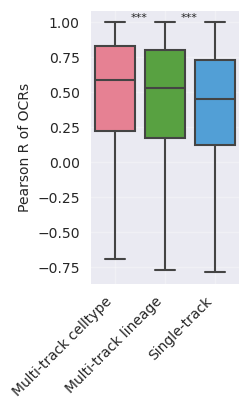

fig size is (3.5, 4.75)

Wilcoxon rank-sum test between Multi-track celltype and Multi-track lineage:
  p-value = 1.9531e-03
 N 10
Multi-track lineage N= 10, Single-track N=9
Multi-track lineage, [0.6643065  0.75519943 0.6957341  0.700338   0.6662943  0.67843664
 0.7890623  0.7252626  0.7763306  0.7804091 ]
Single-track, [0.75382674 0.7069677  0.77558964 0.6692202  0.63312894 0.6919346
 0.78341544 0.69531775 0.7857153 ]

Wilcoxon rank-sum test between Multi-track lineage and Single-track:
  p-value = 1.0000e+00
 N 10
Boxplot has been saved as 'rebuttal_figs/S4b_track_corr_x_ocr'


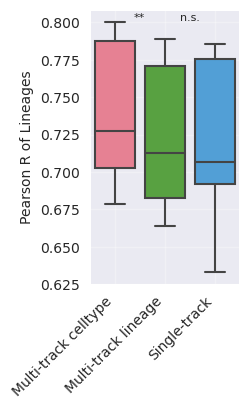

In [18]:
track_path_dict = {
    'Multi-track celltype': '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/lineage_track_averaged_testset_corr_best_loss.npz',
    #'Multi-track celltype': '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/lineage_track_averaged_testset_corr.npz',
    # 'Multi-track lineage': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP216_L-1_5/complete/04-11-2025.08.31/testset_corr.npz",
    'Multi-track lineage': "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP216_L-1_5/complete/04-11-2025.08.31/testset_corr_best_loss_model.npz",
    'Single-track': '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BPcm_250_217-225_single_track_combined_testset_corr.npz'
}   


process_and_plot(
    track_path_dict,
    'pearson_corr_cross_celltype',
    '',
    '',
    'Pearson R of OCRs',
    output_file='rebuttal_figs/2f_track_corr_x_lineage',
    dark_grid=True,
    fliers=False,
    show_pvalue_all=True
)



process_and_plot(
    track_path_dict,
    'pearson_corr_cross_ocr',
    '',
    '',
    'Pearson R of Lineages',
    output_file='rebuttal_figs/S4b_track_corr_x_ocr',
    dark_grid=True,
    show_pvalue_all=True
)



# Figure 1
a. example profiles and total counts matrix

For figure 1a make example distributions

(100, 90, 1000)
37
tc 1 3320.0
tc 2 1092.0
max y  122.0


<Figure size 640x480 with 0 Axes>

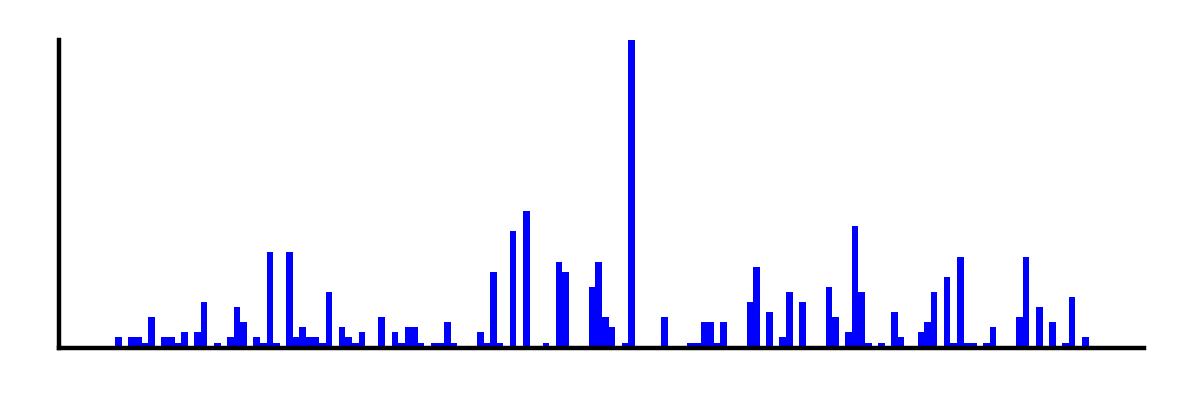

<Figure size 640x480 with 0 Axes>

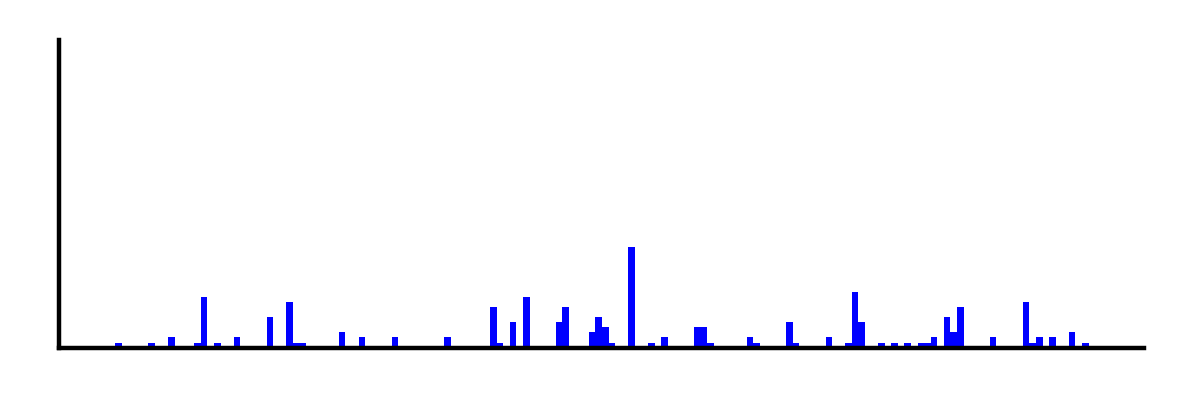

In [ ]:
profile_path = '/data/nchand/ImmGen/mouse/BPprofiles1000/sample_profile.counts.npy'
total_counts_path = '/data/nchand/ImmGen/mouse/BPprofiles1000/sample_profile.summed_counts.npy'
profile = np.load(profile_path).astype(np.float32)
total_counts= np.load(total_counts_path).astype(np.float32)
print(profile.shape)

def plot_profile(obs_prof, ymax=None, save_file=None):
    """
    obs_prof and pred_prof are expected
    to be np arrays with a single dimension
    """
    plt.clf()
    fig = plt.figure(figsize = (3.5, 1), dpi = 400)
    ax = fig.add_subplot()
    x_axis = np.arange(np.shape(obs_prof)[-1])
    ax.bar(x_axis, obs_prof, alpha = 1, color = 'blue', width=1, linewidth=0, align='center')

    # Set the y-axis limit if specified
    if ymax is not None:
        ax.set_ylim(0, ymax)

    # fig.savefig(out_path)
    ax.set_facecolor('white')  # White background
    fig.patch.set_facecolor('white')  # White figure background
    ax.spines['top'].set_visible(False)  # Remove top border
    ax.spines['right'].set_visible(False)  # Remove right border
    ax.spines['bottom'].set_visible(True)  # Remove top border
    ax.spines['left'].set_visible(True)  # Remove top border

    # Remove all axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    
    if save_file is not None:
        plt.savefig(save_file, dpi=500, transparent=True)
    plt.show()


idx = 10
celltype = 0
max_celltype = np.argmax(np.sum(profile[idx, :, :], axis=-1))
print(max_celltype)
# plot_profile(profile[idx, max_celltype, :])


cell_idx_1 = 37
cell_idx_2 = 36
tc_1 = total_counts[idx, cell_idx_1]
tc_2 = total_counts[idx, cell_idx_2]
print('tc 1', tc_1)
print('tc 2', tc_2)
# Calculate profiles
profile_1 = profile[10, cell_idx_1, 675:825] 
profile_2 = profile[10, cell_idx_2, 675:825] 
# profile_1 = profile[10, cell_idx_1, 700:800] 
# profile_2 = profile[10, cell_idx_2, 700:800] 

max_y = max(np.max(profile_1), np.max(profile_2)) 
print('max y ', max_y)

# Plot both profiles with the same y-axis maximum
plot_profile(profile_1, ymax=max_y, save_file=f'final_figs/profile_ex_cell{cell_idx_1}_{idx}_150')
plot_profile(profile_2, ymax=max_y, save_file=f'final_figs/profile_ex_cell{cell_idx_2}_{idx}_150')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import OrderedDict

def plot_clustered_heatmap(data_matrix, cell_types, lineage_indices, 
                          figsize=(12, 8), cmap="YlOrRd", 
                          lineage_colors=None, 
                          row_cluster=True):
    """
    Create a clustered heatmap with colored annotations for cell lineages.
    
    Parameters:
    -----------
    data_matrix : numpy.ndarray
        2D numpy array containing the data to be plotted
    cell_types : list
        List of cell type names corresponding to columns in data_matrix
    lineage_indices : dict
        Dictionary mapping lineage names to lists of column indices
        e.g., {'Myeloid': [0,1,2], 'Lymphoid': [3,4,5]}
    figsize : tuple, optional
        Figure size in inches (width, height)
    cmap : str, optional
        Colormap for the heatmap
    lineage_colors : dict, optional
        Dictionary mapping lineages to colors. If None, colors will be automatically assigned
    row_cluster : bool, optional
        Whether to cluster rows
    """
    # Create lineage color mapping if not provided
    if lineage_colors is None:
        colors = sns.color_palette(n_colors=len(lineage_indices))
        lineage_colors = dict(zip(lineage_indices.keys(), colors))
    
    # Create a new ordering for columns based on lineage groupings
    new_order = []
    cell_type_to_lineage = {}
    
    # First create the mapping for all cell types to their lineages
    for lineage, indices in lineage_indices.items():
        for idx in indices:
            cell_type_to_lineage[cell_types[idx]] = lineage
    
    # Add indices in order of lineages, ensuring complete grouping
    for lineage in lineage_indices.keys():
        new_order.extend(sorted(lineage_indices[lineage]))
        
    # Force complete grouping by disabling column clustering
    col_cluster = False
    
    # Reorder the data matrix and cell types
    reordered_data = data_matrix[:, new_order]
    reordered_cell_types = [cell_types[i] for i in new_order]
    
    # Convert data to DataFrame with reordered columns
    df = pd.DataFrame(reordered_data, columns=reordered_cell_types)
    
    # Create column colors based on the new order
    col_colors = pd.Series(
        [lineage_colors[cell_type_to_lineage[ct]] for ct in reordered_cell_types],
        index=reordered_cell_types
    )
    
    # Create the clustered heatmap
    g = sns.clustermap(
        df,
        figsize=figsize,
        cmap=cmap,
        col_colors=col_colors,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        yticklabels=False,  # Remove row labels
        xticklabels=False,  # Remove column labels
        dendrogram_ratio=(0, 0),  # Remove dendrograms
        cbar_pos=None,  # Remove the color gradient bar
        tree_kws={'linewidths': 0}  # Hide dendrogram lines
    )
    
    # Remove all ticks
    g.ax_heatmap.set_xticks([])
    g.ax_heatmap.set_yticks([])
    
    # Add lineage labels above the color bars
    if hasattr(g, 'ax_col_colors'):
        # Create a mapping of cell type positions
        positions = {ct: i for i, ct in enumerate(reordered_cell_types)}
        
        # Track the ranges for each lineage in the reordered data
        lineage_ranges = {}
        current_lineage = None
        start_idx = 0
        
        for i, ct in enumerate(reordered_cell_types):
            lineage = cell_type_to_lineage[ct]
            if current_lineage != lineage:
                if current_lineage is not None:
                    lineage_ranges[current_lineage] = (start_idx, i)
                current_lineage = lineage
                start_idx = i
        # Don't forget the last group
        lineage_ranges[current_lineage] = (start_idx, len(reordered_cell_types))
        
        # Add the labels at the middle of each lineage's range
        for lineage, (start, end) in lineage_ranges.items():
            # Calculate the exact middle of the section
            middle = start + (end - start) / 2
            g.ax_col_colors.text(middle, 1.2, lineage,
                               ha='center', va='bottom',
                               rotation=90,
                               transform=g.ax_col_colors.get_xaxis_transform())
    
    return g


lineage names ['Stem&Prog', 'B', 'abT', 'T.act', 'gdT', 'ILC', 'myeloid', 'monocyte', 'DC', 'stroma']
lineage_cell_indices [[57, 32, 33], [82, 10, 2, 87, 8, 13, 7, 3, 88, 4, 14, 6, 12, 9, 11, 0, 5, 89, 1], [83, 85, 58, 59, 56, 63, 61, 65, 62, 86, 81, 66, 80, 64, 84], [71, 55, 53, 70, 69, 60, 72, 54, 68], [73, 75, 79, 74, 78, 76, 77], [48, 30, 47, 51, 28, 50, 49, 27, 29, 52], [23, 41, 39, 34, 37, 42, 38, 36, 25, 24, 35], [45, 46], [20, 17, 16, 19, 18], [26, 22, 15, 31, 21]]
(1000, 90)


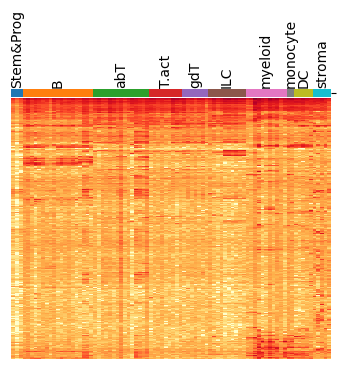

In [ ]:
from prep_data_utils import get_lineage_cells

total_counts_path = '/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.summed_counts.npy'
lineage_filepath='/data/nchand/ImmGen/mouse/immgen_lineages.csv'
cell_names_filepath='/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.celltypes.npy'

cell_names = np.load(cell_names_filepath)
lineage_names, lineage_cell_indices = get_lineage_cells(lineage_filepath, cell_names=cell_names)

lineage_map = dict(zip(lineage_names, lineage_cell_indices))

n_examples = 1000
total_counts = np.load(total_counts_path)[:n_examples]
print(total_counts.shape)
# Example usage:
# Example data
np.random.seed(42)
n_rows, n_cols = 100, 10
data = total_counts

# First apply the log transformation
pseudocount = 1
log_base = 2
# Log transform the data
log_data = np.log(total_counts + pseudocount) / np.log(log_base)

# Create the plot
g = plot_clustered_heatmap(
    data_matrix=log_data,
    cell_types=cell_names,
    lineage_indices=lineage_map,
    # lineage_colors=lineage_colors,
    figsize=(3.5, 3)
)
plt.savefig('final_figs/count_matrix_log.png', dpi=350, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
plt.savefig('final_figs/count_matrix.png', dpi=350)
# Create the plot
g = plot_clustered_heatmap(
    data_matrix=total_counts,
    cell_types=cell_names,
    lineage_indices=lineage_map,
    # lineage_colors=lineage_colors,
    figsize=(2, 2)
)
plt.show()

NameError: name 'plt' is not defined

### Figure 1c Correlation across peaks scatter plot

We have these correlations already generateb by the `corr_across_peaks.py` script


'/data/nchand/analysis/BPcm_250/BP200_L0_0/peak_corr_testing_corr.npz'  5 trials
'/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/peak_corr_testing_corr.npz'  5 trials


Take only the trials where none of the values are zero

In [72]:
import numpy as np
def get_mean_corr_filtered(l0_corr, lp5_corr):
    # Create masks for non-zero rows
    l0_mask = ~(l0_corr == 0).all(axis=1)  # True for rows that have at least one non-zero value
    lp5_mask = ~(lp5_corr == 0).all(axis=1)

    # Apply the masks to get filtered arrays
    l0_corr_filtered = l0_corr[l0_mask]
    lp5_corr_filtered = lp5_corr[lp5_mask]

    print(l0_corr_filtered.shape)
    print(lp5_corr_filtered.shape)

    # there are 6 more trials available of the lp5 than the l0, so I will take the first 8 of both
    lp5_corr_filtered=lp5_corr_filtered[:8]
    print(lp5_corr_filtered.shape)

    # Now I will average over the trials
    l0_mean = np.mean(l0_corr_filtered, axis=0)
    lp5_mean = np.mean(lp5_corr_filtered, axis=0)
    return l0_mean, lp5_mean


In [73]:
def make_drg_txt(peak_names, correlation, output_file):
    with open(output_file, 'w') as f:
        for name, value in zip(peak_names, correlation):
            f.write(f"{name} {value}\n")

In [74]:
from utils import load_names

eval_set = 'test'
peak_names = load_names('/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt', eval_set)
testset_scalar_counts = load_observed('/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt', dataset_type='test', data_name='total_counts')
l0_corr_file = '/data/nchand/analysis/BPcm_250/BP200_L0_0/peak_corr_testing_corr.npz'
lp5_corr_file = '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/peak_corr_testing_corr.npz'
x_ocr_pearson_l0_corr = np.load(l0_corr_file)['all_corr_x_ocr']
x_ocr_pearson_lp5_corr = np.load(lp5_corr_file)['all_corr_x_ocr']

x_ocr_spearman_l0_corr = np.load(l0_corr_file)['all_spearman_corr_x_ocr']
x_ocr_spearman_lp5_corr = np.load(lp5_corr_file)['all_spearman_corr_x_ocr']

x_celltype_pearson_l0_corr = np.load(l0_corr_file)['all_corr_x_celltype']
x_celltype_pearson_lp5_corr = np.load(lp5_corr_file)['all_corr_x_celltype']
x_celltype_spearman_l0_corr = np.load(l0_corr_file)['all_spearman_corr_x_celltype']
x_celltype_spearman_lp5_corr = np.load(lp5_corr_file)['all_spearman_corr_x_celltype']


x_ocr_pearson_l0_mean, x_ocr_pearson_lp5_mean = get_mean_corr_filtered(x_ocr_pearson_l0_corr, x_ocr_pearson_lp5_corr)
x_ocr_spearman_l0_mean, x_ocr_spearman_lp5_mean = get_mean_corr_filtered(x_ocr_spearman_l0_corr, x_ocr_spearman_lp5_corr)

x_celltype_pearson_l0_mean, x_celltype_pearson_lp5_mean = get_mean_corr_filtered(x_celltype_pearson_l0_corr, x_celltype_pearson_lp5_corr)
x_celltype_spearman_l0_mean, x_celltype_spearman_lp5_mean = get_mean_corr_filtered(x_celltype_spearman_l0_corr, x_celltype_spearman_lp5_corr)

# combine peak_names and x_celltype_pearson_l0_mean as txt file in the following format:
make_drg_txt(peak_names, x_celltype_pearson_l0_mean, 'final_figs/x_celltype_pearson_l0_mean.txt')
make_drg_txt(peak_names, x_celltype_pearson_lp5_mean, 'final_figs/x_celltype_pearson_lp5_mean.txt')
make_drg_txt(peak_names, x_celltype_spearman_l0_mean, 'final_figs/x_celltype_spearman_l0_mean.txt')
make_drg_txt(peak_names, x_celltype_spearman_lp5_mean, 'final_figs/x_celltype_spearman_lp5_mean.txt')





file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.names.dat
shape (32361,)
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.total_counts.dat
(5, 90)
(5, 90)
(5, 90)
(5, 90)
(5, 90)
(5, 90)
(5, 32361)
(5, 32361)
(5, 32361)
(5, 32361)
(5, 32361)
(5, 32361)


For the cross celltype datatpoints (where there is data for each OCR) I will use Alex's code

For spearman corr x ocrs

``python scatter_comparison_plot.py ~/MostafaviLab/bpAITAC/final_figs/x_celltype_spearman_l0_mean.txt ~/MostafaviLab/bpAITAC/final_figs/x_celltype_spearman_lp5_mean.txt "AI-TAC" "bpAI-TAC" --savefig ~/MostafaviLab/bpAITAC/rebuttal_figs/S1a_spearman_corr_l0_lp5 --plotdiagonal --zeroxaxis --zeroyaxis --contour --density --xysamelim``

In [45]:
d = np.load('/data/nchand/analysis/BPcm/BP68_L0_0_extra/peak_corr_testing3_extra_complete_corr.npz')
d.files

['trial_avg_corr_x_ocr',
 'all_corr_x_celltype',
 'all_corr_x_ocr',
 'all_spearman_corr_x_celltype',
 'all_spearman_corr_x_ocr',
 'trial_avg_spearman_corr_x_ocr']

In [46]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

def scatter_plot_corr_simple(vals1, vals2, namex, namey, outname, dpi=300, show_r=False, figsize=(3.5, 3.5)): 
    # Set style to remove dark background
    plt.style.use('default')  # or plt.style.use('classic')
    
    plt.clf()
    vals = np.array([vals1, vals2])

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111)
    
    # Remove grid
    ax.grid(False)
    
    # Set white background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    
    # Show only left and bottom spines (axes)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # Make spines black
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    
    alpha = 0.75
    lw = 0.5

    # Find the overall min and max
    overall_min = min(np.min(vals1), np.min(vals2))
    overall_max = max(np.max(vals1), np.max(vals2))
    
    # Add padding to the limits (e.g., 5% of the data range)
    data_range = overall_max - overall_min
    padding = 0.05 * data_range
    plot_min = overall_min - padding
    plot_max = overall_max + padding
    
    # Set both axes to the same padded limits
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.axis('equal')
    
    # Plot diagonal for the full range
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color='maroon')

    # Scatter plot
    a = ax.scatter(vals[0], vals[1], alpha=alpha, vmin=0, vmax=1, 
                   edgecolor='silver', lw=lw)

    ax.set_xlabel(namex)
    ax.set_ylabel(namey)

    if show_r:
        r_value, p_value = pearsonr(vals1, vals2)
        ax.text(0.05, 0.95, f'r = {r_value:.2f}', transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    print(outname+'_scatter.png')
    fig.savefig(outname+'_scatter.png', dpi=dpi, bbox_inches='tight')
    plt.show()


In [69]:
def scatter_plot_corr_simple_2(vals1, vals2, namex, namey, outname, dpi=300, show_r=False, figsize=(3.5, 3.5), tick_frequency=None): 
    # Set style to remove dark background
    plt.style.use('default')  # or plt.style.use('classic')
    
    plt.clf()
    vals = np.array([vals1, vals2])

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111)
    
    # Remove grid
    ax.grid(False)
    
    # Set white background
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    
    # Show only left and bottom spines (axes)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # Make spines black
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    
    alpha = 0.75
    lw = 0.5

    # Find the overall min and max
    overall_min = min(np.min(vals1), np.min(vals2))
    overall_max = max(np.max(vals1), np.max(vals2))
    
    # Add padding to the limits (e.g., 5% of the data range)
    data_range = overall_max - overall_min
    padding = 0.05 * data_range
    plot_min = overall_min - padding
    plot_max = overall_max + padding
    
    # Set both axes to the same padded limits
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.axis('equal')
    
    # Set tick frequency if specified
    if tick_frequency is not None:
        # Round plot_min down and plot_max up to nearest tick_frequency
        tick_min = np.floor(plot_min / tick_frequency) * tick_frequency
        tick_max = np.ceil(plot_max / tick_frequency) * tick_frequency
        
        # Generate tick values
        tick_values = np.arange(tick_min, tick_max + tick_frequency/2, tick_frequency)
        
        ax.set_xticks(tick_values)
        ax.set_yticks(tick_values)
    
    # Plot diagonal for the full range
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color='maroon')

    # Scatter plot
    a = ax.scatter(vals[0], vals[1], alpha=alpha, vmin=0, vmax=1, 
                   edgecolor='silver', lw=lw)

    ax.set_xlabel(namex)
    ax.set_ylabel(namey)

    if show_r:
        r_value, p_value = pearsonr(vals1, vals2)
        ax.text(0.05, 0.95, f'r = {r_value:.2f}', transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    print(outname+'_scatter.png')
    fig.savefig(outname+'_scatter.png', dpi=dpi, bbox_inches='tight')
    plt.show()


rebuttal_figs/1c_corr_x_ocr_l0_vs_lp5_scatter.png


<Figure size 640x480 with 0 Axes>

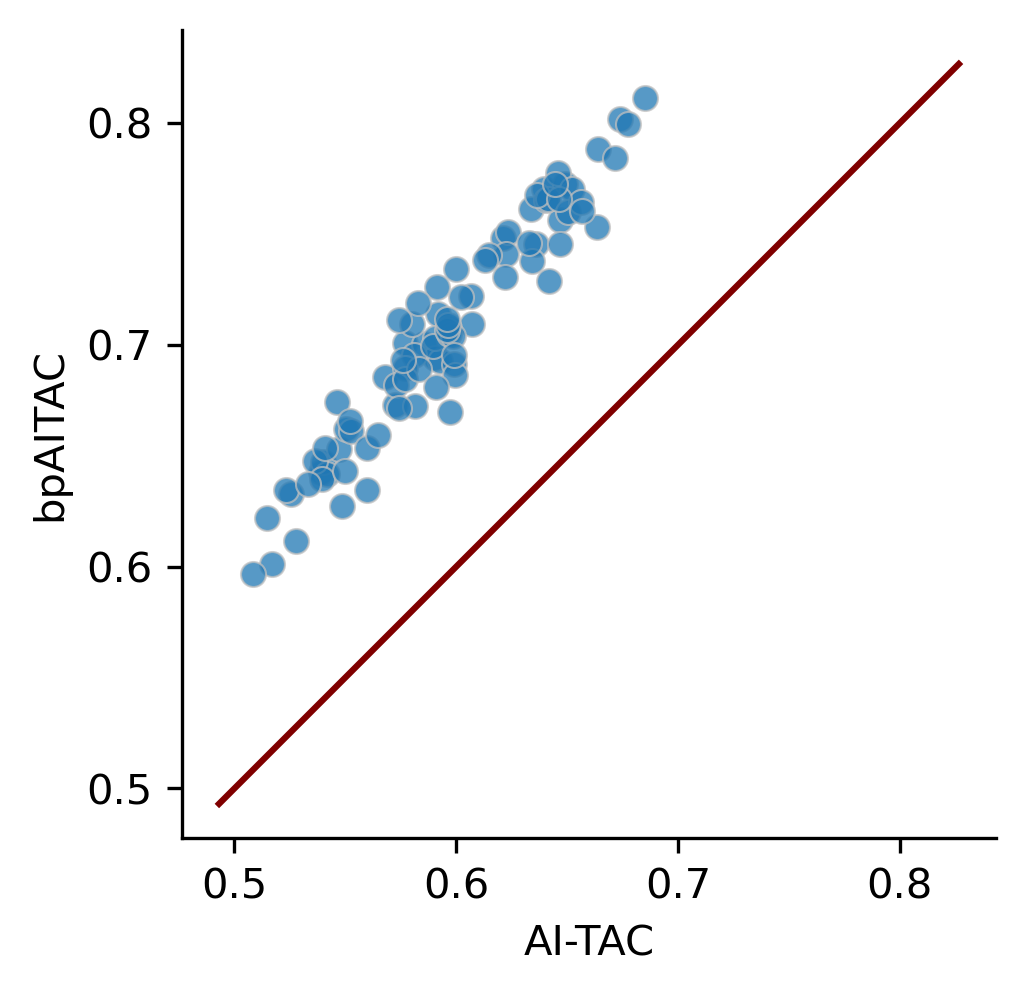

rebuttal_figs/S1b_spearman_corr_x_ocr_l0_vs_lp5_scatter.png


<Figure size 640x480 with 0 Axes>

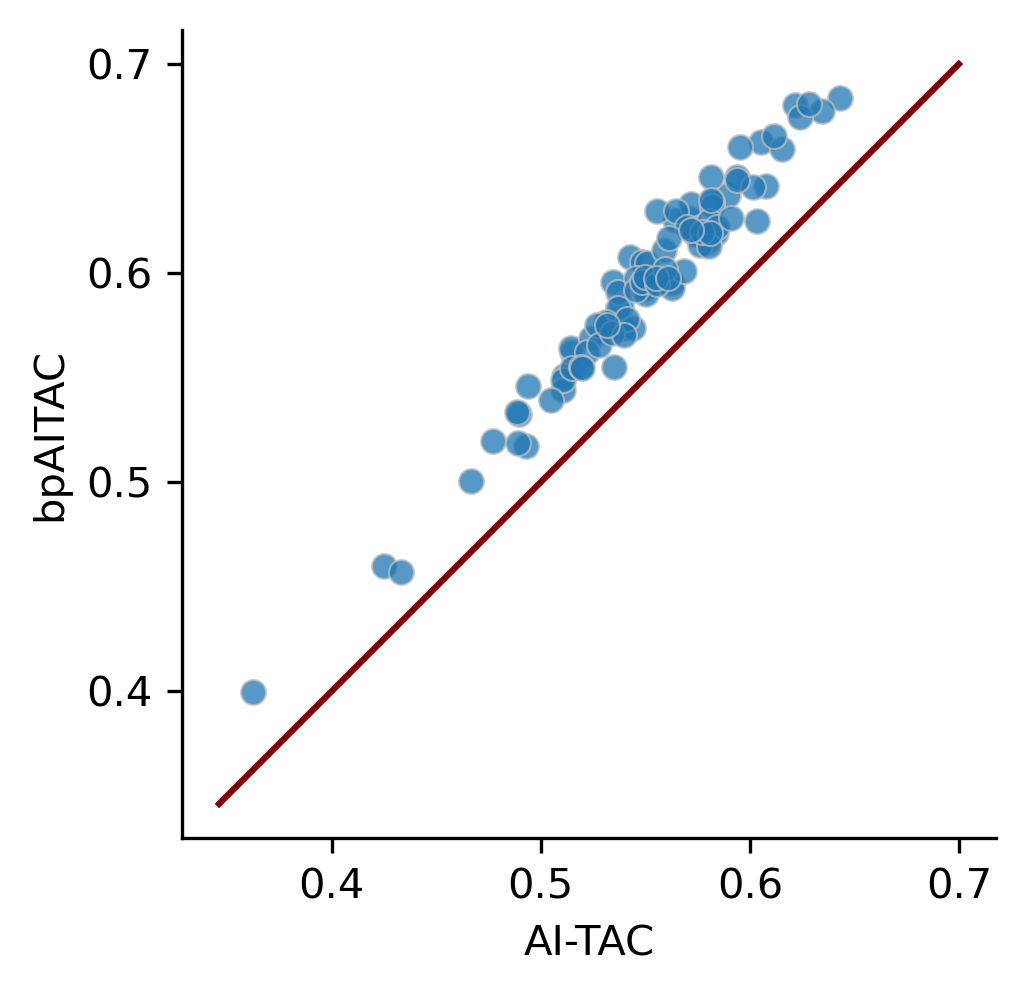

In [75]:
# scatter_plot_corr_simple(x_ocr_pearson_l0_mean, x_ocr_pearson_lp5_mean, namex='AI-TAC', namey='bpAITAC', outname='final_figs/1c_corr_x_ocr_l0_vs_lp5')
scatter_plot_corr_simple_2(x_ocr_pearson_l0_mean, x_ocr_pearson_lp5_mean, namex='AI-TAC', namey='bpAITAC', outname='rebuttal_figs/1c_corr_x_ocr_l0_vs_lp5', tick_frequency=0.1)
plt.show()

scatter_plot_corr_simple_2(x_ocr_spearman_l0_mean, x_ocr_spearman_lp5_mean, namex='AI-TAC', namey='bpAITAC', outname='rebuttal_figs/S1b_spearman_corr_x_ocr_l0_vs_lp5', tick_frequency=0.1)
plt.show()


### P values for 1c and S1b

In [50]:
print('1c rank-sum')
wilcoxon_signed_rank(x_ocr_pearson_l0_mean, x_ocr_pearson_lp5_mean)

print('S1b rank sum')
wilcoxon_signed_rank(x_ocr_spearman_l0_mean, x_ocr_spearman_lp5_mean)



1c rank-sum

--- Wilcoxon Rank-sum Test Results ---
N = 90
Test statistic: 0.0
P-value: 1.7437900167092118e-16
S1b rank sum

--- Wilcoxon Rank-sum Test Results ---
N = 90
Test statistic: 0.0
P-value: 1.7437900167092118e-16


1.7437900167092118e-16

In [8]:
from load_model import load_model, get_predictions
from utils import load_data
from eval_model import get_model_structure
import os
import numpy as np
def get_scalar_pred_obs(saved_model_path, infofile_path, n_celltypes, saved_file_name='scalar_predictions.npz', model_type='BPcm'):
    """
    returns scalar pred and scalar obs
    """
    n_filters = 300
    get_scalar_prediction = True
    get_profile_prediction = False
    get_scalar_observed = True
    get_profile_observed = False
    eval_set = 'testing'
    bin_size = 1
    model_dir = os.path.dirname(saved_model_path)
    ocr_start = 375
    ocr_end = 625

    model_structure = get_model_structure(model_type, n_filters, n_celltypes)
    model = load_model(saved_model_path, model_structure=model_structure)

    train_loader, val_loader, test_loader = load_data(infofile_path, batch_size=100)

    get_predictions(model, train_loader, val_loader, test_loader, 
                    n_celltypes, 
                    get_scalar_prediction, get_profile_prediction,
                    get_scalar_observed, get_profile_observed,
                    eval_set,
                    bin_size,
                    model_dir,
                    saved_file_name = saved_file_name, 
                    batch_size=100, 
                    save_pred=True,
                    ocr_start=ocr_start, ocr_end=ocr_end,)

    # saved file path
    path = os.path.join(model_dir, saved_file_name)
    data = np.load(path)
    scalar_obs = data['scalar_obs']
    scalar_pred = data['scalar_pred']

    return scalar_pred, scalar_obs


Get results from lambda = 0 model

In [ ]:
lambda_0_model_path = ''
get_scalar_pred_obs()

# Supplementary discussion figures S9

In [ ]:
import numpy as np
no_bias_model_corr =  np.load("/homes/gws/nchand/MostafaviLab/results/BPcm_bias0/BP127_L-1_5/complete/12-26-2024.18.38/testing_analysis.npz")['scalar_corr']
bpAITAC_corr =  np.load("/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP126_L-1_5/complete/11-17-2024.11.51/testing_analysis.npz")['scalar_corr']


# get the pearson correlation values
make_drg_txt(peak_names, no_bias_model_corr, 'final_figs/x_celltype_pearson_bias0_BP127.txt')
make_drg_txt(peak_names, bpAITAC_corr, 'final_figs/x_celltype_pearson_bpAITAC250_BP126.txt')

# make a sizes file based on the colorfile
colorfile = ''
with open('/data/nchand/analysis/BPcm/BP68_analysis/testing_lineage_v3/selected_peak_l0_l5_color_file.txt', 'r') as f:
    lines = f.readlines()

with open('/data/nchand/analysis/BPcm/BP68_analysis/testing_lineage_v3/selected_peak_l0_l5_dot_size_file.txt', 'w') as f:
    for line in lines:
        parts = line.strip().split()
        size = "2" if parts[1] == "0" else "20"
        f.write(f"{parts[0]} {size}\n")

# 
# # then turn it into a txt file and send it to Alex's scatter plot
# I need to take the pearson correlation of these 

Call Alex's scatter plot using 
`python scatter_comparison_plot.py ~/MostafaviLab/bpAITAC/final_figs/x_celltype_pearson_bpAITAC250_BP126.txt ~/MostafaviLab/bpAITAC/final_figs/x_celltype_pearson_bias0_BP127.txt "With Bias" "Without Bias" --savefig ~/MostafaviLab/bpAITAC/final_figs/S9_scatter_bias --plotdiagonal --contour --zeroxaxis --zeroyaxis --colorfile /data/nchand/analysis/BPcm/BP68_analysis/testing_lineage_v3/selected_peak_l0_l5_color_file.txt 0 --alpha 0.7 --sizefile /data/nchand/analysis/BPcm/BP68_analysis/testing_lineage_v3/selected_peak_l0_l5_dot_size_file.txt`

In [ ]:
no_bias_model['scalar_corr'].shape

(32361,)

In [ ]:
# Find some peaks where both no_bias_model_corr and bpAITAC_corr are good 

indices = np.where((no_bias_model_corr > 0.7) & (bpAITAC_corr > 0.7))[0]
print(indices.shape)

with open('/data/nchand/analysis/BPcm/BP68_analysis/testing_lineage_v3/selected_peak_l0_l5_color_file.txt', 'r') as file:
    lines = file.readlines()
    peak_names = [line.split()[0] for line in lines]
    selected_indicator = [float(line.split()[1]) for line in lines]

peak_names= np.array(peak_names)
selected_indicator = np.array(selected_indicator)

print(peak_names)
print(selected_indicator)
print(len(selected_indicator))
indices = np.where((no_bias_model_corr > 0.7) & (bpAITAC_corr > 0.7) & (selected_indicator != 0))[0]
print(len(indices))

print('possible peak names:', peak_names[indices])


(6197,)
['ImmGenATAC1219.peak_185708' 'ImmGenATAC1219.peak_185711'
 'ImmGenATAC1219.peak_185719' ... 'ImmGenATAC1219.peak_95896'
 'ImmGenATAC1219.peak_95897' 'ImmGenATAC1219.peak_95898']
[0. 0. 0. ... 0. 0. 0.]
32361
89
possible peak names: ['ImmGenATAC1219.peak_186667' 'ImmGenATAC1219.peak_187460'
 'ImmGenATAC1219.peak_187506' 'ImmGenATAC1219.peak_188359'
 'ImmGenATAC1219.peak_189839' 'ImmGenATAC1219.peak_189879'
 'ImmGenATAC1219.peak_190187' 'ImmGenATAC1219.peak_190669'
 'ImmGenATAC1219.peak_190910' 'ImmGenATAC1219.peak_191351'
 'ImmGenATAC1219.peak_191736' 'ImmGenATAC1219.peak_192500'
 'ImmGenATAC1219.peak_193507' 'ImmGenATAC1219.peak_194046'
 'ImmGenATAC1219.peak_194826' 'ImmGenATAC1219.peak_195239'
 'ImmGenATAC1219.peak_195431' 'ImmGenATAC1219.peak_195819'
 'ImmGenATAC1219.peak_195921' 'ImmGenATAC1219.peak_196110'
 'ImmGenATAC1219.peak_196300' 'ImmGenATAC1219.peak_196904'
 'ImmGenATAC1219.peak_197674' 'ImmGenATAC1219.peak_198625'
 'ImmGenATAC1219.peak_198646' 'ImmGenATAC1219.peak_

# Rebuttle 
OCR open - we can define as > 100 counts or something like this

In [40]:
import torch
import gc

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    
# Force garbage collection
gc.collect()

10099

In [41]:
from utils import load_observed
from utils import load_names
import numpy as np

info_file = '/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt'
peak_names = load_names(info_file, dataset_type='test')
cell_names = np.load("/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.celltypes.npy")
lineage_filepath = 'immgen_lineages.csv'

test_onehot = load_observed(info_file, dataset_type='test', data_name='onehot')
test_onehot = test_onehot.transpose((0, 2, 1))
test_bias = load_observed(info_file, dataset_type='test', data_name='bias')
test_counts = load_observed(info_file, dataset_type='test', data_name='total_counts')
test_bpcounts = load_observed(info_file, dataset_type='test', data_name='bp_counts')
print(test_counts.shape)

file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.names.dat
shape (32361,)
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.onehot.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bias.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.total_counts.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bp_counts.dat
(32361, 90)


In [42]:
from eval_model import get_model_structure
from load_model import load_model
from region_identification_utils import get_lineage_cells
from region_identification_utils import get_lineage_counts
from load_model import DEVICE
from modules import AverageWrapper

# Load the models 
aitac_dir = '/data/nchand/analysis/BPcm_250/BP200_L0_0/'
path_aitac = '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.04/best_model'
bpaitac_dir = '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/'
path_bpaitac = '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.18.35/best_model'

n_celltypes = 90
n_filters = 300
seq_len = 998
model_type = 'BPcm_250'

aitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)
bpaitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)

model_aitac = load_model(path_aitac, model_structure=aitac_structure, n_filters=n_filters, verbose=False)
model_bpaitac = load_model(path_bpaitac, model_structure=bpaitac_structure, n_filters=n_filters, verbose=False)

n_lineages = 10
lineage_names, lineage_cell_indices = get_lineage_cells(lineage_filepath, cell_names=cell_names)
lineage_model_aitac = AverageWrapper(model_aitac, lineage_cell_indices)
lineage_model_bpaitac = AverageWrapper(model_bpaitac, lineage_cell_indices)





199
39
7
199
39
7
DEVICE is cuda:1
998 300 90
DEVICE is cuda:1
998 300 90


/homes/gws/nchand/MostafaviLab/bpAITAC/load_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_path))


In [43]:
import torch

# Compare a layer's weights
aitac_params = dict(model_aitac.named_parameters())
bpaitac_params = dict(model_bpaitac.named_parameters())

# Pick any layer to compare
layer_name = list(aitac_params.keys())[0]
print(f"Are weights identical? {torch.equal(aitac_params[layer_name].cpu(), bpaitac_params[layer_name].cpu())}")

# Or check multiple layers
for layer_name in list(aitac_params.keys())[:5]:  # Check first 5 layers
    are_equal = torch.equal(aitac_params[layer_name].cpu(), bpaitac_params[layer_name].cpu())
    print(f"{layer_name}: {'IDENTICAL' if are_equal else 'DIFFERENT'}")


Are weights identical? False
body.net.0.weight: DIFFERENT
body.net.0.bias: DIFFERENT
body.net.1.net.0.conv_block.0.weight: DIFFERENT
body.net.1.net.0.conv_block.0.bias: DIFFERENT
body.net.1.net.0.conv_block.1.weight: DIFFERENT


In [23]:
from utils import predict_all
from utils import predict_scalar

import torch
def get_averaged_scalar_predictions(model_list, x, n_tracks):
    model_preds_sum = torch.zeros((len(x), n_tracks)).to(DEVICE)
    for model in model_list:
        model_preds = predict_scalar(model, x, n_celltypes=n_lineages, device=DEVICE)
        model_preds_sum = model_preds_sum + model_preds
    return model_preds_sum / len(model_list)

Load all the scalar predictions

In [46]:

# del model_bpaitac
# torch.cuda.empty_cache()
# bpaitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)
# model_bpaitac = load_model(path_bpaitac, model_structure=bpaitac_structure, n_filters=n_filters, verbose=False)

X = torch.tensor(test_onehot[:10])
bias = torch.zeros((X.shape[0], X.shape[2]))
device = 'cuda'
model_bpaitac.to(device)
with torch.no_grad():
    profile, scalar = model_bpaitac(X.to(device), bias.to(device))
print(scalar)

tensor([[  7.7672,   6.3948,   6.0580,   6.3708,   6.9460,   6.8677,   6.9113,
          10.4764,   7.6784,   6.5745,   6.1684,   6.8645,   6.7224,   5.7577,
           6.1612,  11.9594,   5.0792,   4.4017,   4.7670,   5.2488,   5.9251,
          10.1890,   9.7041,   9.5127,   8.6316,   7.0262,   4.5546,   9.2985,
           7.8169,   8.5620,   8.3096,  10.0111,   6.8126,   6.7244,   4.4189,
           6.0482,   6.0033,   5.3193,   5.3800,   7.1163,   5.3747,   7.6080,
           6.1219,   5.0119,   3.4471,   7.1956,   7.3659,   7.0459,   7.3727,
           7.2021,   7.3552,   8.7565,   8.9841,   7.4297,   7.7795,   7.7856,
           8.3411,   4.1940,   7.7237,   9.0435,   7.2806,   8.5741,   7.5499,
           7.4553,   7.7003,   8.8358,   7.6798,   8.4174,   7.7562,   8.7718,
           7.7570,   7.9683,   8.4146,   6.7088,   6.5454,   8.2458,   7.5422,
           8.6236,   7.6856,   9.8942,   8.6580,   7.0158,   9.4216,   3.8872,
           4.8355,   7.2678,   7.6434,   4.2666,   5

In [47]:
# del model_aitac
# torch.cuda.empty_cache()
# aitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)
# model_aitac = load_model(path_aitac, model_structure=aitac_structure, n_filters=n_filters, verbose=False)

X = torch.tensor(test_onehot[:10])
bias = torch.zeros((X.shape[0], X.shape[2]))
device = 'cuda'
model_aitac.to(device)
with torch.no_grad():
    profile, scalar = model_aitac(X.to(device), bias.to(device))
print(scalar)

tensor([[  4.6557,   4.0216,   3.7403,   4.0889,   4.1819,   5.0014,   4.0977,
           6.3933,   4.8974,   4.7067,   4.2489,   4.5385,   4.4344,   4.1002,
           4.9769,   6.3257,   3.6132,   3.3379,   4.0540,   3.8618,   5.0773,
           5.4662,   5.5803,   5.4805,   5.4219,   3.4598,   3.4919,   5.0186,
           5.5274,   5.6393,   5.6919,   6.4161,   5.2235,   6.4047,   2.8675,
           4.6433,   4.0654,   3.3317,   3.8998,   3.7449,   3.7753,   5.2741,
           4.1517,   4.6286,   3.6712,   4.0014,   3.9849,   5.4557,   5.4583,
           4.9540,   4.6998,   5.2829,   5.4942,   4.0826,   4.7621,   4.5858,
           5.0068,   5.1701,   4.9486,   5.0173,   4.3021,   4.6963,   4.1782,
           4.2385,   3.7468,   4.7040,   4.3145,   5.4928,   4.3138,   4.7564,
           4.4510,   4.7407,   5.3086,   4.3721,   3.4250,   4.4872,   3.6675,
           4.8745,   3.9681,   6.1793,   5.0841,   5.3894,   4.2967,   3.1025,
           3.0303,   3.5145,   3.5069,   3.1137,   2

In [48]:
scalar = predict_scalar(model_bpaitac, test_onehot)
print(scalar)

  2%|███                                                                                                                                                                    | 6/324 [00:00<00:18, 16.83it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:19<00:00, 16.86it/s]

tensor([[  7.7708,   6.3964,   6.0605,  ...,   4.2685,   5.0203,  15.6887],
        [ 12.3537,  12.4875,  12.6619,  ...,   6.3762,   6.5092,  12.3927],
        [  8.0342,   4.8571,  13.7166,  ...,   7.2458,   9.3572,  13.8511],
        ...,
        [  9.4620,  15.2660,  21.8425,  ...,  24.5901,  24.4270,  20.7971],
        [147.7815, 122.7206, 106.3045,  ..., 253.1628, 223.0220, 134.0522],
        [497.0532, 377.3226, 359.8595,  ..., 440.7310, 432.6987, 423.3488]],
       device='cuda:0')


In [49]:
aitac_scalar = predict_scalar(model_aitac, test_onehot)
print(aitac_scalar[0])

  0%|                                                                                                                                                                               | 0/324 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:19<00:00, 16.68it/s]

tensor([4.6552, 4.0212, 3.7399, 4.0890, 4.1818, 5.0008, 4.0975, 6.3929, 4.8973,
        4.7064, 4.2488, 4.5383, 4.4340, 4.1001, 4.9768, 6.3252, 3.6132, 3.3378,
        4.0540, 3.8617, 5.0772, 5.4668, 5.5799, 5.4801, 5.4218, 3.4598, 3.4917,
        5.0184, 5.5275, 5.6395, 5.6920, 6.4160, 5.2233, 6.4046, 2.8675, 4.6432,
        4.0656, 3.3315, 3.8997, 3.7448, 3.7754, 5.2740, 4.1517, 4.6282, 3.6708,
        4.0010, 3.9847, 5.4554, 5.4582, 4.9537, 4.6996, 5.2826, 5.4939, 4.0825,
        4.7621, 4.5858, 5.0065, 5.1698, 4.9485, 5.0170, 4.3018, 4.6961, 4.1779,
        4.2384, 3.7466, 4.7037, 4.3142, 5.4924, 4.3135, 4.7561, 4.4509, 4.7404,
        5.3083, 4.3720, 3.4248, 4.4870, 3.6672, 4.8744, 3.9680, 6.1792, 5.0837,
        5.3895, 4.2965, 3.1023, 3.0300, 3.5143, 3.5067, 3.1134, 2.8873, 4.0060],
       device='cuda:0')


In [4]:
from utils import predict_all
# NOTE THERE IS SOMETHING WEIRD- YOU MAY HAVE TO RUN SEPARATELY
_, bpaitac_preds_torch = predict_all(model_bpaitac, test_onehot, out_seq_len=250, )
_, aitac_preds_torch = predict_all(model_aitac, test_onehot, out_seq_len=250, )
    

  0%|                                                                                                                                                                               | 0/324 [00:04<?, ?it/s]

there is nan in scalar after the convs


NameError: name 'exit' is not defined

In [5]:
print(bpaitac_preds_torch[0])


tensor([ 7.7708,  6.3964,  6.0605,  6.3715,  6.9472,  6.8685,  6.9107, 10.4757,
         7.6778,  6.5761,  6.1701,  6.8666,  6.7254,  5.7589,  6.1619, 11.9625,
         5.0787,  4.4013,  4.7670,  5.2475,  5.9197, 10.1829,  9.7052,  9.5151,
         8.6338,  7.0274,  4.5529,  9.2974,  7.8144,  8.5607,  8.3072, 10.0088,
         6.8108,  6.7225,  4.4190,  6.0484,  6.0035,  5.3194,  5.3791,  7.1168,
         5.3751,  7.6104,  6.1218,  5.0116,  3.4459,  7.1984,  7.3679,  7.0456,
         7.3727,  7.2021,  7.3548,  8.7581,  8.9853,  7.4305,  7.7804,  7.7863,
         8.3416,  4.1924,  7.7222,  9.0428,  7.2803,  8.5745,  7.5493,  7.4546,
         7.6989,  8.8369,  7.6776,  8.4185,  7.7580,  8.7753,  7.7556,  7.9676,
         8.4146,  6.7081,  6.5453,  8.2468,  7.5438,  8.6248,  7.6852,  9.8931,
         8.6577,  7.0154,  9.4272,  3.8849,  4.8327,  7.2643,  7.6398,  4.2685,
         5.0203, 15.6887], device='cuda:0')


In [51]:
aitac_preds = aitac_scalar.cpu().numpy()
bpaitac_preds = scalar.cpu().numpy()

In [25]:
# save these for Alex to use

# save them to drg

from functions import pearson_corr
import pandas as pd
# then compute Pearson, Spearman, MSE, Pearson on ORCs
# we need pearson across and spearman across peaks 

# CELLTYPE CORR
print(type(bpaitac_preds_torch))
print(type(aitac_preds_torch))
bpaitac_pearson = pearson_corr(bpaitac_preds_torch.cpu(), torch.tensor(test_counts).cpu(), dim=1)
aitac_pearson =  pearson_corr(aitac_preds_torch.cpu(), torch.tensor(test_counts).cpu(), dim=1)

_dir = '/data/mostafavilab/ForAlex/'

make_drg_txt(peak_names, bpaitac_pearson, _dir + 'bpaitac_pearson.txt')
make_drg_txt(peak_names, aitac_pearson, _dir + 'aitac_pearson.txt')
# make_drg_txt(peak_names, test_counts, _dir + 'test_ground_truth_scalar_counts.txt')
np.savez(_dir + 'test_ground_truth_scalar_counts.npz', peak_names=peak_names, observed_scalar_counts=test_counts )


<class 'torch.Tensor'>
<class 'torch.Tensor'>


NameError: name 'make_drg_txt' is not defined

In [ ]:
f = np.load(_dir + 'test_ground_truth_scalar_counts.npz')
f['observed_scalar_counts'].shape

(32361, 90)

# OCR region mask

In [52]:
import pandas as pd
log_p_val_threshold = - np.log(0.05)
p_vals_path = "/data/mostafavilab/ImgenATAC/ImmGen-log10pvalues.txt"
# I have to match the peak names peak_names
df = pd.read_csv(p_vals_path, sep=',', index_col=0)

# Extract data for peaks in the order specified by peak_names
# This will preserve the order and raise an error if a peak is not found
p_vals = df.loc[peak_names]

print("Loaded data shape:", p_vals.shape)


values_array = p_vals.values


ocr_mask = values_array > log_p_val_threshold
ocr_mask.shape


Loaded data shape: (32361, 90)


(32361, 90)

In [53]:
p_vals

,# B.Fem.Sp,B.Fo.Sp,B.FrE.BM,B.GC.CB.Sp,B.GC.CC.Sp,B.MZ.Sp,B.PB.Sp,B.PC.BM,B.PC.Sp,B.Sp,...,Treg.4.25hi.Sp,Treg.4.FP3+.Nrplo.Co,preB.FrD.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM
ImmGenATAC1219.peak_185708,0.69,1.76,1.25,0.00,1.24,0.77,1.43,1.87,0.98,1.23,...,3.20,0.93,1.53,0.79,0.79,0.42,0.74,1.17,0.79,1.05
ImmGenATAC1219.peak_185711,2.54,1.60,1.60,0.88,0.57,0.77,1.84,0.76,1.56,0.77,...,2.15,0.62,0.76,1.43,0.40,1.58,0.89,1.17,0.79,0.78
ImmGenATAC1219.peak_185719,-0.00,0.41,0.27,1.93,5.69,0.89,1.84,1.03,0.77,0.44,...,0.72,0.00,0.39,0.57,0.00,0.42,0.36,-0.00,-0.00,0.00
ImmGenATAC1219.peak_185720,0.57,0.00,0.46,0.00,-0.00,0.00,0.30,0.64,0.70,0.44,...,0.32,0.00,-0.00,0.00,0.00,-0.00,0.60,-0.00,0.44,0.00
ImmGenATAC1219.peak_185722,0.69,0.69,0.82,1.38,1.94,1.56,1.04,0.28,0.70,1.23,...,0.69,0.93,2.44,4.92,4.59,4.58,2.03,3.59,2.22,1.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ImmGenATAC1219.peak_95894,0.69,2.22,3.34,4.16,2.85,1.56,2.25,1.23,1.42,1.94,...,1.08,1.86,2.44,3.10,2.60,6.43,2.03,3.80,4.02,2.38
ImmGenATAC1219.peak_95895,0.93,1.09,0.82,0.88,0.91,0.36,0.30,0.00,1.10,0.44,...,-0.00,0.00,0.39,1.19,0.47,0.42,0.31,-0.00,1.06,0.43
ImmGenATAC1219.peak_95896,0.69,0.85,1.16,1.60,2.58,0.57,1.04,0.00,-0.00,1.23,...,0.32,1.55,2.89,1.43,1.22,1.26,1.55,1.69,2.22,1.44
ImmGenATAC1219.peak_95897,2.97,3.99,3.04,6.19,7.78,3.29,6.06,1.45,2.99,4.41,...,3.11,5.87,6.60,6.34,6.83,4.95,5.71,5.27,5.23,4.92


# Fold change Matrix
correlation of predicted log(OCR count this celltype / count of other celltype.) and actual across the regions

But only choose regions where at least one is open 

In [16]:
from scipy.stats import pearsonr
# for each of these 90 celltypes 
# for each possible celltype
# calculate the correlation of pred log fold change
# across regions where at least one is open
# So we will have to 


def fold_correlation(model_pred, test_counts, mask_for_fold_correlation, n_celltypes=90):
    # model_pred are the model scalar predictions
    # test_counts are the ground truth scalar counts
    
    pseudocount = 1

    out = np.full((n_celltypes, n_celltypes), np.nan)
    for cell_idx_i in range(n_celltypes):
        for cell_idx_j in range(n_celltypes):
            if cell_idx_i == cell_idx_j:
                out[cell_idx_i, cell_idx_j] = 1
                continue
            mask = mask_for_fold_correlation[:, cell_idx_i] | mask_for_fold_correlation[:, cell_idx_j]
            pred_counts = model_pred[mask,:]
            gt_counts = test_counts[mask,:]

            gt_fold = np.log2(gt_counts[:, cell_idx_i] + pseudocount) - np.log2(gt_counts[:, cell_idx_j]+pseudocount)
            pred_fold = np.log2(pred_counts[:, cell_idx_i] + pseudocount) - np.log2(pred_counts[:, cell_idx_j]+pseudocount)

            # get the pearson correlation of gt_fold and pred_fold
            if len(gt_fold) < 2 or len(pred_fold) < 2: # nothing open here 
                out[cell_idx_i, cell_idx_j] = np.nan
                continue 
                
            r = pearsonr(gt_fold, pred_fold)
            out[cell_idx_i, cell_idx_j] = r[0]

            #predicted log(OCR count this celltype / count of other celltype.) and actual across the regions

            # figure out what regions are open in at least one
    # print the average without the diagonal
    off_diagonal_mask = ~np.eye(n_celltypes, dtype=bool)
    off_diagonal_values = out[off_diagonal_mask]
    
    print('average including diagonal is', np.nanmean(out))
    print('average without diagonal is', np.nanmean(off_diagonal_values))
    return out



In [17]:
# graph the fold change correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(out, celltype_names=None, figsize=(10, 8), cmap='YlOrRd', 
                            title="Celltype correlation", axis_fontsize=5, show_values=False, 
                            value_fontsize=8, value_fmt='.2f'):
    """
    Plot the correlation matrix as a heatmap.
    
    Parameters:
    -----------
    show_values : bool
        If True, display correlation values in each cell
    value_fontsize : int
        Font size for the correlation values
    value_fmt : str
        Format string for the values (default '.2f' for 2 decimal places)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Fixed scale from 0 to 1
    vmin = 0.0
    vmax = 1.0
    
    # Create heatmap with labels passed directly
    sns.heatmap(out, 
                annot=False,  # We'll add custom annotations if needed
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                square=True,
                cbar_kws={'label': 'Pearson Correlation'},
                xticklabels=celltype_names if celltype_names is not None else True,
                yticklabels=celltype_names if celltype_names is not None else True,
                ax=ax)
    
    # Add text annotations if requested
    if show_values:
        for i in range(out.shape[0]):
            for j in range(out.shape[1]):
                value = out[i, j]
                if not np.isnan(value):  # Only show non-NaN values
                    text = ax.text(j + 0.5, i + 0.5, f'{value:{value_fmt}}',
                                 ha="center", va="center",
                                 fontsize=value_fontsize,
                                 color="black" if value < 0.5 else "white")  # Adjust text color based on background
    
    # Rotate labels and make text smaller
    if celltype_names is not None:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=axis_fontsize)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=axis_fontsize)
    
    ax.set_title(title)
    
    plt.tight_layout()
    return fig, ax



In [ ]:
# get bpaitac fold correlation

bpaitac_fold_corr = fold_correlation(bpaitac_preds, test_counts, mask_for_fold_correlation=ocr_mask)
bpaitac_fold_fig, _ = plot_correlation_matrix(bpaitac_fold_corr, celltype_names=cell_names, title="bpAITAC fold-change correlation",figsize=(12,9.5))
bpaitac_fold_fig.savefig('rebuttal_figs/fold_matrix_bpaitac', dpi=500)

aitac_fold_corr = fold_correlation(aitac_preds, test_counts, mask_for_fold_correlation=ocr_mask)
aitac_fold_fig, _ = plot_correlation_matrix(aitac_fold_corr, celltype_names=cell_names, title="AITAC fold-change correlation",figsize=(12,9.5))
aitac_fold_fig.show()
aitac_fold_fig.savefig('rebuttal_figs/fold_matrix_aitac', dpi=500)



Get the full celltype multitrack data averaged into lineages

In [54]:

open_threshold = np.max(test_counts, axis=1)*0.7

import os
lineage_paths = {
    'B': '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP217_L-1_5/complete/04-09-2025.08.38',
    'abT': '/data/nchand/analysis/BPcm_250/BP218_L-1_5/complete/04-10-2025.14.32',
    'DC': '/data/nchand/analysis/BPcm_250/BP219_L-1_5/complete/04-11-2025.14.52',
    'gdT': '/data/nchand/analysis/BPcm_250/BP220_L-1_5/complete/04-11-2025.14.52',
    'Stem&Prog': '/data/nchand/analysis/BPcm_250/BP221_L-1_5/complete/04-10-2025.14.45',
    'ILC': '/data/nchand/analysis/BPcm_250/BP222_L-1_5/complete/04-11-2025.01.48',
    'myeloid': '/data/nchand/analysis/BPcm_250/BP223_L-1_5/complete/04-10-2025.15.14',
    'monocyte': '/data/nchand/analysis/BPcm_250/BP224_L-1_5/complete/04-10-2025.19.18',
    'stroma': '/data/nchand/analysis/BPcm_250/BP225_L-1_5/complete/04-11-2025.00.07',
}

# Get the ground truth lineage data 
n_lineage = len(lineage_paths)

# these have a scalar_predictions.npz file in each of these directories. We can load those values 


In [55]:
# where is that function for averaging lineages?
from prep_data_utils import average_multi_track, get_lineage_cells
from utils import load_data
from load_model import load_model, get_predictions
from eval_model import get_model_structure
import numpy as np
import os

PERECENT_SIG_P_VAL_THRESHOLD = 0.1

def get_scalar_pred_obs_lineage(saved_model_path, infofile_path, n_celltypes, saved_file_name='scalar_predictions.npz'):
    """
    returns scalar pred and scalar obs
    """
    model_type = 'BPcm_250'
    n_filters = 300
    get_scalar_prediction = True
    get_profile_prediction = False
    get_scalar_observed = True
    get_profile_observed = False
    eval_set = 'testing'
    bin_size = 1
    model_dir = os.path.dirname(saved_model_path)
    ocr_start = 0
    ocr_end = 250

    model_structure = get_model_structure(model_type, n_filters, n_celltypes)
    model = load_model(saved_model_path, model_structure=model_structure)

    train_loader, val_loader, test_loader = load_data(infofile_path, batch_size=100)

    get_predictions(model, train_loader, val_loader, test_loader, 
                    n_celltypes, 
                    get_scalar_prediction, get_profile_prediction,
                    get_scalar_observed, get_profile_observed,
                    eval_set,
                    bin_size,
                    model_dir,
                    saved_file_name = saved_file_name, 
                    batch_size=100, 
                    save_pred=True,
                    ocr_start=ocr_start, ocr_end=ocr_end,)

    # saved file path
    path = os.path.join(model_dir, saved_file_name)
    data = np.load(path)
    scalar_obs = data['scalar_obs']
    scalar_pred = data['scalar_pred']

    return scalar_pred, scalar_obs


def get_lineage_averaged_pred():
    # get predictions first
    celltype_multi_path = '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/best_loss_model.pth'
    celltype_multi_infofile = '/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt'
    saved_file_name = 'scalar_predictions_best_loss.npz'
    n_celltypes = 90
    celltype_multi_scalar_pred, celltype_multi_scalar_obs = get_scalar_pred_obs_lineage(celltype_multi_path, celltype_multi_infofile, n_celltypes, saved_file_name=saved_file_name)

    lineage_filepath='/data/nchand/ImmGen/mouse/immgen_lineages.csv'
    cell_names_filepath='/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.celltypes.npy'

    cell_names = np.load(cell_names_filepath)
    lineage_names, lineage_cell_indices = get_lineage_cells(lineage_filepath, cell_names=cell_names)

    print(lineage_names)
    print(lineage_cell_indices)

    # majority p_value - look for that 
    lineage_p_val_mask =  np.zeros(shape=(len(celltype_multi_scalar_pred), len(lineage_cell_indices)))
    # Get the scalar predictions and observed from the celltype multitrack model 
    # then average over the indices in lineage cell indices
    avg_scalar_pred = np.zeros(shape=(len(celltype_multi_scalar_pred), len(lineage_cell_indices)))
    avg_scalar_obs = np.zeros(shape=(len(celltype_multi_scalar_pred), len(lineage_cell_indices)))
    for i, track_group in enumerate(lineage_cell_indices):
        avg_scalar_pred[:, i] = np.mean(celltype_multi_scalar_pred[:, track_group], axis=1, keepdims=False)
        avg_scalar_obs[:, i] = np.mean(celltype_multi_scalar_obs[:, track_group], axis=1, keepdims=False)

        lineage_p_val_mask[:,i] = np.sum(ocr_mask[:, track_group], axis=1, keepdims=False) > 1# (PERECENT_SIG_P_VAL_THRESHOLD * len(lineage_cell_indices))

    celltype_multi_lineage_avg_pred = avg_scalar_pred
    celltype_multi_lineage_avg_obs = avg_scalar_obs

    # mask for p_val lineage


    # let's also get the p val threshold. If on average the p val fits the threshold, we can call it open. Basically we should average over the p_val

    return celltype_multi_lineage_avg_pred, celltype_multi_lineage_avg_obs, lineage_p_val_mask

celltype_multi_lineage_avg_pred, celltype_multi_lineage_avg_obs, lineage_p_val_mask = get_lineage_averaged_pred()

199
39
7
DEVICE is cuda:1
998 64 90
MODEL STRUCTURE BPcm_250(
  (body): Body(
    (net): Sequential(
      (0): Conv1d(4, 300, kernel_size=(25,), stride=(1,), padding=same)
      (1): DialatedConvs(
        (net): Sequential(
          (0): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation=(2,))
              (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU()
            )
          )
          (1): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation=(4,))
              (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU()
            )
          )
          (2): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation

/homes/gws/nchand/MostafaviLab/bpAITAC/load_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_path))


All requested data found in existing file.
lineage names ['Stem&Prog', 'B', 'abT', 'T.act', 'gdT', 'ILC', 'myeloid', 'monocyte', 'DC', 'stroma']
lineage_cell_indices [[32, 33, 57], [7, 6, 4, 88, 87, 8, 9, 1, 0, 2, 13, 3, 89, 10, 11, 12, 5, 82, 14], [81, 85, 63, 62, 80, 86, 61, 65, 58, 56, 59, 64, 83, 66, 84], [72, 68, 54, 71, 69, 60, 53, 70, 55], [73, 75, 76, 79, 77, 74, 78], [48, 50, 47, 51, 30, 29, 28, 52, 27, 49], [23, 42, 24, 41, 37, 36, 35, 25, 39, 34, 38], [46, 45], [16, 20, 19, 18, 17], [22, 31, 26, 15, 21]]
['Stem&Prog', 'B', 'abT', 'T.act', 'gdT', 'ILC', 'myeloid', 'monocyte', 'DC', 'stroma']
[[32, 33, 57], [7, 6, 4, 88, 87, 8, 9, 1, 0, 2, 13, 3, 89, 10, 11, 12, 5, 82, 14], [81, 85, 63, 62, 80, 86, 61, 65, 58, 56, 59, 64, 83, 66, 84], [72, 68, 54, 71, 69, 60, 53, 70, 55], [73, 75, 76, 79, 77, 74, 78], [48, 50, 47, 51, 30, 29, 28, 52, 27, 49], [23, 42, 24, 41, 37, 36, 35, 25, 39, 34, 38], [46, 45], [16, 20, 19, 18, 17], [22, 31, 26, 15, 21]]


average including diagonal is 0.6673370896135874
average without diagonal is 0.6257542258152857


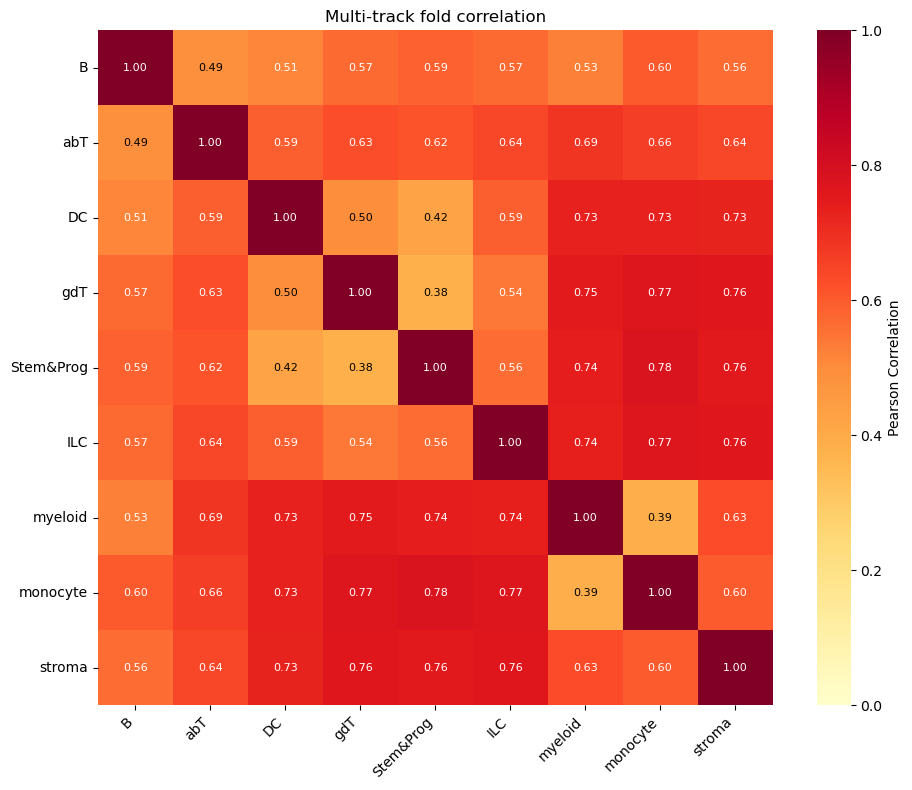

In [ ]:
# get the fold correlation for the lineage averaged data
# lineage_mask_for_fold_correlation = celltype_multi_lineage_avg_obs > np.expand_dims(np.max(test_counts, axis=1)*0.7, -1)
lineage_mask_for_fold_correlation = lineage_p_val_mask.astype(bool)
multi_track_lineage_corr = fold_correlation(celltype_multi_lineage_avg_pred, celltype_multi_lineage_avg_obs, n_celltypes=len(lineage_paths), mask_for_fold_correlation=lineage_mask_for_fold_correlation)
multi_track_lineage_corr_fig, _ = plot_correlation_matrix(multi_track_lineage_corr, celltype_names=lineage_paths.keys(), title="Multi-track fold correlation",figsize=(10,8), axis_fontsize=10, show_values=True)
multi_track_lineage_corr_fig.show()
multi_track_lineage_corr_fig.savefig('rebuttal_figs/multi_track_fold', dpi=500)



In [ ]:
lineage_mask_for_fold_correlation[:, 0].shape

(32361,)

In [ ]:
lineage_mask_for_fold_correlation[:, 0] | lineage_mask_for_fold_correlation[:, 1]

array([False, False, False, ..., False,  True,  True])

### Single track

In [ ]:


lineage_corr = np.full((n_lineage, n_lineage), np.nan)
for i, cell_i in  enumerate(lineage_paths):
    gt_i = np.load(os.path.join(lineage_paths[cell_i], 'scalar_predictions.npz'))['scalar_obs'].squeeze()
    pred_i = np.load(os.path.join(lineage_paths[cell_i], 'scalar_predictions.npz'))['scalar_pred'].squeeze()
    # i_info_filepath = f'/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/lineage_{cell_i}_complete_shallow_deprotinated_bias_quantile_normalized_4.8.25/memmap/info.txt'
    # gt_i = load_observed(i_info_filepath, dataset_type='test', data_name='total_counts').squeeze()
    # get the predicted counes 

    for j, cell_j in enumerate(lineage_paths):
        if i == j:
            lineage_corr[i,j] = 1
            continue
        # apply mask 
        
        gt_j = np.load(os.path.join(lineage_paths[cell_j], 'scalar_predictions.npz'))['scalar_obs'].squeeze()
        pred_j = np.load(os.path.join(lineage_paths[cell_j], 'scalar_predictions.npz'))['scalar_pred'].squeeze()
        mask = lineage_mask_for_fold_correlation[:, i] |  lineage_mask_for_fold_correlation[:, j] 
      

        gt_fold = np.log2(gt_i[mask] + pseudocount)- np.log2(gt_j[mask]+pseudocount)
        pred_fold = np.log2(pred_i[mask] + pseudocount) - np.log2(pred_j[mask]+pseudocount)

        # get the pearson correlation of gt_fold and pred_fold
        if len(gt_fold) < 2 or len(pred_fold) < 2:
            lineage_corr[i, j] = np.nan
        else:
            r = pearsonr(gt_fold, pred_fold)
            lineage_corr[i, j] = r[0]

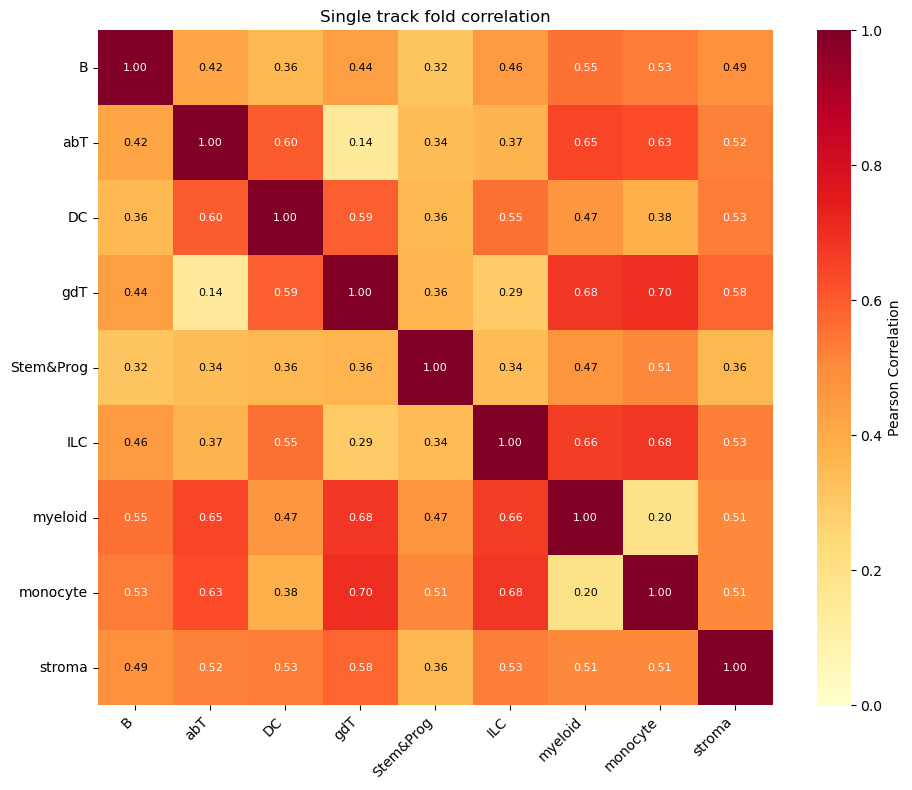

In [ ]:
single_track_fold_fig, _ = plot_correlation_matrix(lineage_corr, celltype_names=lineage_paths.keys(), title="Single track fold correlation",figsize=(10,8), axis_fontsize=10, show_values=True)
single_track_fold_fig.show()
single_track_fold_fig.savefig('rebuttal_figs/single_track_fold', dpi=500)



In [ ]:
print(lineage_corr.shape)

off_diagonal_mask = ~np.eye(9, dtype=bool)
off_diagonal_values = lineage_corr[off_diagonal_mask]

print('average including diagonal is', np.nanmean(lineage_corr))
print('average without diagonal is', np.nanmean(off_diagonal_values))

(9, 9)
average including diagonal is 0.5333618922165964
average without diagonal is 0.4750321287436709


In [ ]:
multi_track_lineage_corr

array([[1.        , 0.48859619, 0.51220718, 0.56930959, 0.58689167,
        0.56971714, 0.52540929, 0.604006  , 0.56497832],
       [0.48859619, 1.        , 0.59026808, 0.62516225, 0.61644269,
        0.64322734, 0.68715763, 0.66189145, 0.64353447],
       [0.51220718, 0.59026808, 1.        , 0.49936565, 0.42480936,
        0.59158524, 0.73096831, 0.73346888, 0.72915205],
       [0.56930959, 0.62516225, 0.49936565, 1.        , 0.38110233,
        0.54099933, 0.74713076, 0.7689533 , 0.76330951],
       [0.58689167, 0.61644269, 0.42480936, 0.38110233, 1.        ,
        0.56482204, 0.73958459, 0.77887857, 0.75576246],
       [0.56971714, 0.64322734, 0.59158524, 0.54099933, 0.56482204,
        1.        , 0.73808129, 0.7662471 , 0.76417272],
       [0.52540929, 0.68715763, 0.73096831, 0.74713076, 0.73958459,
        0.73808129, 1.        , 0.38961649, 0.63155177],
       [0.604006  , 0.66189145, 0.73346888, 0.7689533 , 0.77887857,
        0.7662471 , 0.38961649, 1.        , 0.59879109],


# Rebuttal results tables

In [56]:
# Load results and observed
celltype_multi_path = '/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/best_loss_model.pth'
celltype_multi_infofile = '/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt'
saved_file_name = 'scalar_predictions_best_loss.npz'
n_celltypes = 90
bpaitac_scalar_pred, scalar_obs = get_scalar_pred_obs_lineage(celltype_multi_path, celltype_multi_infofile, 90, saved_file_name=saved_file_name)




199
39
7
DEVICE is cuda:1
998 64 90
MODEL STRUCTURE BPcm_250(
  (body): Body(
    (net): Sequential(
      (0): Conv1d(4, 300, kernel_size=(25,), stride=(1,), padding=same)
      (1): DialatedConvs(
        (net): Sequential(
          (0): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation=(2,))
              (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU()
            )
          )
          (1): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation=(4,))
              (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU()
            )
          )
          (2): ResBlock(
            (conv_block): Sequential(
              (0): Conv1d(300, 300, kernel_size=(3,), stride=(1,), padding=same, dilation

/homes/gws/nchand/MostafaviLab/bpAITAC/load_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_path))


In [86]:
from functions import pearson_corr, spearman_corr
from sklearn.metrics import mean_squared_error
import torch
# then compute Pearson, Spearman, MSE, Pearson on ORCs
# we need pearson across and spearman across peaks 

# CELLTYPE CORR

pred_tensor = torch.tensor(bpaitac_scalar_pred)
aitac_pred_tensor = torch.tensor(aitac_preds)
obs_tensor = torch.tensor(scalar_obs)
pearson = pearson_corr(pred_tensor, obs_tensor, dim=0)
aitac_pearson = pearson_corr(aitac_pred_tensor, obs_tensor, dim=0)
spearman = spearman_corr(pred_tensor, obs_tensor, dim=0)
aitac_spearman = spearman_corr(aitac_pred_tensor, obs_tensor, dim=0)
mse = np.mean((bpaitac_scalar_pred - scalar_obs)**2, axis=0)
log_mse = np.mean((np.log2(bpaitac_scalar_pred + 1) - np.log2(scalar_obs + 1))**2, axis=0)
aitac_log_mse = np.mean((np.log2(aitac_preds + 1) - np.log2(scalar_obs + 1))**2, axis=0)
aitac_log_mse_1 = np.mean((np.log2(aitac_preds + 1) - np.log2(scalar_obs + 1))**2)
log_mse_1 = np.mean((np.log2(bpaitac_scalar_pred + 1) - np.log2(scalar_obs + 1))**2)



pearson_ocr = np.zeros((n_celltypes))
mse_ocr = np.zeros((n_celltypes))
aitac_mse_ocr = np.zeros((n_celltypes))
aitac_pearson_ocr = np.zeros((n_celltypes))
ocr_n = np.zeros((n_celltypes))
for i in range(n_celltypes):
    celltype_mask = ocr_mask[:,i]
    pearson_ocr[i] = pearson_corr(pred_tensor[:,i][celltype_mask], obs_tensor[:,i][celltype_mask], dim=0)
    aitac_pearson_ocr[i] = pearson_corr(aitac_pred_tensor[:,i][celltype_mask], obs_tensor[:,i][celltype_mask], dim=0)
    mse_ocr[i] = np.mean((np.log2(bpaitac_scalar_pred[:,i][celltype_mask]+1) - np.log2(scalar_obs[:,i][celltype_mask]+1))**2)
    aitac_mse_ocr[i] = np.mean((np.log2(aitac_preds[:,i][celltype_mask]+1) - np.log2(scalar_obs[:,i][celltype_mask]+1))**2)
    ocr_n[i] = len(pred_tensor[:,i][celltype_mask])
    print('bpaitac mse', mse_ocr[i])
    print('aitac mse', aitac_mse_ocr[i])




bpaitac mse 2.5471913814544678
aitac mse 5.197633743286133
bpaitac mse 2.596771240234375
aitac mse 5.222027778625488
bpaitac mse 2.596566915512085
aitac mse 5.727623462677002
bpaitac mse 2.8100364208221436
aitac mse 5.600666046142578
bpaitac mse 2.782400131225586
aitac mse 5.526083946228027
bpaitac mse 2.725553274154663
aitac mse 5.6821136474609375
bpaitac mse 2.355370044708252
aitac mse 4.941465854644775
bpaitac mse 2.841705083847046
aitac mse 5.98842716217041
bpaitac mse 2.150845527648926
aitac mse 4.335849761962891
bpaitac mse 2.7763161659240723
aitac mse 5.698760032653809
bpaitac mse 2.4018325805664062
aitac mse 5.044399738311768
bpaitac mse 2.517388105392456
aitac mse 5.682586193084717
bpaitac mse 2.5219833850860596
aitac mse 5.31934118270874
bpaitac mse 2.336632013320923
aitac mse 4.996224403381348
bpaitac mse 2.9562902450561523
aitac mse 5.938722610473633
bpaitac mse 1.8312023878097534
aitac mse 4.101241111755371
bpaitac mse 2.018151044845581
aitac mse 4.920720100402832
bpaitac 

Exclusive OCRs: for each celltype find the OCRS that are ONLY available in that celltype 

In [15]:
ocr_mask.sum(axis=1) == 1

array([ True, False,  True, ..., False, False, False])

In [58]:
# we could just get the correlations right then and there
single_cell_ocrs = ocr_mask.sum(axis=1) == 1
cell_type_exclusive_ocrs = {}
exclusive_pearson_ocr = np.zeros(n_celltypes)
exclusive_aitac_pearson_ocr = np.zeros(n_celltypes)
exclusive_mse_ocr = np.zeros((n_celltypes))
exclusive_aitac_mse_ocr=np.zeros(n_celltypes)

for i in range(ocr_mask.shape[1]):
    # OCRs that are: (1) available in only one cell, AND (2) that cell is this one
    exclusive_mask = single_cell_ocrs & ocr_mask[:, i]
    if np.sum(exclusive_mask) ==0:
        print('sum zero')
        # there are no such OCRs
        exclusive_pearson_ocr[i] = np.nan
        exclusive_aitac_pearson_ocr[i] = np.nan
        exclusive_mse_ocr[i] = np.nan
        exclusive_aitac_mse_ocr[i] = np.nan
    elif np.sum(exclusive_mask) ==1:
        exclusive_pearson_ocr[i] = np.nan
        exclusive_aitac_pearson_ocr[i] = np.nan
    else:
        exclusive_pearson_ocr[i] = pearson_corr(pred_tensor[:,i][exclusive_mask], obs_tensor[:,i][exclusive_mask], dim=0)
        exclusive_aitac_pearson_ocr[i] = pearson_corr(aitac_pred_tensor[:,i][exclusive_mask], obs_tensor[:,i][exclusive_mask], dim=0)
        exclusive_mse_ocr[i] = np.mean((np.log2(bpaitac_scalar_pred[:,i][exclusive_mask]+1) - np.log2(scalar_obs[:,i][exclusive_mask]+1))**2)
        exclusive_aitac_mse_ocr[i] = np.mean((np.log2(aitac_preds[:,i][exclusive_mask]+1) - np.log2(scalar_obs[:,i][exclusive_mask]+1))**2)

sum zero
sum zero
sum zero
sum zero


In [ ]:
ocr_mask.sum(axis=1)

array([ 1,  0,  1, ...,  0, 61, 83])

In [ ]:
print(aitac_preds[:,i][celltype_mask].shape)
print(bpaitac_scalar_pred[:,i][celltype_mask])

(6681,)
[ 25.780926 131.83478   12.379234 ...  42.40402  121.14917  379.224   ]


In [ ]:
print(np.mean(aitac_log_mse))
print(np.mean(log_mse))

print(np.mean(aitac_mse_ocr))
print(np.mean(mse_ocr))

print(aitac_log_mse_1)
print(log_mse_1)


2.329643
2.3817463
4.546336221694946
2.2783373501565722
2.329652
2.3817556


In [ ]:
def create_latex_longtable(cell_names, pearson, spearman, log_mse, pearson_ocr, 
                          aitac_pearson, aitac_spearman, aitac_log_mse, aitac_pearson_ocr,
                          exclusive_mse_ocr, exclusive_aitac_mse_ocr):
    """
    Create a multi-page LaTeX table using longtable package.
    """
    # Convert tensors to numpy if needed
    if hasattr(pearson, 'numpy'):
        pearson = pearson.numpy()
    if hasattr(spearman, 'numpy'):
        spearman = spearman.numpy()
    if hasattr(log_mse, 'numpy'):
        log_mse = log_mse.numpy()
    if hasattr(pearson_ocr, 'numpy'):
        pearson_ocr = pearson_ocr.numpy()
    if hasattr(aitac_pearson, 'numpy'):
        aitac_pearson = aitac_pearson.numpy()
    if hasattr(aitac_spearman, 'numpy'):
        aitac_spearman = aitac_spearman.numpy()
    
    # Calculate means
    import numpy as np
    pearson_mean = np.mean(pearson)
    spearman_mean = np.mean(spearman)
    log_mse_mean = np.mean(log_mse)
    pearson_ocr_mean = np.mean(pearson_ocr)
    aitac_pearson_mean = np.mean(aitac_pearson)
    aitac_spearman_mean = np.mean(aitac_spearman)
    aitac_log_mse_mean = np.mean(aitac_log_mse)
    aitac_pearson_ocr_mean = np.mean(aitac_pearson_ocr)
    exclusive_mse_ocr_mean = np.nanmean(exclusive_mse_ocr)
    exclusive_aitac_mse_ocr_mean = np.nanmean(exclusive_aitac_mse_ocr)
    
    # Start building the LaTeX longtable with [c] for centering - now with 6 columns
    latex_str = r"\begin{longtable}[c]{lrrrrr}" + "\n"
    
    # Caption and label
    latex_str += r"\caption{Cell type prediction metrics} \label{tab:celltype_metrics} \\" + "\n"
    latex_str += r"\hline" + "\n"
    
    # First page header
    latex_str += r"Cell Type & Pearson & Spearman & Log MSE & Pearson OCR & Excl. MSE OCR \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"\endfirsthead" + "\n\n"
    
    # Continuation pages header
    latex_str += r"\multicolumn{6}{c}{\tablename\ \thetable\ -- \textit{Continued from previous page}} \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"Cell Type & Pearson & Spearman & Log MSE & Pearson OCR & Excl. MSE OCR \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"\endhead" + "\n\n"
    
    # Footer for all pages except last
    latex_str += r"\hline" + "\n"
    latex_str += r"\multicolumn{6}{r}{\textit{Continued on next page}} \\" + "\n"
    latex_str += r"\endfoot" + "\n\n"
    
    # Footer for last page
    latex_str += r"\hline" + "\n"
    latex_str += r"\endlastfoot" + "\n\n"
    
    # Add data rows
    for i in range(len(cell_names)):
        n_ex = np.sum(single_cell_ocrs & ocr_mask[:, i])

        cell_name_escaped = str(cell_names[i]).replace('_', r'\_')
        latex_str += f"{cell_name_escaped} & "
        latex_str += f"{pearson[i]:.3f} & "
        latex_str += f"{spearman[i]:.3f} & "
        latex_str += f"{log_mse[i]:.3f} & "
        latex_str += f"{pearson_ocr[i]:.3f} & "
        latex_str += f"{exclusive_mse_ocr[i]:.3f} [{n_ex}] \\\\\n"
    
    # Add mean row
    latex_str += r"\hline" + "\n"
    latex_str += r"\textbf{Mean} & "
    latex_str += f"\\textbf{{{pearson_mean:.3f}}} & "
    latex_str += f"\\textbf{{{spearman_mean:.3f}}} & "
    latex_str += f"\\textbf{{{log_mse_mean:.3f}}} & "
    latex_str += f"\\textbf{{{pearson_ocr_mean:.3f}}} & "
    latex_str += f"\\textbf{{{exclusive_mse_ocr_mean:.3f}}} \\\\\n"

    # Add aitac mean row
    latex_str += r"\hline" + "\n"
    latex_str += r"\textbf{AI-TAC Mean} & "
    latex_str += f"\\textbf{{{aitac_pearson_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_spearman_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_log_mse_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_pearson_ocr_mean:.3f}}} & "
    latex_str += f"\\textbf{{{exclusive_aitac_mse_ocr_mean:.3f}}} \\\\\n"
    
    # Close the longtable
    latex_str += r"\end{longtable}" + "\n"
    
    # Optionally save to file
    with open('rebuttal_figs/celltype_metrics_table.tex', 'w') as f:
        f.write(latex_str)

create_latex_longtable(cell_names, pearson, spearman, mse_ocr, pearson_ocr, 
                      aitac_pearson, aitac_spearman, aitac_mse_ocr, aitac_pearson_ocr,
                      exclusive_mse_ocr, exclusive_aitac_mse_ocr)

In [88]:
def create_latex_longtable(cell_names, pearson, spearman, log_mse, pearson_ocr, 
                          aitac_pearson, aitac_spearman, aitac_log_mse, aitac_pearson_ocr,
                          exclusive_mse_ocr, exclusive_aitac_mse_ocr):
    """
    Create a multi-page LaTeX table using longtable package.
    """
    # Convert tensors to numpy if needed
    if hasattr(pearson, 'numpy'):
        pearson = pearson.numpy()
    if hasattr(spearman, 'numpy'):
        spearman = spearman.numpy()
    if hasattr(log_mse, 'numpy'):
        log_mse = log_mse.numpy()
    if hasattr(pearson_ocr, 'numpy'):
        pearson_ocr = pearson_ocr.numpy()
    if hasattr(aitac_pearson, 'numpy'):
        aitac_pearson = aitac_pearson.numpy()
    if hasattr(aitac_spearman, 'numpy'):
        aitac_spearman = aitac_spearman.numpy()
    
    # Calculate means
    import numpy as np
    pearson_mean = np.mean(pearson)
    spearman_mean = np.mean(spearman)
    log_mse_mean = np.mean(log_mse)
    pearson_ocr_mean = np.mean(pearson_ocr)
    aitac_pearson_mean = np.mean(aitac_pearson)
    aitac_spearman_mean = np.mean(aitac_spearman)
    aitac_log_mse_mean = np.mean(aitac_log_mse)
    aitac_pearson_ocr_mean = np.mean(aitac_pearson_ocr)
    
    # Start building the LaTeX longtable with [c] for centering - now with 5 columns
    latex_str = r"\begin{longtable}[c]{lrrrr}" + "\n"
    
    # Caption and label
    latex_str += r"\caption{Cell type prediction metrics} \label{tab:celltype_metrics} \\" + "\n"
    latex_str += r"\hline" + "\n"
    
    # First page header
    latex_str += r"Cell Type & Pearson R & Spearman $\rho$ & Log MSE &  Pearson R of Open Regions \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"\endfirsthead" + "\n\n"
    
    # Continuation pages header
    latex_str += r"\multicolumn{5}{c}{\tablename\ \thetable\ -- \textit{Continued from previous page}} \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"Cell Type & Pearson R & Spearman $\rho$ & Log MSE & Pearson R of Open Regions \\" + "\n"
    latex_str += r"\hline" + "\n"
    latex_str += r"\endhead" + "\n\n"
    
    # Footer for all pages except last
    latex_str += r"\hline" + "\n"
    latex_str += r"\multicolumn{5}{r}{\textit{Continued on next page}} \\" + "\n"
    latex_str += r"\endfoot" + "\n\n"
    
    # Footer for last page
    latex_str += r"\hline" + "\n"
    latex_str += r"\endlastfoot" + "\n\n"
    
    # Add data rows
    for i in range(len(cell_names)):
        cell_name_escaped = str(cell_names[i]).replace('_', r'\_')
        latex_str += f"{cell_name_escaped} & "
        latex_str += f"{pearson[i]:.3f} & "
        latex_str += f"{spearman[i]:.3f} & "
        latex_str += f"{log_mse[i]:.3f} & "
        latex_str += f"{pearson_ocr[i]:.3f} [{int(ocr_n[i])}]  \\\\\n"
    
    # Add mean row
    latex_str += r"\hline" + "\n"
    latex_str += r"\textbf{bpAI-TAC Mean} & "
    latex_str += f"\\textbf{{{pearson_mean:.3f}}} & "
    latex_str += f"\\textbf{{{spearman_mean:.3f}}} & "
    latex_str += f"\\textbf{{{log_mse_mean:.3f}}} & "
    latex_str += f"\\textbf{{{pearson_ocr_mean:.3f}}} \\\\\n"

    # Add aitac mean row
    latex_str += r"\hline" + "\n"
    latex_str += r"\textbf{AI-TAC Mean} & "
    latex_str += f"\\textbf{{{aitac_pearson_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_spearman_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_log_mse_mean:.3f}}} & "
    latex_str += f"\\textbf{{{aitac_pearson_ocr_mean:.3f}}} \\\\\n"
    
    # Close the longtable
    latex_str += r"\end{longtable}" + "\n"
    
    # Optionally save to file
    with open('rebuttal_figs/celltype_metrics_table.tex', 'w') as f:
        f.write(latex_str)

create_latex_longtable(cell_names, pearson, spearman, mse_ocr, pearson_ocr, 
                      aitac_pearson, aitac_spearman, aitac_mse_ocr, aitac_pearson_ocr,
                      exclusive_mse_ocr, exclusive_aitac_mse_ocr)

# Rebuttal open celltype stratification

In [ ]:
single_cell_ocrs


array([ True, False,  True, ..., False, False, False])

In [59]:
# Count number of cell types in which each OCR is open
n_open_per_ocr = np.sum(ocr_mask, axis=1)  # Sum across cell types for each OCR

# bpaitac_pearson = pearson_corr(bpaitac_preds_torch, obs_tensor, dim=1)
# aitac_pearson = pearson_corr(aitac_preds_torch, obs_tensor, dim=1)

def get_category_bin(n_open):
    """Convert number of open cell types to category bin (e.g., 1, 2, 3-5, 5-10, 11-20)"""
    if n_open == 0:
        return None
    elif n_open == 1:
        return 1
    elif n_open == 2:
        return 2
    elif n_open <= 5:
        return 3
    elif n_open <= 10:
        return 5
    else:
        # For 11+, bin into 11-20, 21-30, etc.
        return ((n_open - 1) // 10) * 10 + 1  # Returns 11, 21, 31, ..., 81, 91

def get_category_label(category):
    """Convert category bin to display label"""
    if category == 1:
        return "1"
    elif category == 2:
        return "2"
    elif category == 3:
        return "3-5"
    elif category == 5:
        return "5-10"
    else:
        # For 11+, create range labels like "11-20", "21-30"
        return f"{category}-{category+9}"

def corr_by_n_ocr_celltypes(pred_tensor, obs_tensor, mask):
    # Organize Pearson correlations by category
    category_pearsons = {}
    
    for ocr_idx in range(len(n_open_per_ocr)):
        n_open = n_open_per_ocr[ocr_idx]
        if n_open == 0:
            continue
        
        category = get_category_bin(n_open)
        if category not in category_pearsons:
            category_pearsons[category] = []
        
        # Get Pearson correlation for this OCR across cell types - NOT JUST OPEN
        ocr_pearson = pearson_corr(
            pred_tensor[ocr_idx, :],
            obs_tensor[ocr_idx, :],
            dim=0
        ).item()
        category_pearsons[category].append(ocr_pearson)
    
    # Convert to the format needed for create_boxplot (with string labels)
    categories_sorted = sorted(category_pearsons.keys())
    data_dict_for_plot = {
        get_category_label(cat): np.array(category_pearsons[cat]) 
        for cat in categories_sorted
    }
    
    return data_dict_for_plot

# Print summary statistics
bpaitac_data_dict_for_plot = corr_by_n_ocr_celltypes(torch.tensor(bpaitac_preds), torch.tensor(test_counts), ocr_mask)
aitac_data_dict_for_plot = corr_by_n_ocr_celltypes(torch.tensor(aitac_preds), torch.tensor(test_counts), ocr_mask)

print("\nbpAITAC Summary by category:")
for label, data in bpaitac_data_dict_for_plot.items():
    print(f"{label}: n={len(data)}, mean={np.mean(data):.3f}, median={np.median(data):.3f}")

print("\nAITAC Summary by category:")
for label, data in aitac_data_dict_for_plot.items():
    print(f"{label}: n={len(data)}, mean={np.mean(data):.3f}, median={np.median(data):.3f}")

plot_width = 0.5*9
plot_height = 2.75


bpAITAC Summary by category:
1: n=4686, mean=0.411, median=0.395
2: n=3207, mean=0.379, median=0.384
3-5: n=5811, mean=0.381, median=0.387
5-10: n=4827, mean=0.407, median=0.422
11-20: n=4457, mean=0.441, median=0.470
21-30: n=2150, mean=0.443, median=0.477
31-40: n=1434, mean=0.435, median=0.467
41-50: n=972, mean=0.415, median=0.447
51-60: n=747, mean=0.398, median=0.425
61-70: n=666, mean=0.376, median=0.418
71-80: n=646, mean=0.329, median=0.354
81-90: n=1623, mean=0.313, median=0.348

AITAC Summary by category:
1: n=4686, mean=0.319, median=0.277
2: n=3207, mean=0.264, median=0.242
3-5: n=5811, mean=0.260, median=0.250
5-10: n=4827, mean=0.283, median=0.286
11-20: n=4457, mean=0.332, median=0.339
21-30: n=2150, mean=0.341, median=0.353
31-40: n=1434, mean=0.334, median=0.354
41-50: n=972, mean=0.326, median=0.345
51-60: n=747, mean=0.307, median=0.319
61-70: n=666, mean=0.268, median=0.280
71-80: n=646, mean=0.242, median=0.245
81-90: n=1623, mean=0.184, median=0.206


fig size is (7.2, 3)
1: p-value = 6.1590e-53
2: p-value = 1.9600e-62
3-5: p-value = 5.9030e-115
5-10: p-value = 1.3459e-89
11-20: p-value = 1.3273e-55
21-30: p-value = 1.0452e-26
31-40: p-value = 7.0643e-17
41-50: p-value = 6.1144e-10
51-60: p-value = 7.3742e-09
61-70: p-value = 6.8615e-11
71-80: p-value = 1.5336e-08
81-90: p-value = 2.9049e-33


Grouped boxplot has been saved as 'grouped_boxplot.png'


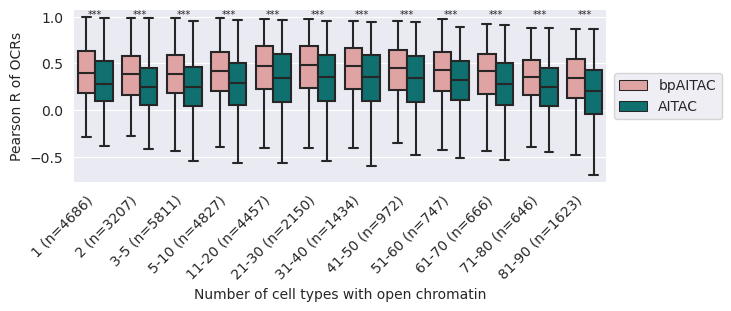

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from textwrap import wrap
import numpy as np
from scipy.stats import ranksums

def create_grouped_boxplot(data_dict1, data_dict2, label1, label2, title, xlabel, ylabel, 
                           figsize=(12, 6), output_file=None, rotate_xlabel=True, 
                           color1=None, color2=None, wrap_length=20, dark_grid=False, 
                           fliers=True, xlabel_size=None, plot_area_size=None, savepath=None,
                           show_counts=False, show_pvalues=True, pvalue_fontsize=8):
    """
    Create a grouped boxplot comparing two datasets.
    
    :param show_counts: If True, show the number of data points in brackets after each label
    :param show_pvalues: If True, show significance stars from Wilcoxon rank-sum test above each pair
    :param pvalue_fontsize: Font size for significance star annotations
    """
    
    # Set the style
    sns.set_style("white")
    plt.rcdefaults()
    
    if dark_grid:
        sns.set_style("darkgrid")
    
    # Create figure
    print('fig size is', figsize)
    plt.figure(figsize=figsize, constrained_layout=True)
    
    # Verify both dictionaries have the same keys
    assert set(data_dict1.keys()) == set(data_dict2.keys()), "Both data dictionaries must have the same categories"
    
    # Convert dictionaries to long-format DataFrame for grouped plotting
    data_list = []
    
    # Add data from first model
    for label, values in data_dict1.items():
        df = pd.DataFrame({
            'Category': label,
            'Value': values,
            'Model': label1
        })
        data_list.append(df)
    
    # Add data from second model
    for label, values in data_dict2.items():
        df = pd.DataFrame({
            'Category': label,
            'Value': values,
            'Model': label2
        })
        data_list.append(df)
    
    data_df = pd.concat(data_list, ignore_index=True)
    
    # Set colors
    if color1 and color2:
        palette = {label1: color1, label2: color2}
    elif color1:
        palette = {label1: color1, label2: sns.color_palette()[1]}
    elif color2:
        palette = {label1: sns.color_palette()[0], label2: color2}
    else:
        palette = None
    
    # Create grouped boxplot
    ax = sns.boxplot(
        data=data_df,
        x='Category',
        y='Value',
        hue='Model',
        palette=palette,
        showfliers=fliers,
    )
    
    # If plot_area_size is specified, adjust the plot area
    if plot_area_size:
        # Check if values are absolute (greater than 1) or proportional
        if plot_area_size[0] > 1 or plot_area_size[1] > 1:
            # Convert absolute sizes (inches) to proportions
            width_prop = plot_area_size[0] / figsize[0]
            height_prop = plot_area_size[1] / figsize[1]
            # Ensure proportions don't exceed 1
            width_prop = min(width_prop, 0.95)
            height_prop = min(height_prop, 0.95)
            
        # Calculate margins to justify to right-top
        # Leave 5% margin from right edge
        right_margin = 0.03
        # Calculate left margin by working backwards from right edge
        x_margin = 1 - right_margin - width_prop
        # Position at top with small margin (5% from top)
        y_margin = 0.97 - height_prop
        
        # Set the plot position [left, bottom, width, height]
        ax.set_position([x_margin, y_margin, width_prop, height_prop])
    
    # Wrap x-axis labels and optionally add counts
    labels = list(data_dict1.keys())
    
    if show_counts:
        # Add count in brackets to each label (using data_dict1 as reference since both should have same counts)
        labels_with_counts = [f"{label} (n={len(data_dict1[label])})" for label in labels]
        wrapped_labels = ['\n'.join(wrap(label, wrap_length)) for label in labels_with_counts]
    else:
        wrapped_labels = ['\n'.join(wrap(label, wrap_length)) for label in labels]

    # Calculate p-values for each group using signed Wilcoxon rank-sum test
    if show_pvalues:
        pvalues = []
        for label in labels:
            stat, pval = ranksums(data_dict1[label], data_dict2[label])
            pvalues.append(pval)
            print(f"{label}: p-value = {pval:.4e}")
        
        # Get current y-axis limits
        y_limits = ax.get_ylim()
        y_range = y_limits[1] - y_limits[0]
        # Position stars just below the top of the y-axis (3% down from the top)
        star_y_position = y_limits[1] - y_range * 0.03
        
        for i, (label, pval) in enumerate(zip(labels, pvalues)):
            # Determine significance level and assign stars
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            else:
                stars = 'n.s.'
            
            # Position stars at fixed y position (just below top of axis)
            ax.text(i, star_y_position, stars, 
                   ha='center', va='center', fontsize=pvalue_fontsize)
    
    # Get current tick positions and set wrapped labels
    tick_positions = range(len(labels))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(wrapped_labels, linespacing=0.8)
    
    if rotate_xlabel:
        ax.set_xticklabels(wrapped_labels, rotation=45, ha='right', size=xlabel_size)
    else:
        ax.set_xticklabels(wrapped_labels, ha='center', size=xlabel_size)
    
    # Customize plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Remove grid lines
    
    # Make axis lines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Position legend
    ax.legend(title='', frameon=True, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Save the plot if output_file is provided
    if output_file:
        plt.savefig(output_file, dpi=330, bbox_inches='tight')
        print(f"Grouped boxplot has been saved as '{output_file}'")
    
    
    if savepath is not None:
        plt.savefig(savepath, dpi=400, bbox_inches='tight')
    plt.show()
    plt.close()
    
# Example usage with show_counts=True and p-values
create_grouped_boxplot(
    data_dict1=bpaitac_data_dict_for_plot,
    data_dict2=aitac_data_dict_for_plot,
    label1='bpAITAC',
    label2='AITAC',
    title='',
    xlabel='Number of cell types with open chromatin',
    ylabel='Pearson R of OCRs',
    figsize=(9*0.8, 3),
    output_file='grouped_boxplot.png',
    rotate_xlabel=True,
    color1='#EA9999',
    color2='teal',
    dark_grid=True,
    fliers=False,
    xlabel_size=10,
    savepath='rebuttal_figs/S1c_2_corr_grouped_open_celltype_aitac_bpaitac_pval',
    show_counts=True,
    show_pvalues=True,
    pvalue_fontsize=7
)


# Divide by GC content

In [ ]:
test_onehot.shape

(32361, 4, 998)


Overall GC content: mean=0.484, median=0.476
GC content range: 0.273 to 0.814

GC content quartile boundaries:
Q1 (25th percentile): 0.436 (43.6%)
Q2 (50th percentile): 0.476 (47.6%)
Q3 (75th percentile): 0.522 (52.2%)

Summary by GC content quartiles (ALL peaks):
Q1: < 43.6%: n=8070, mean=0.433, median=0.448
Q2: 43.6-47.6%: n=7895, mean=0.403, median=0.411
Q3: 47.6-52.2%: n=8244, mean=0.385, median=0.389
Q4: ≥ 52.2%: n=8152, mean=0.341, median=0.350
fig size is (2.8, 2.75)

Wilcoxon rank-sum test between Q1: < 43.6% and Q2: 43.6-47.6%:
  p-value = 1.9632e-10
 N 8070

Wilcoxon rank-sum test between Q2: 43.6-47.6% and Q3: 47.6-52.2%:
  p-value = 7.4933e-05
 N 7895

Wilcoxon rank-sum test between Q3: 47.6-52.2% and Q4: ≥ 52.2%:
  p-value = 6.6777e-22
 N 8244
Boxplot has been saved as 'rebuttal_figs/S2a_ocr_pearson_by_gc_content_quartiles.png'


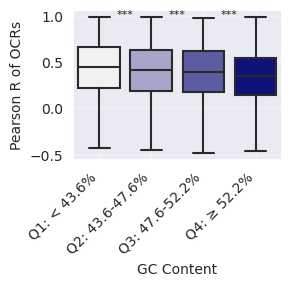

In [93]:
onehot_sequences = test_onehot.transpose(0, 2, 1)
bases = ['A', 'C', 'G', 'T'] # from /data/nchand/mm10/mm10ImmGenATAC1219.peak_matched1000bp_onehot-ACGT_alignleft.npz


def calculate_gc_content(onehot_seq):
    """
    Calculate GC content from one-hot encoded sequence.
    onehot_seq shape: (sequence_length, 4) where channels are [A, C, G, T]
    Returns: GC content as a fraction between 0 and 1
    """
    # Sum of G (index 2) and C (index 1) across sequence length
    gc_count = np.sum(onehot_seq[:, 1]) + np.sum(onehot_seq[:, 2])  # C + G
    total_count = np.sum(onehot_seq)  # Total nucleotides
    return gc_count / total_count if total_count > 0 else 0

# Calculate GC content for all OCRs
# Assuming onehot_sequences shape is (n_ocrs, sequence_length, 4)
gc_contents = np.array([calculate_gc_content(onehot_sequences[i]) for i in range(len(onehot_sequences))])

# Print overall GC content distribution
print(f"\nOverall GC content: mean={np.mean(gc_contents):.3f}, median={np.median(gc_contents):.3f}")
print(f"GC content range: {np.min(gc_contents):.3f} to {np.max(gc_contents):.3f}")

# Calculate quartile boundaries
q25, q50, q75 = np.percentile(gc_contents, [25, 50, 75])
print(f"\nGC content quartile boundaries:")
print(f"Q1 (25th percentile): {q25:.3f} ({q25*100:.1f}%)")
print(f"Q2 (50th percentile): {q50:.3f} ({q50*100:.1f}%)")
print(f"Q3 (75th percentile): {q75:.3f} ({q75*100:.1f}%)")

# Create quartile-based bins
def get_gc_quartile_bin(gc_content, q25, q50, q75):
    """Assign GC content to quartile bin"""
    if gc_content < q25:
        return f"Q1: < {q25*100:.1f}%"
    elif gc_content < q50:
        return f"Q2: {q25*100:.1f}-{q50*100:.1f}%"
    elif gc_content < q75:
        return f"Q3: {q50*100:.1f}-{q75*100:.1f}%"
    else:
        return f"Q4: ≥ {q75*100:.1f}%"

# Organize Pearson correlations by GC content quartile
gc_pearsons_all = {}
for ocr_idx in range(len(gc_contents)):
    gc_bin = get_gc_quartile_bin(gc_contents[ocr_idx], q25, q50, q75)
    
    if gc_bin not in gc_pearsons_all:
        gc_pearsons_all[gc_bin] = []
    
    # Get Pearson correlation for this OCR across ALL cell types (no masking)
    ocr_pearson = pearson_corr(
        pred_tensor[ocr_idx, :],  # All cell types
        obs_tensor[ocr_idx, :],   # All cell types
        dim=0
    ).item()
    gc_pearsons_all[gc_bin].append(ocr_pearson)

# Create ordered dict for plotting
bin_order = [f"Q1: < {q25*100:.1f}%", f"Q2: {q25*100:.1f}-{q50*100:.1f}%", 
             f"Q3: {q50*100:.1f}-{q75*100:.1f}%", f"Q4: ≥ {q75*100:.1f}%"]
data_dict_gc_all = {label: np.array(gc_pearsons_all[label]) 
                    for label in bin_order if label in gc_pearsons_all}

# Print summary statistics
print("\nSummary by GC content quartiles (ALL peaks):")
for label, data in data_dict_gc_all.items():
    print(f"{label}: n={len(data)}, mean={np.mean(data):.3f}, median={np.median(data):.3f}")

data_dict_gc = data_dict_gc_all

# Create boxplot
create_boxplot(
    data_dict=data_dict_gc,
    title='',
    xlabel='GC Content',
    ylabel='Pearson R of OCRs',
    figsize=(4*0.7, 2.75),
    output_file='rebuttal_figs/S2a_ocr_pearson_by_gc_content_quartiles.png',
    rotate_xlabel=True,  
    color='darkblue',
    wrap_length=20,
    dark_grid=True,
    fliers=False,
    xlabel_size=10,
    show_counts=False,
    show_pvalue_all=True,
    paired_test=False
)

# Stratify by sequence repetition

In [95]:
import numpy as np
from collections import Counter

k=4

def calculate_kmer_entropy_batch(sequences, k=6):
    """
    Calculate Shannon entropy based on k-mer frequencies for multiple sequences.
    Vectorized implementation for speed.
    
    Lower entropy = more repetitive sequence.
    For random DNA, expect entropy ~11-12 for k=6.
    For repetitive DNA, expect entropy <8.
    
    Args:
        sequences: list or array of DNA sequence strings (all same length)
        k: k-mer length (default 6)
    
    Returns:
        numpy array of entropy values, one per sequence
    """
    n_sequences = len(sequences)
    entropies = np.zeros(n_sequences)
    
    # Convert sequences to uppercase once
    sequences = [seq.upper() for seq in sequences]
    
    # Process in batches for memory efficiency
    batch_size = 10000
    for batch_start in range(0, n_sequences, batch_size):
        batch_end = min(batch_start + batch_size, n_sequences)
        batch_seqs = sequences[batch_start:batch_end]
        
        for i, seq in enumerate(batch_seqs):
            # Extract all k-mers
            kmers = [seq[j:j+k] for j in range(len(seq) - k + 1)]
            
            # Count k-mer frequencies
            kmer_counts = Counter(kmers)
            total = len(kmers)
            
            # Calculate Shannon entropy
            entropy = 0
            for count in kmer_counts.values():
                p = count / total
                entropy -= p * np.log2(p)
            
            entropies[batch_start + i] = entropy
    
    return entropies


# Convert one-hot sequences back to DNA strings
def onehot_to_sequence(onehot_seq):
    """
    Convert one-hot encoded sequence to DNA string.
    Assumes channels are [A, C, G, T]
    """
    nucleotides = ['A', 'C', 'G', 'T']
    seq_indices = np.argmax(onehot_seq, axis=-1)
    return ''.join([nucleotides[i] for i in seq_indices])

# Convert all sequences
print("Converting one-hot sequences to DNA strings...")
# just get the middle 250 bp
onehot_sequences_middle = onehot_sequences[:, 375:625,:]
dna_sequences = [onehot_to_sequence(onehot_sequences_middle[i]) for i in range(len(onehot_sequences_middle))]


# Calculate k-mer entropy for all sequences
print("Calculating k-mer entropy...")
kmer_entropies = calculate_kmer_entropy_batch(dna_sequences, k=k)

print(f"\nK-mer entropy statistics:")
print(f"Mean: {np.mean(kmer_entropies):.3f}")
print(f"Median: {np.median(kmer_entropies):.3f}")
print(f"Range: {np.min(kmer_entropies):.3f} to {np.max(kmer_entropies):.3f}")

# Calculate quartile boundaries
q25, q50, q75 = np.percentile(kmer_entropies, [25, 50, 75])
print(f"\nQuartile boundaries:")
print(f"Q1 (25th percentile): {q25:.3f}")
print(f"Q2 (50th percentile): {q50:.3f}")
print(f"Q3 (75th percentile): {q75:.3f}")

# Create quartile-based bins
def get_entropy_quartile_bin(entropy, q25, q50, q75):
    """Assign entropy to quartile bin"""
    if entropy < q25:
        return f"Q1: < {q25:.2f}"
    elif entropy < q50:
        return f"Q2: {q25:.2f}-{q50:.2f}"
    elif entropy < q75:
        return f"Q3: {q50:.2f}-{q75:.2f}"
    else:
        return f"Q4: ≥ {q75:.2f}"

# Organize Pearson correlations by entropy quartile - ALL PEAKS
entropy_pearsons_all = {}
for ocr_idx in range(len(kmer_entropies)):
    bin_label = get_entropy_quartile_bin(kmer_entropies[ocr_idx], q25, q50, q75)
    
    if bin_label not in entropy_pearsons_all:
        entropy_pearsons_all[bin_label] = []
    
    # Get Pearson correlation for this OCR across ALL cell types
    ocr_pearson = pearson_corr(
        pred_tensor[ocr_idx, :],
        obs_tensor[ocr_idx, :],
        dim=0
    ).item()
    entropy_pearsons_all[bin_label].append(ocr_pearson)

# Create ordered dict for plotting
bin_order = [f"Q1: < {q25:.2f}", f"Q2: {q25:.2f}-{q50:.2f}", 
             f"Q3: {q50:.2f}-{q75:.2f}", f"Q4: ≥ {q75:.2f}"]
data_dict_entropy_all = {label: np.array(entropy_pearsons_all[label]) 
                         for label in bin_order if label in entropy_pearsons_all}

# Print summary statistics
print("\nSummary by k-mer entropy quartiles (ALL peaks):")
for label, data in data_dict_entropy_all.items():
    print(f"{label}: n={len(data)}, mean={np.mean(data):.3f}, median={np.median(data):.3f}")

Converting one-hot sequences to DNA strings...
Calculating k-mer entropy...

K-mer entropy statistics:
Mean: 6.873
Median: 6.909
Range: 2.957 to 7.274

Quartile boundaries:
Q1 (25th percentile): 6.806
Q2 (50th percentile): 6.909
Q3 (75th percentile): 6.988

Summary by k-mer entropy quartiles (ALL peaks):
Q1: < 6.81: n=8090, mean=0.385, median=0.391
Q2: 6.81-6.91: n=8088, mean=0.402, median=0.409
Q3: 6.91-6.99: n=8091, mean=0.397, median=0.405
Q4: ≥ 6.99: n=8092, mean=0.378, median=0.374


fig size is (2.8, 2.75)

Wilcoxon rank-sum test between Q1: < 6.81 and Q2: 6.81-6.91:
  p-value = 2.1437e-04
 N 8090

Wilcoxon rank-sum test between Q2: 6.81-6.91 and Q3: 6.91-6.99:
  p-value = 3.0961e-01
 N 8088

Wilcoxon rank-sum test between Q3: 6.91-6.99 and Q4: ≥ 6.99:
  p-value = 7.3482e-06
 N 8091
Boxplot has been saved as 'rebuttal_figs/S2b_ocr_pearson_by_kmer_entropy_all_peaks.png'


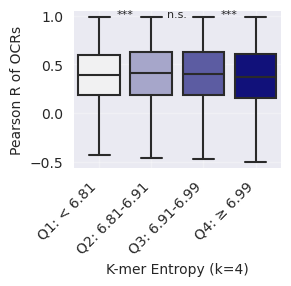

In [99]:
# Create boxplot
create_boxplot(
    data_dict=data_dict_entropy_all,
    title='',
    xlabel=f'K-mer Entropy (k={k})',
    ylabel='Pearson R of OCRs',
    figsize=(4*0.7, 2.75),
    output_file='rebuttal_figs/S2b_ocr_pearson_by_kmer_entropy_all_peaks.png',
    rotate_xlabel=True,
    color='darkblue',
    wrap_length=20,
    dark_grid=True,
    fliers=False,
    xlabel_size=10,
    paired_test=False,
    show_pvalue_all=True
)

# Figure 3 d

Comparing predictions for specific motifs

### Load the data

In [ ]:
from utils import load_observed
from utils import load_names
import numpy as np

info_file = '/data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/info.txt'
peak_names = load_names(info_file, dataset_type='test')
cell_names = np.load("/data/nchand/ImmGen/mouse/BPprofiles1000/ImmGenATAC1219.peak_matched_in_sorted.sl10004sh-4.celltypes.npy")
lineage_filepath = 'immgen_lineages.csv'

test_onehot = load_observed(info_file, dataset_type='test', data_name='onehot')
test_onehot = test_onehot.transpose((0, 2, 1))
test_bias = load_observed(info_file, dataset_type='test', data_name='bias')
test_counts = load_observed(info_file, dataset_type='test', data_name='total_counts')
test_bpcounts = load_observed(info_file, dataset_type='test', data_name='bp_counts')
print(test_counts.shape)

file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.names.dat
shape (32361,)
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.onehot.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bias.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.total_counts.dat
file name /data/nchand/ImmGen/mouse/BPprofiles1000/memmaped/complete_shallow_deprotinated_bias_quantile_normalized_4.1.25/memmap/test.bp_counts.dat
(32361, 90)


In [ ]:
from eval_model import get_model_structure
from load_model import load_model
from region_identification_utils import get_lineage_cells
from region_identification_utils import get_lineage_counts
from load_model import DEVICE
from modules import AverageWrapper

# Load the models 
aitac_dir = '/data/nchand/analysis/BPcm_250/BP200_L0_0/'
path_aitac = '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.04/best_model'
bpaitac_dir = '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/'
path_bpaitac = '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.18.35/best_model'

n_celltypes = 90
n_filters = 300
seq_len = 998
model_type = 'BPcm_250'

aitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)
bpaitac_structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)

model_aitac = load_model(path_aitac, model_structure=aitac_structure, n_filters=n_filters, verbose=False)
model_bpaitac = load_model(path_bpaitac, model_structure=bpaitac_structure, n_filters=n_filters, verbose=False)

n_lineages = 10
lineage_names, lineage_cell_indices = get_lineage_cells(lineage_filepath, cell_names=cell_names)
lineage_model_aitac = AverageWrapper(model_aitac, lineage_cell_indices)
lineage_model_bpaitac = AverageWrapper(model_bpaitac, lineage_cell_indices)





199
39
7
199
39
7
DEVICE is cuda:0
998 300 90
DEVICE is cuda:0
998 300 90


/homes/gws/nchand/MostafaviLab/bpAITAC/load_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_path))


### Set up the models

Load all of the trials of each model

In [ ]:
def make_model_list(model_paths, lineage_cell_indices):
    lineage_models = []
    for path in model_paths:
        structure = get_model_structure(model_type, n_filters, n_celltypes, seq_len=seq_len)
        model = load_model(path, model_structure=structure, n_filters=n_filters, verbose=False)
        lineage_model = AverageWrapper(model, lineage_cell_indices)
        lineage_models.append(lineage_model)
    return lineage_models

aitac_paths = ['/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.03/best_model', 
               '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.04/best_model', 
               '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.15.05/best_model', 
               '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-08-2025.22.30/best_model', 
               '/data/nchand/analysis/BPcm_250/BP200_L0_0/complete/04-09-2025.04.28/best_model']
bpaitac_paths = ['/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.08.00/best_model', 
                 '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.18.20/best_model', 
                 '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.18.35/best_model', 
                 '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-06-2025.18.37/best_model', 
                 '/data/nchand/analysis/BPcm_250/BP203_no_seed_L-1_5/complete/04-04-2025.10.43/best_model']

aitac_lineage_model_list = make_model_list(aitac_paths, lineage_cell_indices)
bpaitac_lineage_model_list = make_model_list(bpaitac_paths, lineage_cell_indices)

199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90


/homes/gws/nchand/MostafaviLab/bpAITAC/load_model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_path))


199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90
199
39
7
DEVICE is cuda:0
998 300 90


### find the regions with a the test sequences that have the motifs in them

In [ ]:
from tangermeme.io import read_meme

# motifs 

motif_dict = {
    'REL':"GGGAATTTCCC",
    'RUNX':"TCTGTGGTTT",
    'ETV2':"ACCGGAAAT",
    'FLI1':"ACAGGAAGTGG",
    'POU2F2':"ATTTGCAT",
    'SPIC':"AAAAGAGGAAGTA",
    'SPIB':"TCACTTCCTCTTT",
    'MOTIF_665':"TTCACTTCCCC",
    'MOTIF_980':"GCAAC",
    'no_motif':"",
    'ERF':"ACCGGAAGT"
}

marginalization_motif_dict = {
    'POU2F2':"ATTTGCAT",
    'REL':"GGGAATTTCCC",
    'RUNX':"TCTGTGGTTT",
    'SPIB':"TCACTTCCTCTTT",
    'ERF':"ACCGGAAGT",
    'no_motif':""
}

motif_num_dict = { # UPDATED 6/7/25
    'REL': '1405 ',
    'FLI1': '1222 ',
    'MOTIF_1153':'1153 ',
}

motif_pwms = read_meme("final_figs/motif_pwms_6.7.25.meme")

bases = ['A', 'C', 'G', 'T'] # from /data/nchand/mm10/mm10ImmGenATAC1219.peak_matched1000bp_onehot-ACGT_alignleft.npz

In [ ]:
motif_pwm_dict = {motif_name: motif_pwms[motif_num_dict[motif_name]] for motif_name in motif_num_dict.keys()}


In [ ]:
motif_pwm_dict['REL'].shape

torch.Size([4, 8])

In [ ]:
from utils import predict_scalar
import torch
def get_averaged_scalar_predictions(model_list, x, n_tracks):
    model_preds_sum = torch.zeros((len(x), n_tracks)).to(DEVICE)
    for model in model_list:
        model_preds = predict_scalar(model, x, n_celltypes=n_lineages, device=DEVICE)
        model_preds_sum = model_preds_sum + model_preds
    return model_preds_sum / len(model_list)

In [25]:
from utils import predict_scalar
import torch

def get_motif_specific_predictions_and_observed(lineage_model1, lineage_model2, motif_name_list, 
                                                motif_hit_idx_dict,
                                                test_onehot, test_counts, 
                                                lineage_cell_indices, n_lineages, count_threshold=0):
    results_dict = {}
    for motif_name in motif_name_list:
        motif_hit_idx = motif_hit_idx_dict[motif_name]
        onehot_with_motif = test_onehot[motif_hit_idx]
        observed_counts_with_motif = test_counts[motif_hit_idx]

        if count_threshold > 0:
            threshold_idx = np.argwhere(np.max(observed_counts_with_motif, axis=1) > count_threshold).flatten()
            print('threshold mask', threshold_idx.shape)
            observed_counts_with_motif = observed_counts_with_motif[threshold_idx]
            onehot_with_motif = onehot_with_motif[threshold_idx]
            print()

        observed_counts_with_motif_lineage = get_lineage_counts(lineage_cell_indices, observed_counts_with_motif) # get the lineage counts
        if type(lineage_model1) is list:
            model_1_preds = get_averaged_scalar_predictions(lineage_model1, onehot_with_motif, n_tracks=n_lineages)
            model_2_preds = predict_scalar(lineage_model2, onehot_with_motif, n_tracks=n_lineages)
        else:
            model_1_preds = predict_scalar(lineage_model1, onehot_with_motif, n_celltypes=n_lineages, device=DEVICE)
            model_2_preds = predict_scalar(lineage_model2, onehot_with_motif, n_celltypes=n_lineages, device=DEVICE)
        
        assert not torch.allclose(model_1_preds, model_2_preds), f"Model 1 and Model 2 predictions are identical: {model_1_preds} and {model_2_preds}"
    
        results_dict[motif_name] = {'aitac_counts': model_1_preds.cpu().numpy(),
                            'bpaitac_counts': model_2_preds.cpu().numpy(),
                            'observed_counts': observed_counts_with_motif_lineage}

    return results_dict

In [ ]:
from tangermeme.tools.fimo import fimo
def get_counts_for_multiple_motifs(lineage_model_aitac, lineage_model_bpaitac, motif_name_list,
                                                motif_num_dict, motif_pwms, test_onehot, test_counts, 
                                                lineage_cell_indices, n_lineages, count_threshold, p_threshold=0.0001):
    

    selected_motif_pwms = {key: motif_pwms[key] for key in motif_num_dict.values()}
    threshold=p_threshold
    hits = fimo(selected_motif_pwms, test_onehot, threshold=threshold)

    motif_hit_idx ={}
    for i, motif_name in enumerate(motif_name_list):
        if motif_name == 'all':
            print(motif_name, 'len', len(test_onehot))
            motif_hit_idx[motif_name] = range(len(test_onehot))
        else:
            print(motif_name, 'len', len(hits[i]))
            motif_hit_idx[motif_name] = hits[i]['sequence_name']

    results_dict = get_motif_specific_predictions_and_observed(lineage_model1=lineage_model_aitac, lineage_model2=lineage_model_bpaitac, 
                                                motif_name_list=motif_name_list, motif_hit_idx_dict=motif_hit_idx, test_onehot=test_onehot, test_counts=test_counts, 
                                                lineage_cell_indices=lineage_cell_indices, n_lineages=n_lineages,
                                                count_threshold=count_threshold)
    return results_dict
    

In [ ]:
# motif_list = ['REL', 'RUNX', 'ETV2', 'MOTIF_291', 'MOTIF_540', 'MOTIF_1816', 'all']
# motif_list = ['REL', 'RUNX', 'ETV2', 'MOTIF_291', 'all']
motif_list = ['POU2F2', 'REL', 'RUNX', 'SPIB', 'all']



count_threshold=0
p_threshold=0.00008


# pred_observed_motif_dict = get_counts_for_multiple_motifs(aitac_lineage_model_list, bpaitac_lineage_model_list, 
#                                                           motif_name_list=motif_list, 
#                                                           motif_num_dict=motif_num_dict,
#                                                           motif_pwms=motif_pwms,
#                                                           test_onehot=test_onehot,
#                                                           test_counts=test_counts,
#                                                           lineage_cell_indices=lineage_cell_indices,
#                                                           n_lineages=n_lineages,
#                                                           count_threshold=count_threshold,
#                                                           p_threshold=p_threshold)


In [ ]:
pred_observed_motif_dict['REL']['aitac_counts']
pred_observed_motif_dict['REL']['observed_counts']

NameError: name 'pred_observed_motif_dict' is not defined

### Plot the results for the desired all 10 cell lineages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def create_stacked_comparison_boxplots(predictions_list, cellnames, motif_names,
                                     figsize=(15, 6), show_outliers=True, show_zero_line=False, predictions_names_list=None):
    """
    Create multiple boxplots stacked vertically comparing predictions between models and observed values.
    
    Parameters:
    -----------
    predictions_list : list of tuples
        List of (preds_model1, preds_model2) tuples for each motif/feature
        or List of (preds_model1, preds_model2, observed) tuples for each motif/feature
    cellnames : list
        List of cell type names
    motif_names : list
        List of motif/feature names
    figsize : tuple, optional
        Base figure size that will be adjusted based on number of plots
    show_outliers : bool, optional
        Whether to show outliers in the boxplots
    show_zero_line : bool, optional
        Whether to display a horizontal dashed line at y=0
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure containing all subplots
    """

    
    num_plots = len(predictions_list)
    
    # Adjust figure height based on number of plots
    adjusted_figsize = (figsize[0], figsize[1] * num_plots)
    
    # Create figure and subplots
    fig, axes = plt.subplots(num_plots, 1, figsize=adjusted_figsize)
    if num_plots == 1:
        axes = [axes]
    
    # For each motif/feature
    for idx, (predictions, motif_name, ax) in enumerate(zip(predictions_list, motif_names, axes)):
        data_list = []
        
        # Check if we have observed values (3 elements in the tuple)
        has_observed = len(predictions) == 3
        
        preds_model1 = predictions[0]
        preds_model2 = predictions[1]
        observed = predictions[2] if has_observed else None
        
        # Define model names
        if predictions_names_list is None:
            model_names = ['AI-TAC', 'bpAI-TAC', 'Observed'] if has_observed else ['AI-TAC', 'bpAI-TAC']
        else:
            model_names = predictions_names_list
        model_colors = ['lightblue', 'orange', 'green'] if has_observed else ['lightblue', 'orange']
        
        # For each celltype
        for i in range(len(cellnames)):
            # Add data for model1
            data_list.extend([{
                'Celltype': f'{cellnames[i]}',
                'Model': model_names[0],
                'Prediction': val
            } for val in preds_model1[:, i]])
            
            # Add data for model2
            data_list.extend([{
                'Celltype': f'{cellnames[i]}',
                'Model': model_names[1],
                'Prediction': val
            } for val in preds_model2[:, i]])
            
            # Add observed data if available
            if has_observed:
                data_list.extend([{
                    'Celltype': f'{cellnames[i]}',
                    'Model': model_names[2],
                    'Prediction': val
                } for val in observed[:, i]])
        
        df = pd.DataFrame(data_list)
        print('df', df)
        
        # Create boxplot on current subplot
        sns.boxplot(data=df, x='Celltype', y='Prediction',
                   hue='Model', palette=model_colors,
                   showfliers=show_outliers, ax=ax)
        
        # Add horizontal line at y=0 if requested
        if show_zero_line:
            ax.axhline(y=0, color='black', alpha=0.3, linestyle='--')
        
        # Customize the subplot
        ax.set_xlabel('Cell Type' if idx == num_plots-1 else '')
        ax.set_ylabel(motif_name)

        if idx == num_plots-1 :
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        else:
            ax.set_xticklabels([])

        # Keep legend only for the first plot and adjust its position
        if idx == 0:
            ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.get_legend().remove()
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig

In [ ]:

# Create the predictions list for plotting
# predictions_list = [
#     (p0_diff[motif], p5_diff[motif])
#     for motif in motifs
# ]
# plot_motif_names_list = ['REL', 'RUNX', 'ETV2', 'MOTIF_291', 'all']
plot_motif_names_list = ['REL', 'RUNX', 'ETV2', 'all']


filename_end = '_4.23'

diff_list = [
    (pred_observed_motif_dict[motif]['aitac_counts'] - pred_observed_motif_dict[motif]['observed_counts'], 
     pred_observed_motif_dict[motif]['bpaitac_counts'] - pred_observed_motif_dict[motif]['observed_counts']
    ) for motif in plot_motif_names_list
]

abs_diff_list = [
    (np.abs(pred_observed_motif_dict[motif]['aitac_counts'] - pred_observed_motif_dict[motif]['observed_counts']), 
     np.abs(pred_observed_motif_dict[motif]['bpaitac_counts'] - pred_observed_motif_dict[motif]['observed_counts'])
    ) for motif in plot_motif_names_list
]

predictions_list = [
    (pred_observed_motif_dict[motif]['aitac_counts'], 
     pred_observed_motif_dict[motif]['bpaitac_counts'],
     pred_observed_motif_dict[motif]['observed_counts']) for motif in plot_motif_names_list
]


# Create the plot
fig = create_stacked_comparison_boxplots(
    predictions_list=diff_list,
    cellnames=lineage_names,  # Your list of cell type names
    motif_names=plot_motif_names_list,   # Your list of motif names
    figsize=(12, 2),
    show_outliers=False
)

fig.show()

fig.savefig(f'final_figs/3c_motif_seqs_observed{filename_end}.png', bbox_inches='tight', dpi=330)


Let's try plotting the motifs inserted into shuffled sequences

In [ ]:
from tangermeme.ersatz import dinucleotide_shuffle
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import substitute

seed = 42
np.random.seed(seed)
n_random_samples = 4000 # grab a random 1000 sequences to do analysis with
random_indices = np.random.choice(len(test_onehot), size=n_random_samples, replace=False)
selected_seqs = test_onehot[random_indices]

# move our onehot_sequences to be in the shape expected by tangermeme
selected_onehot_tangermeme_format = torch.from_numpy(selected_seqs)
print('onehot tangermeme format shape', selected_onehot_tangermeme_format.shape)
onehot_shuf = dinucleotide_shuffle(selected_onehot_tangermeme_format, n=1, random_state=seed)
onehot_shuf = torch.squeeze(onehot_shuf)


onehot tangermeme format shape torch.Size([4000, 4, 998])


In [ ]:
def get_marginalized_predictions(lineage_model1, lineage_model2, onehot_shuf, motif_dict):
    results_dict = {}
    # Generate predictions for each motif
    for motif_name, motif in motif_dict.items():
        print(motif_name, motif)
        if type(motif) is not str:
            motif = torch.unsqueeze(motif, dim=0)
        if len(motif) == 0:
            x = onehot_shuf
        else:
            onehot_with_motif = substitute(onehot_shuf, motif=motif)
            x = onehot_with_motif
        if type(lineage_model1) is list:
            model_1_preds = get_averaged_scalar_predictions(lineage_model1, x, n_tracks=n_lineages)
            model_2_preds = get_averaged_scalar_predictions(lineage_model2, x, n_tracks=n_lineages)
        else:
            model_1_preds = predict_scalar(lineage_model1, x, n_celltypes=n_lineages, device=DEVICE)
            model_2_preds = predict_scalar(lineage_model2, x, n_celltypes=n_lineages, device=DEVICE)
        
        assert not torch.allclose(model_1_preds, model_2_preds), f"Model 1 and Model 2 predictions are identical: {model_1_preds} and {model_2_preds}"

        results_dict[motif_name] = {'aitac_counts': model_1_preds.cpu().numpy(),
                            'bpaitac_counts': model_2_preds.cpu().numpy(),
                            }
    return results_dict


In [ ]:
# marginalized_results = get_marginalized_predictions(lineage_model_aitac, lineage_model_bpaitac,onehot_shuf,
#                                                     motif_dict)

marginalized_results = get_marginalized_predictions(aitac_lineage_model_list, bpaitac_lineage_model_list,onehot_shuf,
                                                    marginalization_motif_dict)



POU2F2 ATTTGCAT


100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 14.73it/s]


REL GGGAATTTCCC


100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 14.38it/s]


RUNX TCTGTGGTTT


...

100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 13.58it/s]


ERF ACCGGAAGT


100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 14.35it/s]


no_motif 


100%|█████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 13.89it/s]


df         Celltype     Model  Prediction
0      Stem&Prog    AI-TAC   17.191576
1      Stem&Prog    AI-TAC    0.677390
2      Stem&Prog    AI-TAC   -3.080841
3      Stem&Prog    AI-TAC   -5.649792
4      Stem&Prog    AI-TAC    0.858257
...          ...       ...         ...
79995     stroma  bpAI-TAC   -1.255263
79996     stroma  bpAI-TAC   -1.245595
79997     stroma  bpAI-TAC   -1.398741
79998     stroma  bpAI-TAC   -8.743856
79999     stroma  bpAI-TAC   -3.592803

[80000 rows x 3 columns]
df         Celltype     Model  Prediction
0      Stem&Prog    AI-TAC   18.944021
1      Stem&Prog    AI-TAC    0.355455
2      Stem&Prog    AI-TAC   14.086353
3      Stem&Prog    AI-TAC    2.980595
4      Stem&Prog    AI-TAC    1.520567
...          ...       ...         ...
79995     stroma  bpAI-TAC   -0.416402
79996     stroma  bpAI-TAC    5.473444
79997     stroma  bpAI-TAC    0.886870
79998     stroma  bpAI-TAC   -5.753046
79999     stroma  bpAI-TAC   -2.115031

[80000 rows x 3 columns]
df    

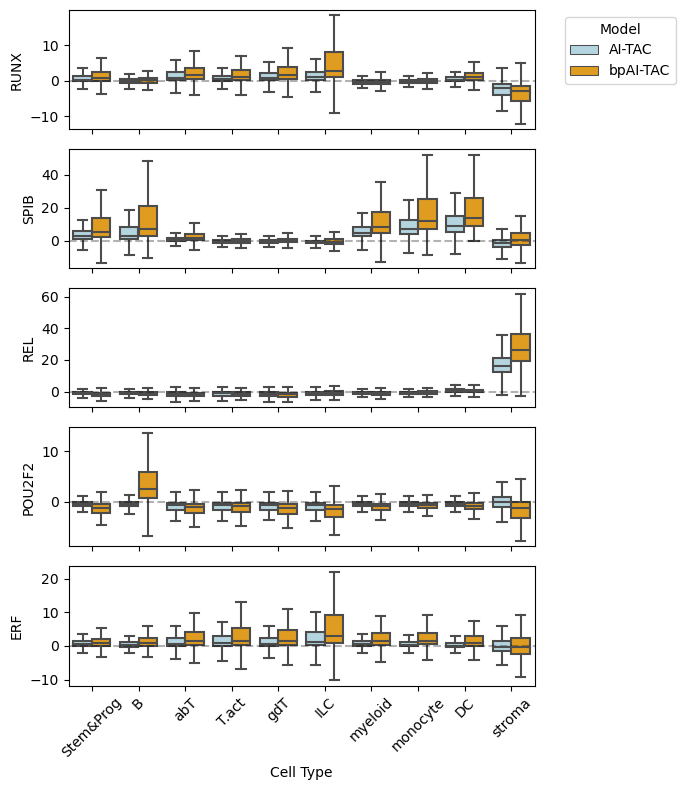

In [ ]:
# plot_motif_names_list = ['REL', 'FLI1', 'RUNX', 'ETV2', 'POU2F2', 'SPIC', 'SPIB', 'MOTIF_665','MOTIF_980']
plot_motif_names_list = ['RUNX', 'SPIB', 'REL', 'POU2F2', 'ERF']

filename_end = 'trial_avg'

predictions_list = [
    (marginalized_results[motif]['aitac_counts'], 
     marginalized_results[motif]['bpaitac_counts'],
    ) for motif in plot_motif_names_list
]

diff_from_random_list = [
    (marginalized_results[motif]['aitac_counts'] - marginalized_results['no_motif']['aitac_counts'], 
     marginalized_results[motif]['bpaitac_counts'] - marginalized_results['no_motif']['bpaitac_counts'],
    ) for motif in plot_motif_names_list
]


# Create the plot
fig = create_stacked_comparison_boxplots(
    predictions_list=diff_from_random_list,
    cellnames=lineage_names,  # Your list of cell type names
    motif_names=plot_motif_names_list,   # Your list of motif names
    figsize=(7, 1.6),
    show_outliers=False,
    show_zero_line=True
)

fig.show()

fig.savefig(f'submit_figs/3d{filename_end}.png', bbox_inches='tight', dpi=330)


## S6 Marginalized profile figs

1. You have to get the predictions before and after the motif insertion and 
2. then plot that


In [ ]:
from utils import predict_all

def get_averaged_profile_predictions(model_list, x, n_tracks, out_seq_len):
    preds_sum = torch.zeros((len(x), n_tracks, out_seq_len)).to(DEVICE)
    for model in model_list:
        model_profile_pred, _  = predict_all(model, x, n_celltypes=n_tracks, device=DEVICE, out_seq_len=out_seq_len)
        model_preds_sum = preds_sum + model_profile_pred
        
    return model_preds_sum / len(model_list)

In [ ]:
from utils import predict_all
# You have to get the predictions before and after the motif insertion and then plot that
def get_marginalized_profile_predictions(lineage_model1, lineage_model2, onehot_shuf, motif_dict):
    results_dict = {}
    out_seq_len=250
    # Generate predictions for each motif
    for motif_name, motif in motif_dict.items():
        print(motif_name, motif)
        if len(motif) == 0:
            x = onehot_shuf
        else:
            onehot_with_motif = substitute(onehot_shuf, motif=motif)
            x = onehot_with_motif
        
        if type(lineage_model1) is list:
            model_1_profile_pred = get_averaged_profile_predictions(lineage_model1, x, n_tracks=n_lineages, out_seq_len=out_seq_len)
            model_2_profile_pred = get_averaged_profile_predictions(lineage_model2, x, n_tracks=n_lineages, out_seq_len=out_seq_len)
        else:
            model_1_profile_pred, _  = predict_all(lineage_model1, x, n_celltypes=n_lineages, device=DEVICE, out_seq_len=out_seq_len)
            model_2_profile_pred, _ = predict_all(lineage_model2, x, n_celltypes=n_lineages, device=DEVICE, out_seq_len=out_seq_len)
                
        assert not torch.allclose(model_1_profile_pred, model_2_profile_pred), f"Model 1 and Model 2 predictions are identical: {model_1_profile_pred} and {model_2_profile_pred}"

        results_dict[motif_name] = {'aitac_profiles': model_1_profile_pred.cpu().numpy(),
                            'bpaitac_profiles': model_2_profile_pred.cpu().numpy(),
                            }
    return results_dict



In [ ]:
from scipy.special import softmax
import numpy as np
import matplotlib.pyplot as plt

def plot_genomic_predictions_comparison(y_before1, y_after1, y_before2, y_after2, 
                                      lineage_names, motif_name, titles=("Plot 1", "Plot 2"), start_idx=375, end_idx=625, 
                                      figsize=(20, 20),
                                      band_type="std",
                                      relative_position_labels=False
                                      ):
    """
    Create two sets of genomic prediction plots side by side with proper scaling.
    Includes standard deviation bands around the mean lines.
    
    Parameters:
    -----------
    y_before1, y_after1 : First set of predictions
    y_before2, y_after2 : Second set of predictions
    lineage_names : list of str
        Names of lineages to use as subplot titles
    start_idx, end_idx : int
        Start and end indices for the genomic window
    figsize : tuple
        Figure size (width, height)
    """
    

    def process_input(x, band_type="std"):  # Added band_type parameter
        """Helper function to process input arrays and calculate bounds"""
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
            
        if not isinstance(x, np.ndarray):
            raise TypeError("Input must be either a PyTorch tensor or NumPy array")
            
        # Calculate mean
        x_mean = x.mean(axis=0)
        
        # Calculate bounds based on band_type
        if band_type == "std":
            x_std = x.std(axis=0)
            x_upper = x_mean + x_std
            x_lower = x_mean - x_std
            return x_mean, x_upper, x_lower
        elif band_type == "quartile":
            x_lower = np.percentile(x, 25, axis=0)
            x_upper = np.percentile(x, 75, axis=0)
            x_median = np.median(x, axis=0)
            return x_median, x_upper, x_lower
        else:
            raise ValueError("band_type must be either 'std' or 'quartile'")
            
    if motif_name is None:
        motif_name = "motif"
    # Process all inputs
    yb1_mean, yb1_upper, yb1_lower = process_input(y_before1, band_type)
    ya1_mean, ya1_upper, ya1_lower = process_input(y_after1, band_type)
    yb2_mean, yb2_upper, yb2_lower = process_input(y_before2, band_type)
    ya2_mean, ya2_upper, ya2_lower = process_input(y_after2, band_type)
    
    print('yb mean, and yb upper', yb1_mean.shape, yb1_upper.shape)
    
    # Create figure and grid
    fig, axes = plt.subplots(len(lineage_names), 2, figsize=figsize)
        
    # Find global min/max for consistent scaling
    all_data = np.concatenate([
        yb1_mean[:, start_idx:end_idx].flatten(),
        ya1_mean[:, start_idx:end_idx].flatten(),
        yb2_mean[:, start_idx:end_idx].flatten(),
        ya2_mean[:, start_idx:end_idx].flatten(),
        yb1_upper[:, start_idx:end_idx].flatten(),
        yb1_lower[:, start_idx:end_idx].flatten(),
        ya1_upper[:, start_idx:end_idx].flatten(),
        ya1_lower[:, start_idx:end_idx].flatten(),
        yb2_upper[:, start_idx:end_idx].flatten(),
        yb2_lower[:, start_idx:end_idx].flatten(),
        ya2_upper[:, start_idx:end_idx].flatten(),
        ya2_lower[:, start_idx:end_idx].flatten()
    ])
    
    print(all_data)
    global_min = np.min(all_data)
    global_max = np.max(all_data)
    
    # Add small padding to min/max
    padding = (global_max - global_min) * 0.05
    y_min = global_min - padding
    y_max = global_max + padding
    
    # Create x-axis values
    x_values = np.arange(start_idx, end_idx)
    band_label = "±1 std dev" if band_type == "std" else "quartile band"

    # Plot each row
    for i, lineage in enumerate(lineage_names):
        # Left plot
        # Plot std deviation bands
        axes[i, 0].fill_between(x_values, 
                              yb1_lower[i, start_idx:end_idx],
                              yb1_upper[i, start_idx:end_idx],
                              color='b', alpha=0.2)
        axes[i, 0].fill_between(x_values,
                              ya1_lower[i, start_idx:end_idx],
                              ya1_upper[i, start_idx:end_idx],
                              color='r', alpha=0.2)
        
        # Plot mean lines
        axes[i, 0].plot(x_values, yb1_mean[i, start_idx:end_idx], color='b', 
                       linewidth=1, label=f"No {motif_name}")
        axes[i, 0].plot(x_values, ya1_mean[i, start_idx:end_idx], color='r',
                       linewidth=1, label=f"With {motif_name}")
        
        axes[i, 0].set_ylim(y_min, y_max)
        axes[i, 0].set_ylabel(f"{lineage}\n")
        axes[i, 0].grid(True, linestyle='--', alpha=0.7)
        if i == 0:
            axes[i, 0].set_title(titles[0])
        
        # Right plot
        # Plot std deviation bands
        axes[i, 1].fill_between(x_values,
                              yb2_lower[i, start_idx:end_idx],
                              yb2_upper[i, start_idx:end_idx],
                              color='b', alpha=0.2)
        axes[i, 1].fill_between(x_values,
                              ya2_lower[i, start_idx:end_idx],
                              ya2_upper[i, start_idx:end_idx],
                              color='r', alpha=0.2)
        
        # Plot mean lines
        axes[i, 1].plot(x_values, yb2_mean[i, start_idx:end_idx], color='b',
                       linewidth=1, label=f"No {motif_name}")
        axes[i, 1].plot(x_values, ya2_mean[i, start_idx:end_idx], color='r',
                       linewidth=1, label=f"With {motif_name}")
        
        axes[i, 1].set_ylim(y_min, y_max)
        axes[i, 1].grid(True, linestyle='--', alpha=0.7)
        if i == 0:
            axes[i, 1].set_title(titles[1])
        
        # Hide x-axis labels except for bottom plots
        if i != len(lineage_names) - 1:
            axes[i, 0].set_xticklabels([])
            axes[i, 1].set_xticklabels([])
        elif relative_position_labels:  
            #convert the labels which are from 50 to 200 right now, to where the center is 0 and then everythin is relative to that (negative or positive)
            current_ticks = axes[i, 0].get_xticks()
            center = (current_ticks.max() + current_ticks.min()) / 2
            relative_ticks = current_ticks - center
            axes[i, 0].set_xticklabels(relative_ticks)
            axes[i, 1].set_xticklabels(relative_ticks)
    

    # Add x-label to bottom row only
    if relative_position_labels:
        axes[-1, 0].set_xlabel("Relative Genomic Position")
        axes[-1, 1].set_xlabel("Relative Genomic Position")
    else:
        axes[-1, 0].set_xlabel("Genomic Position")
        axes[-1, 1].set_xlabel("Genomic Position")
    
    axes[0, 1].legend(fontsize=8)
    
    # Adjust layout
    # plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.tight_layout()
    return fig, axes

In [ ]:
# marginalized_profile_results = get_marginalized_profile_predictions(lineage_model_aitac, lineage_model_bpaitac,onehot_shuf,
#                                                     sample_motif_dict)
marginalized_profile_results = get_marginalized_profile_predictions(aitac_lineage_model_list, bpaitac_lineage_model_list,onehot_shuf,
                                                    marginalization_motif_dict)




POU2F2 ATTTGCAT


100%|████| 40/40 [00:02<00:00, 16.43it/s]


REL GGGAATTTCCC


100%|████| 40/40 [00:02<00:00, 15.93it/s]


RUNX TCTGTGGTTT


100%|████| 40/40 [00:02<00:00, 16.13it/s]


SPIB TCACTTCCTCTTT


100%|████| 40/40 [00:02<00:00, 16.05it/s]


no_motif 


100%|████| 40/40 [00:02<00:00, 15.91it/s]


In [ ]:
lineage_names

['Stem&Prog',
 'B',
 'abT',
 'T.act',
 'gdT',
 'ILC',
 'myeloid',
 'monocyte',
 'DC',
 'stroma']

pre repeat (4000, 1, 250)
y_after1 (4000, 4, 250)
y_before1 (4000, 4, 250)
yb mean, and yb upper (4, 250) (4, 250)
[0.00056794 0.0005821  0.00056008 ... 0.00020957 0.00020364 0.00020545]


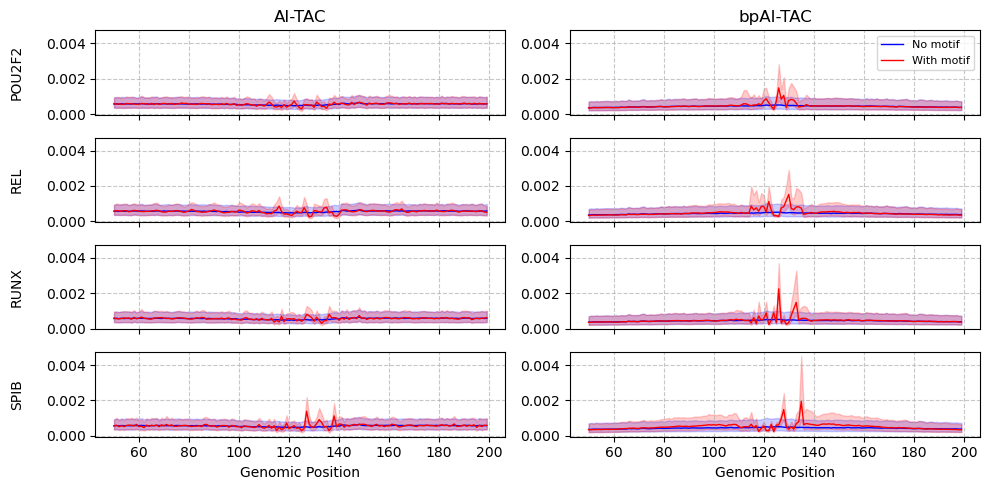

In [ ]:
def plot_motif(motif_to_plot):
    y_before1=marginalized_profile_results['no_motif']['aitac_profiles']
    y_after1=marginalized_profile_results[motif_to_plot]['aitac_profiles']
    y_before2=marginalized_profile_results['no_motif']['bpaitac_profiles']
    y_after2=marginalized_profile_results[motif_to_plot]['bpaitac_profiles']

    plot_genomic_predictions_comparison(y_before1, y_after1, y_before2, y_after2, 
                                        lineage_names=lineage_names, motif_name=motif_to_plot, titles=("AI-TAC", "bpAI-TAC"), start_idx=0, end_idx=250, 
                                        figsize=(20, 20),
                                        band_type="quartile",
                                        relative_position_labels=False
                                        )
    
def plot_multiple_motifs(motifs_to_plot, cell_idx, n_sequences, seq_len=250):
    y_before1=marginalized_profile_results['no_motif']['aitac_profiles'][:, cell_idx:cell_idx+1, :]
    print('pre repeat', y_before1.shape)
    y_before1=np.repeat(y_before1, len(motifs_to_plot), axis=1)

    y_before2=marginalized_profile_results['no_motif']['bpaitac_profiles'][:, cell_idx:cell_idx+1, :]
    y_before2=np.repeat(y_before2, len(motifs_to_plot), axis=1)
    
    aitac_different_motif_array = np.zeros((n_sequences, len(motifs_to_plot), seq_len))
    bpaitac_different_motif_array = np.zeros((n_sequences, len(motifs_to_plot), seq_len))
    for i, motif in enumerate(motifs_to_plot):
        aitac_different_motif_array[:, i, :] = marginalized_profile_results[motif]['aitac_profiles'][:, cell_idx, :]
        bpaitac_different_motif_array[:, i, :] = marginalized_profile_results[motif]['bpaitac_profiles'][:, cell_idx, :]
    
    y_after1=aitac_different_motif_array
    y_after2=bpaitac_different_motif_array
    
    print('y_after1', y_after1.shape)
    print('y_before1', y_before1.shape)
    fig, axes = plot_genomic_predictions_comparison(y_before1, y_after1, y_before2, y_after2, 
                                        lineage_names=motifs_to_plot, motif_name=None, titles=("AI-TAC", "bpAI-TAC"), start_idx=50, end_idx=200, 
                                        figsize=(10, 5),
                                        band_type="quartile",
                                        relative_position_labels=False
                                        )
    return fig, axes

cell_idx = 6 # where(lineage_names == 'myeloid')

motifs_for_marginalization_plot = ["POU2F2", "REL", "RUNX", "SPIB"]
fig, axes = plot_multiple_motifs(motifs_for_marginalization_plot, cell_idx, n_sequences=4000, seq_len=250)
fig.savefig('submit_figs/S6_footprints_zoom.png', dpi=330)


# plot_motif("REL")
# plot_motif("MOTIF_291")

# Figure S2d profile prediction example

In [ ]:
plt.rcdefaults() 
def plot_2aligned_profiles(obs_prof, pred_prof, outpath):
    """
    predicted profile and observed profile should ALREADY BE TRUCATED
    to the open chromatin region / desired region to plot
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(4.5,3.5), dpi=300)

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    x_axis = np.arange(np.shape(obs_prof)[-1])
    ax1.bar(x_axis, obs_prof, alpha = 0.9, color = 'c', linewidth=0, width=1)
    ax1.set_title('Observed', fontsize=10)
    ax2.bar(x_axis, pred_prof, alpha = 0.9, color= 'orangered', linewidth=0, width=1)
    ax2.set_title('Predicted', fontsize=10)

    ax1.set_xticks([])
    ax2.set_xticks([])
    plt.subplots_adjust(hspace=0.4)
    plt.show()

    fig.savefig(outpath)
    plt.close()
    plt.clf()

In [ ]:
def prediction(model, X, bias, device):
    with torch.no_grad():
        profile, scalar = model(X.to(device), bias.to(device))
        return profile, scalar

In [ ]:
bias = test_bias[peak_idx]
bias.shape

(1, 998)

In [ ]:
from utils import predict_all
metrics_path = "/homes/gws/nchand/MostafaviLab/results/BPcm_250/BP203_L-1_5/complete/04-03-2025.09.29/save_file_name=testing_analysis.npz_best_loss_model.pth.npz"
metrics=np.load(metrics_path)

peak_idx = 25481
total_counts = test_counts[peak_idx]
top_cell_idx = np.argmax(total_counts)
cell_idx= top_cell_idx
print('cell name', cell_names[cell_idx])


onehot = test_onehot[peak_idx]
bias = torch.from_numpy(test_bias[peak_idx])

seq = torch.from_numpy(onehot)
seq = seq.unsqueeze(0)
profile, counts = prediction(model_bpaitac, seq, bias=bias, device='cpu')
profile = torch.squeeze(profile)
pred_profile = profile.numpy()


cell name GN.Thio.PC


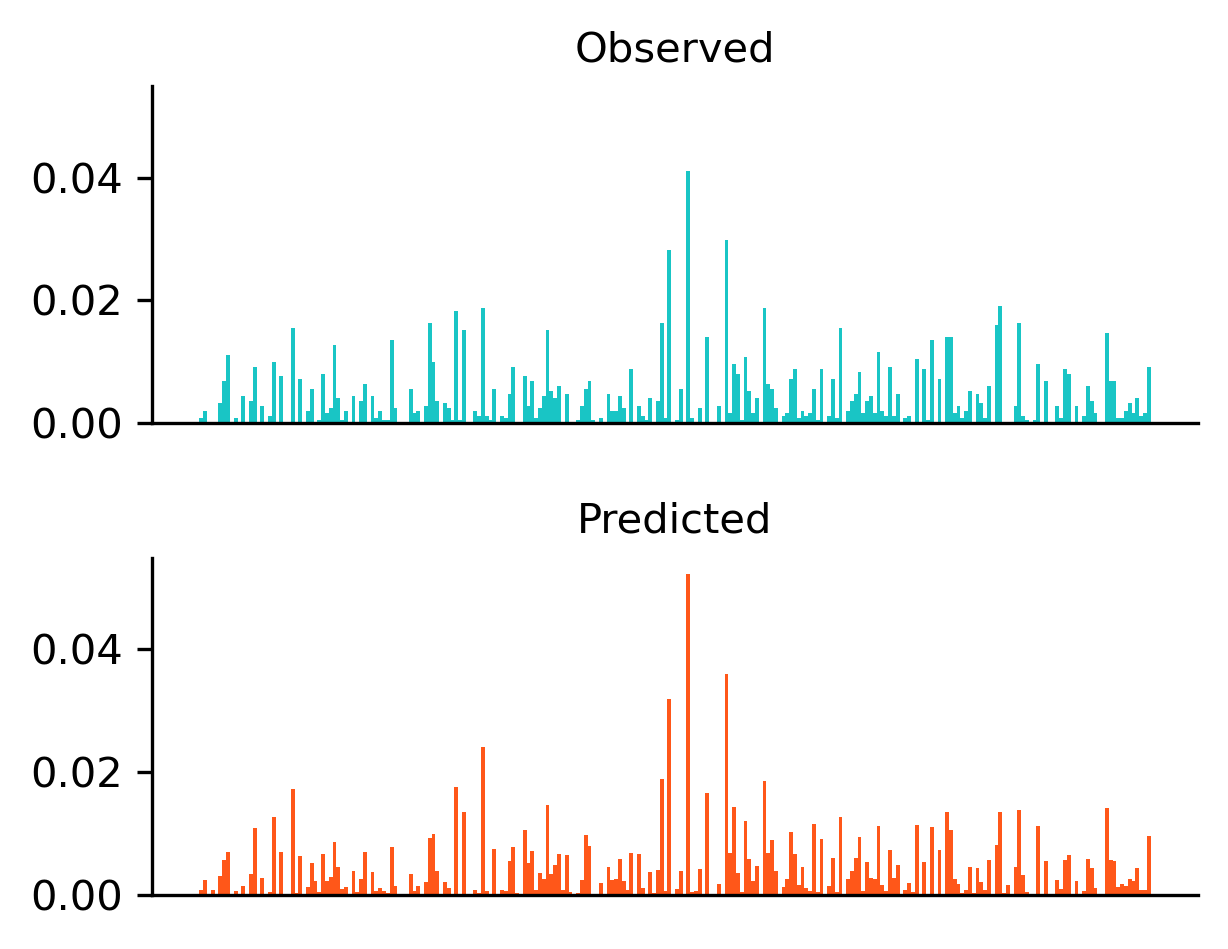

submit_figs/S2e_scatter.png


<Figure size 640x480 with 0 Axes>

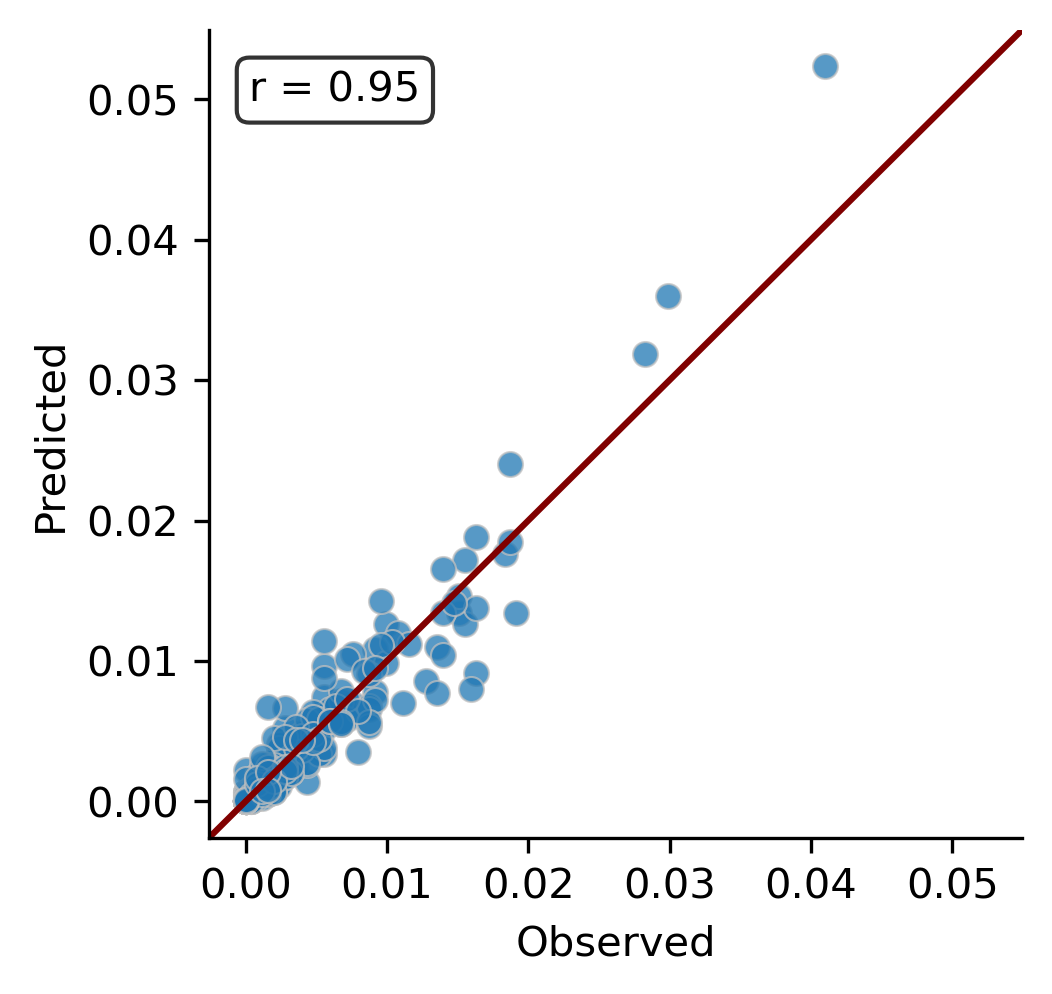

In [ ]:
obs_prof = test_bpcounts[peak_idx][cell_idx, 375:625]
# Must normalize the obs_prof
obs_prof = obs_prof / np.sum(obs_prof)

pred = pred_profile[cell_idx]

plot_2aligned_profiles(obs_prof=obs_prof, pred_prof=pred, outpath='submit_figs/S2d')
scatter_plot_corr_simple(obs_prof, pred, namex='Observed', namey='Predicted', outname='submit_figs/S2e', show_r=True, figsize=(3.5,3.5))


In [ ]:
print(np.sum(obs_prof))
print(np.sum(prediction))

1.0
1.0


In [ ]:
print(metrics.files)
profile_corr =metrics['profile_corr']
print(profile_corr.shape)
max_cell_corr = np.max(profile_corr, axis=-1)
max_cell_corr[np.argmax(max_cell_corr)]

print(np.argmax(max_cell_corr))

['scalar_corr', 'profile_corr', 'jsd', 'ocr_profile_corr', 'ocr_jsd', 'top_ocr_profile_corr', 'top_ocr_jsd']
(32361, 90)
20128


In [ ]:
top_ocr_jsd = metrics['top_ocr_jsd']
min_jsd_idx = np.argmin(top_ocr_jsd)
print(min_jsd_idx)
print('min jsd', top_ocr_jsd[min_jsd_idx])


25481
min jsd 0.025195682
